# plotting celltypes across conditions, and across compartments

In [50]:
import scanpy as sc

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters_withraw.h5ad")
adata

AnnData object with n_obs × n_vars = 302560 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'compartment', 'shape_index', 'solidity', 'replicate', 'condition', 'batch_key', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden', 'highlight', 'leiden_0.5', 'leiden_0.65', 'leiden_0.75', 'leiden_0.85', 'leiden_1.0', 'mac_subcluster', '3_subcluster', 'celltype_assignments', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter', 'sex'
    uns: '3_subcluster', '3_subcluster_color

In [31]:
bdata = adata[adata.obs['compartment'].str.contains('orsal')].copy()

# Checking which compartment to normalise cell counts to, ventral dermis has least variability
## ensure you set cdata for downstream sections

In [5]:
import matplotlib.pyplot as plt

def plot_compartment_cellcount(adata, compartment, condition_order=None):
    """
    Plot total cell count per replicate for a given compartment,
    across conditions, split by sex.

    Parameters
    ----------
    adata : AnnData
    compartment : str
        Used only for the plot title/label — adata is assumed to already
        contain only cells from this compartment.
    condition_order : list, optional
    """

    if condition_order is None:
        condition_order = sorted(adata.obs['batch_key'].astype(str).unique())

    adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)

    # ── Cell counts per replicate (all celltypes) ─────────────────────────────
    batch_counts = adata.obs['batch_key'].value_counts()

    all_batches = adata.obs[['batch_key']].drop_duplicates().copy().astype(str)
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')
    all_batches['count']     = all_batches['batch_key'].map(batch_counts).fillna(0)

    # ── Plot ──────────────────────────────────────────────────────────────────
    sex_colors = {'F': 'darkred', 'M': '#002147'}
    sex_labels = {'F': 'Female',  'M': 'Male'}
    width = 0.35
    x = range(len(condition_order))

    fig, ax = plt.subplots(figsize=(8, 5))

    for sex, offset in {'F': -width / 2, 'M': width / 2}.items():
        sex_data = all_batches[all_batches['sex'] == sex]

        box_data = [
            sex_data.loc[sex_data['condition'] == cond, 'count'].values
            for cond in condition_order
        ]
        positions = [xi + offset for xi in x]

        ax.boxplot(
            box_data,
            positions=positions,
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            boxprops=dict(facecolor=sex_colors[sex], alpha=0.7),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color=sex_colors[sex]),
            capprops=dict(color=sex_colors[sex]),
            flierprops=dict(marker='o', color=sex_colors[sex], alpha=0.5),
        )

        for pos, vals in zip(positions, box_data):
            ax.scatter(
                [pos] * len(vals), vals,
                color=sex_colors[sex], edgecolors='black',
                linewidths=0.5, zorder=5, s=40, alpha=0.8,
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(condition_order)
    ax.set_title(f'Total cells  |  {compartment}', fontsize=16)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Cell count', fontsize=13)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=sex_colors[s], alpha=0.7, label=sex_labels[s])
        for s in ['F', 'M']
    ]
    ax.legend(handles=handles)
    plt.tight_layout()
    plt.show()

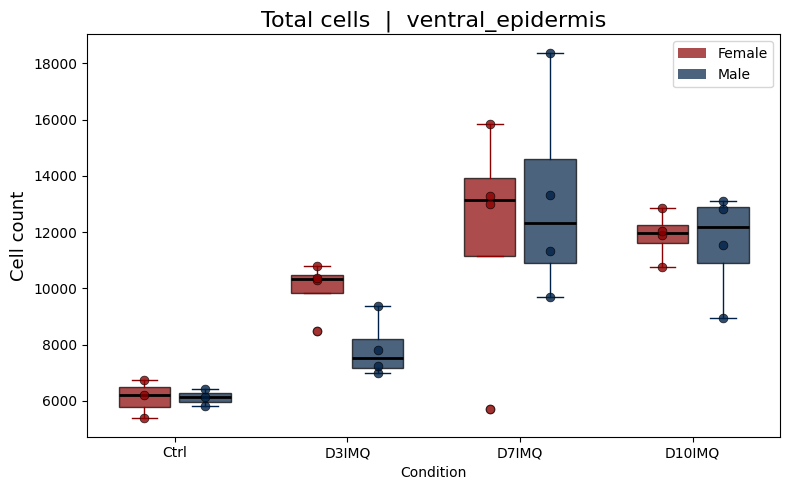

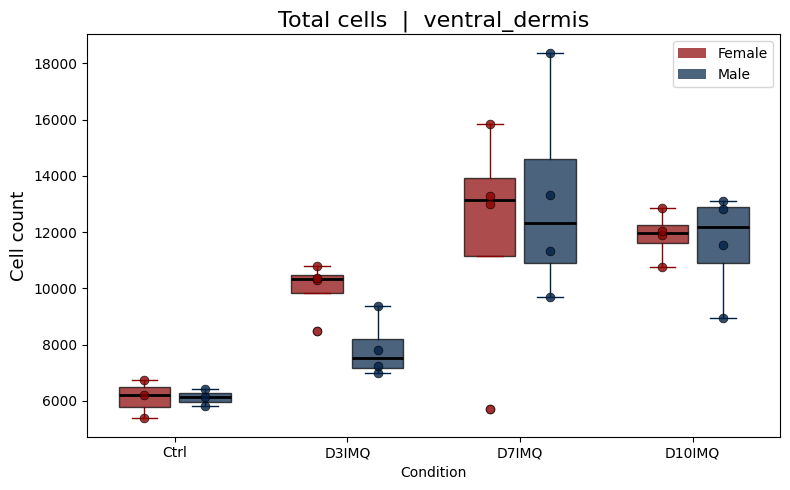

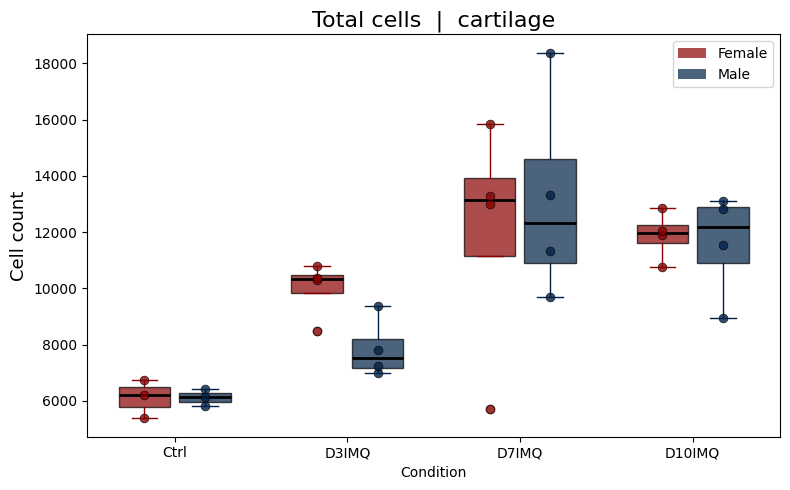

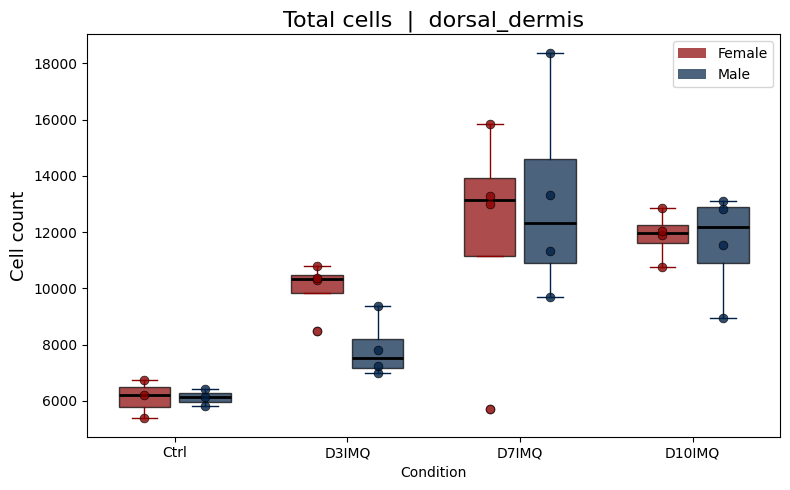

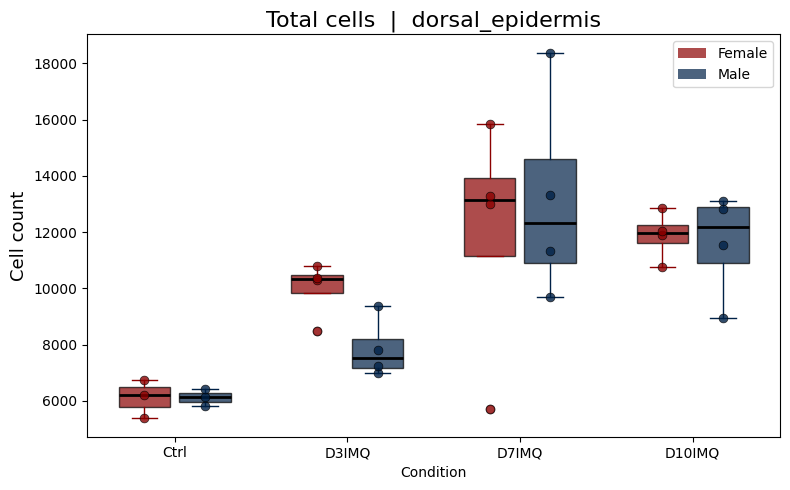

In [ ]:
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']
for compartment in ['ventral_epidermis', 'ventral_dermis', 'cartilage', 'dorsal_dermis', 'dorsal_epidermis']:   
    plot_compartment_cellcount(adata, compartment, condition_order=condition_order) 


In [56]:
## cell density across conditions - DON'T USE adata filtered to just dorsal lolll

def plot_compartment_densities(adata, condition_order=None):

    compartments = ['ventral_epidermis', 'ventral_dermis', 'cartilage', 'dorsal_dermis', 'dorsal_epidermis']
    compartment_colors = {
        'cartilage':         '#969696',
        'ventral_epidermis': '#32C832',
        'ventral_dermis':    '#D2D2D2',
        'dorsal_dermis':     '#A032C8',
        'dorsal_epidermis':  '#DC2828',
    }

    if condition_order is None:
        condition_order = sorted(adata.obs['batch_key'].astype(str).str.extract(r'^(.+)_[FM]\d+$')[0].unique())

    adata.obs['batch_key']   = adata.obs['batch_key'].astype(str)
    adata.obs['compartment'] = adata.obs['compartment'].astype(str)

    # ── Build per-replicate density for each compartment ─────────────────────
    all_batches = adata.obs[['batch_key']].drop_duplicates().copy().astype(str)
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    for comp in compartments:
        comp_counts = (
            adata[adata.obs['compartment'] == comp]
            .obs['batch_key'].value_counts()
        )
        surface_areas = {
            batch: regions[comp]
            for batch, regions in adata.uns['region_surface_areas_um2'].items()
            if comp in regions
        }
        all_batches[f'count_{comp}']   = all_batches['batch_key'].map(comp_counts).fillna(0)
        all_batches[f'area_{comp}']    = all_batches['batch_key'].map(surface_areas)
        all_batches[f'density_{comp}'] = (all_batches[f'count_{comp}'] / all_batches[f'area_{comp}']) * 100

    # ── Plot ──────────────────────────────────────────────────────────────────
    sexes      = ['F', 'M']
    sex_labels = {'F': 'Female', 'M': 'Male'}

    n_conditions   = len(condition_order)
    n_compartments = len(compartments)
    width          = 0.8 / n_compartments
    x              = range(n_conditions)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for ax, sex in zip(axes, sexes):
        sex_data = all_batches[all_batches['sex'] == sex]

        for i, comp in enumerate(compartments):
            offsets     = [(xi - 0.4 + i * width + width / 2) for xi in x]
            density_col = f'density_{comp}'

            means = [sex_data.loc[sex_data['condition'] == cond, density_col].mean() for cond in condition_order]
            sems  = [sex_data.loc[sex_data['condition'] == cond, density_col].sem()  for cond in condition_order]

            ax.bar(
                offsets, means, width=width * 0.9,
                color=compartment_colors[comp], alpha=0.85,
                yerr=sems, error_kw=dict(ecolor='black', capsize=3, linewidth=1)
            )

            for j, cond in enumerate(condition_order):
                vals = sex_data.loc[sex_data['condition'] == cond, density_col].values
                ax.scatter(
                    [offsets[j]] * len(vals), vals,
                    color=compartment_colors[comp], edgecolors='black',
                    linewidths=0.5, zorder=5, s=30, alpha=0.9
                )

        ax.set_xticks(list(x))
        ax.set_xticklabels(condition_order)
        ax.set_title(sex_labels[sex], fontsize=14)
        ax.set_xlabel('Condition')

    axes[0].set_ylabel('Cells per 100 µm²', fontsize=13)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=compartment_colors[c], alpha=0.85,
                       label=c.replace('_', ' '))
        for c in compartments
    ]
    fig.legend(
        handles=handles,
        loc='upper left',
        bbox_to_anchor=(1.001, 0.98),
        bbox_transform=fig.transFigure,
        frameon=True,
        fancybox=False,
        edgecolor='black',
        fontsize=10,
    )
    fig.suptitle('Cell density by compartment', fontsize=16, y=1.02)

    plt.tight_layout()
    plt.subplots_adjust(right=0.88)
    plt.show()

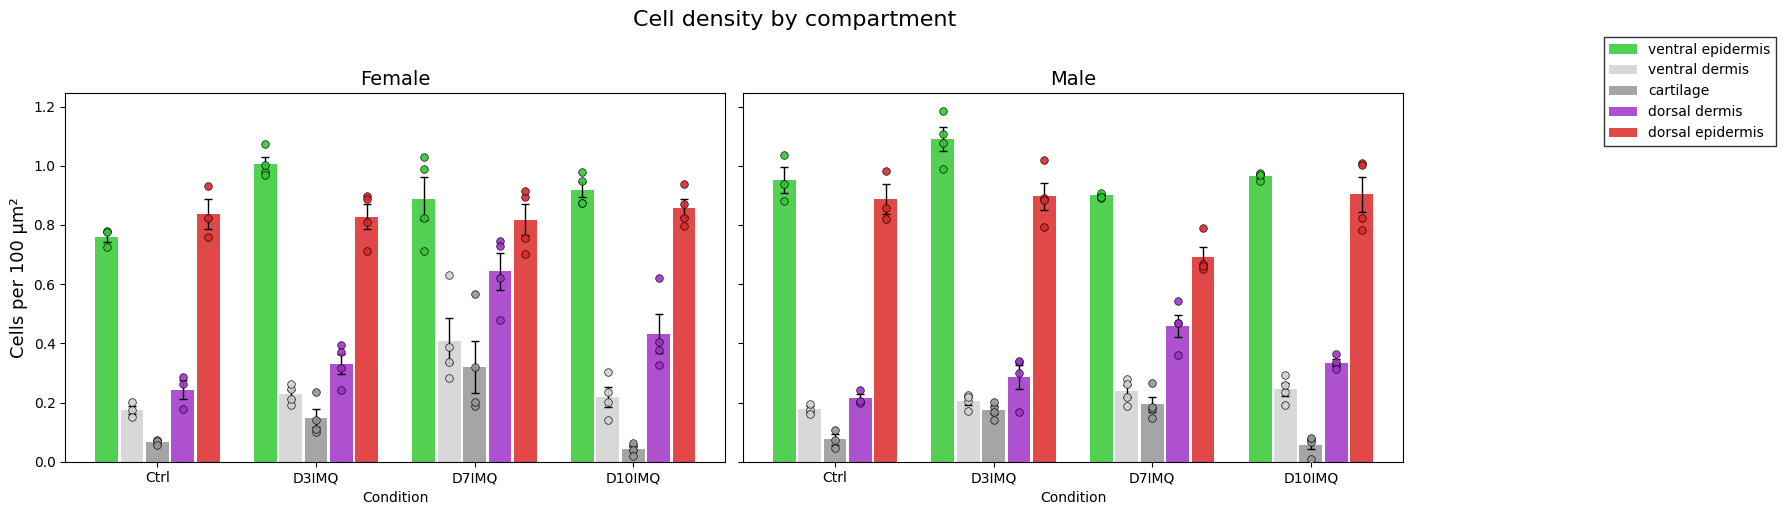

In [57]:
plot_compartment_densities(adata, condition_order=['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ'])

#### compartment thickness

In [ ]:
#plot compartment thickness over conditions. 
import pandas as pd 

#remember that these were downsampled by 0.05 and are in pixels, not microns
dermis = pd.read_excel(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\dermis_thickness_measurements.xlsx")
epidermis = pd.read_excel(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\epidermis_thickness_measurements.xlsx") 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_tissue_thickness(df, title="Compartment Thickness", metric='mean', condition_order=None):
    """
    Plots the scaled average thickness across conditions, split by sex.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Contains columns ['replicate', 'mean', 'stdDev', 'Mode', 'Min', 'Max', 'median']
    title : str
        Title for the overall figure (e.g., "Dorsal Dermis Thickness")
    metric : str
        The summary metric per replicate to plot ('mean' or 'median').
    condition_order : list, optional
        Explicit order of conditions on the x-axis.
    """
    # 1. Create a deep copy to avoid SettingWithCopyWarnings or changing original raw data
    df = df.copy()
    
    # 2. Scale the pixel values back to the original size and convert to microns
    # Dividing by 0.05 scales it back up; multiplying by 0.2125 converts pixels to um
    spatial_scaling_factor = 0.2125 / 0.05  # Equates to exactly 4.25
    
    numeric_cols = ['mean', 'stdDev', 'Mode', 'Min', 'Max', 'median']
    df[numeric_cols] = df[numeric_cols] * spatial_scaling_factor

    # 3. Clean data and extract experimental design from replicate IDs
    df['condition'] = df['replicate'].str.extract(r'^(.+)_[FM]\d+$')
    df['sex'] = df['replicate'].str.extract(r'_([FM])\d+$')
    
    if condition_order is None:
        condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']
        
    # Filter for conditions actually present in the data to avoid empty slots
    condition_order = [c for c in condition_order if c in df['condition'].unique()]

    # 4. Color scheme setup
    color_palette = {
        'Ctrl': "#0baa30",
        'D3IMQ': "#e3851a",
        'D7IMQ': 'darkred',
        'D10IMQ': 'dodgerblue'
    }
    oxford_blue = '#002147'
    
    sexes = ['F', 'M']
    sex_labels = {'F': 'Female', 'M': 'Male'}
    
    # 5. Create the subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    
    for ax, sex in zip(axes, sexes):
        sex_data = df[df['sex'] == sex]
        
        # Draw the group average bars (errorbar='se' represents variance between animals)
        sns.barplot(
            data=sex_data, x='condition', y=metric, order=condition_order,
            palette=color_palette, ax=ax, edgecolor=oxford_blue, linewidth=1.5,
            errorbar='se', alpha=0.8
        )
        
        # Overlay the individual biological replicate values as dots
        sns.stripplot(
            data=sex_data, x='condition', y=metric, order=condition_order,
            color='white', edgecolor=oxford_blue, linewidth=1.5,
            size=7, jitter=0.1, ax=ax
        )
        
        # Clean up subplot styling
        ax.set_title(sex_labels[sex], fontsize=13, pad=10)
        ax.set_xlabel('Condition', fontsize=11)
        ax.set_ylabel('') 
        
    # Global labels and formatting
    metric_label = 'Mean' if metric == 'mean' else 'Median'
    axes[0].set_ylabel(f'{metric_label} Thickness (µm)', fontsize=12)
    fig.suptitle(title, fontsize=15, y=1.02)
    
    plt.tight_layout()
    plt.show()

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_1356\1219392801.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\dbuxton\AppData\Local\Temp\ipykernel_1356\1219392801.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


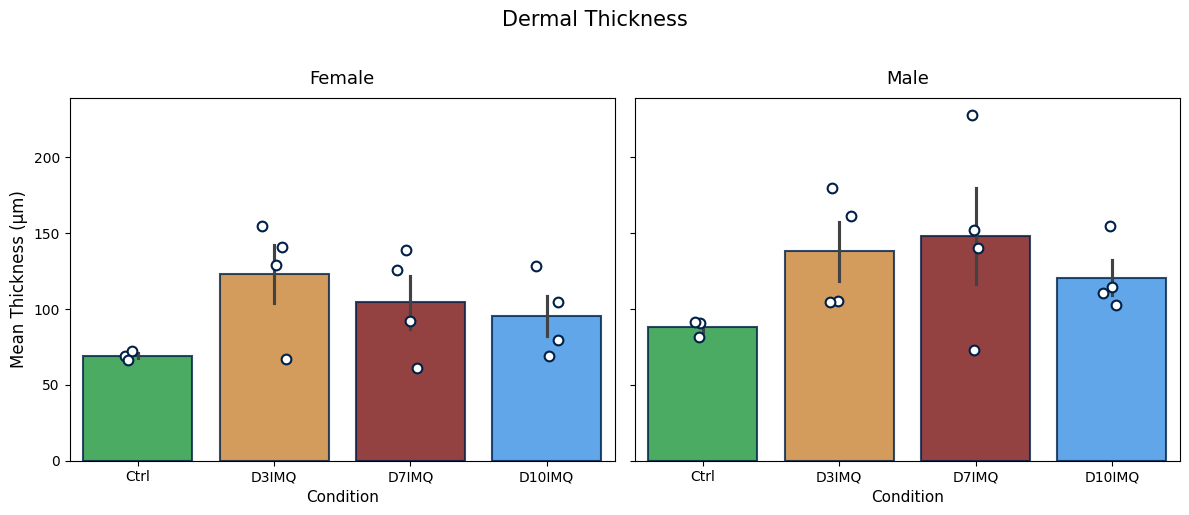

In [7]:
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_tissue_thickness(dermis, title="Dermal Thickness", metric='mean', condition_order=condition_order)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_tissue_thickness_combined(df, title="Compartment Thickness", metric='mean', condition_order=None):
    """
    Plots scaled tissue thickness as a grouped boxplot manually using native matplotlib
    aesthetics to ensure exact spacing and facecolor alpha formatting.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Contains columns ['replicate', 'mean', 'stdDev', 'Mode', 'Min', 'Max', 'median']
    title : str
        Title for the overall figure (e.g., "Dorsal Dermis Thickness")
    metric : str
        The summary metric per replicate to plot ('mean' or 'median').
    condition_order : list, optional
        Explicit order of conditions on the x-axis.
    """
    # 1. Deep copy to leave original raw dataframe completely untouched
    df = df.copy()
    
    # 2. Scale pixel values back to true size (downsample correction) and convert to microns
    spatial_scaling_factor = 0.2125 / 0.05  # Exactly 4.25
    numeric_cols = ['mean', 'stdDev', 'Mode', 'Min', 'Max', 'median']
    df[numeric_cols] = df[numeric_cols] * spatial_scaling_factor

    # 3. Parse experimental design from replicate strings
    df['condition'] = df['replicate'].str.extract(r'^(.+)_[FM]\d+$')
    df['sex'] = df['replicate'].str.extract(r'_([FM])\d+$')
    
    if condition_order is None:
        condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']
    condition_order = [c for c in condition_order if c in df['condition'].unique()]

    # 4. Aesthetic variables from reference script
    sex_colors = {'F': 'darkred', 'M': '#002147'}
    sex_labels = {'F': 'Female',  'M': 'Male'}
    width = 0.35
    x = range(len(condition_order))

    fig, ax = plt.subplots(figsize=(8, 5))

    # 5. Native manual grouping loop matching reference style
    for sex, offset in {'F': -width / 2, 'M': width / 2}.items():
        sex_data = df[df['sex'] == sex]

        # Extract values for each condition ordered along the x-axis
        box_data = [
            sex_data.loc[sex_data['condition'] == cond, metric].values
            for cond in condition_order
        ]
        positions = [xi + offset for xi in x]

        # Render boxplot chunks manually
        ax.boxplot(
            box_data,
            positions=positions,
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            boxprops=dict(facecolor=sex_colors[sex], alpha=0.7),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color=sex_colors[sex]),
            capprops=dict(color=sex_colors[sex]),
            flierprops=dict(marker='o', color=sex_colors[sex], alpha=0.5),
        )

        # Overlay identical customized scatter dots
        for pos, vals in zip(positions, box_data):
            ax.scatter(
                [pos] * len(vals), vals,
                color=sex_colors[sex], edgecolors='black',
                linewidths=0.5, zorder=5, s=40, alpha=0.8,
            )

    # 6. Labels and layout matching reference script style
    ax.set_xticks(list(x))
    ax.set_xticklabels(condition_order)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Condition', fontsize = 15)
    
    metric_label = 'Mean' if metric == 'mean' else 'Median'
    ax.set_ylabel(f'{metric_label} Thickness (µm)', fontsize=15)

    # Rebuilding clean legend box blocks
    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=sex_colors[s], alpha=0.7, label=sex_labels[s])
        for s in ['F', 'M']
    ]
    ax.legend(handles=handles)
    
    plt.tight_layout()
    plt.show()

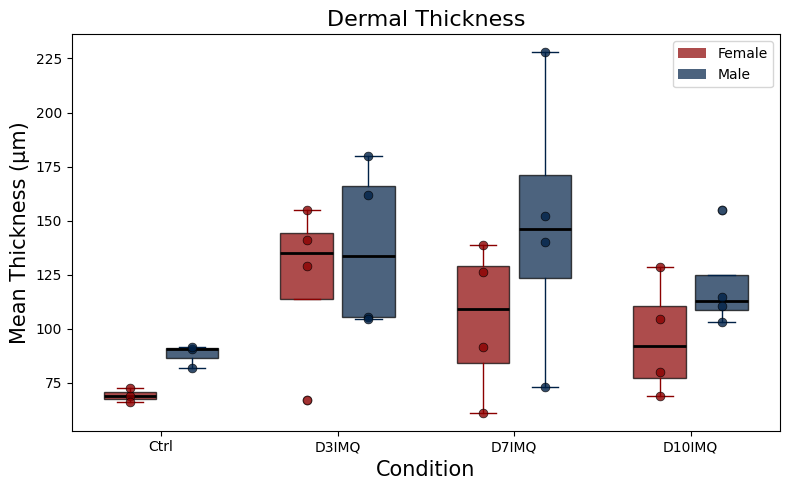

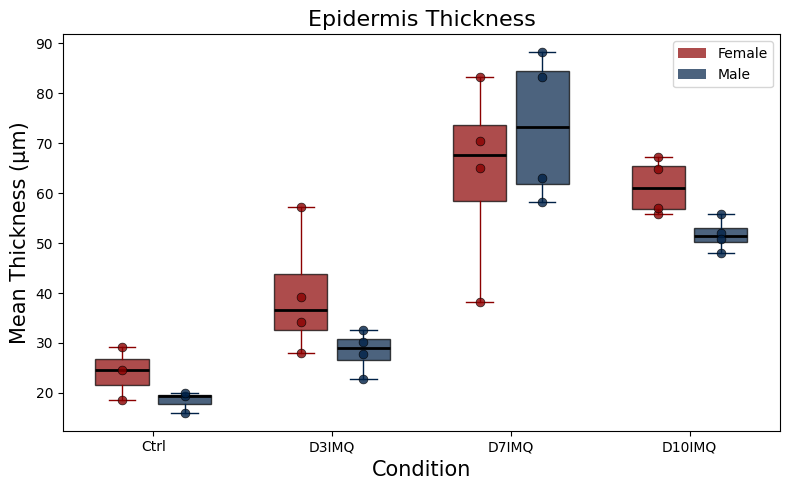

In [14]:
plot_tissue_thickness_combined(dermis, title="Dermal Thickness", metric='mean', condition_order=condition_order)
plot_tissue_thickness_combined(epidermis, title="Epidermis Thickness", metric='mean', condition_order=condition_order)

# Cell proportion graphs i.e. actually getting down to business 

perichondral_fibroblast


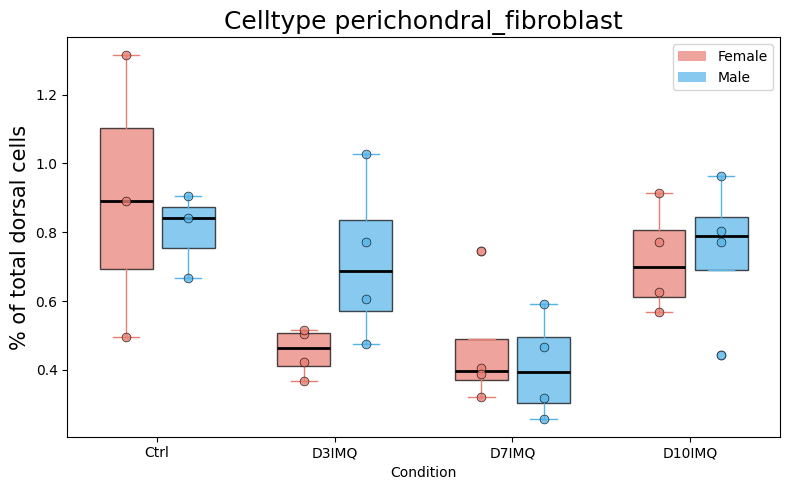

dermal_fibroblast


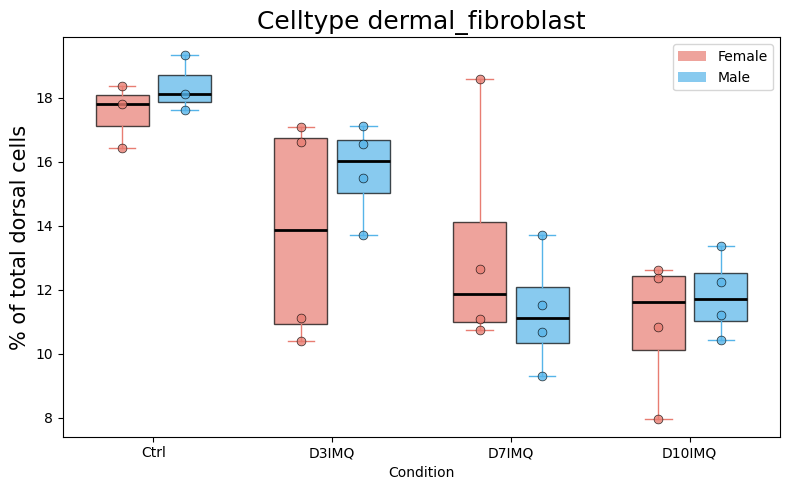

smc


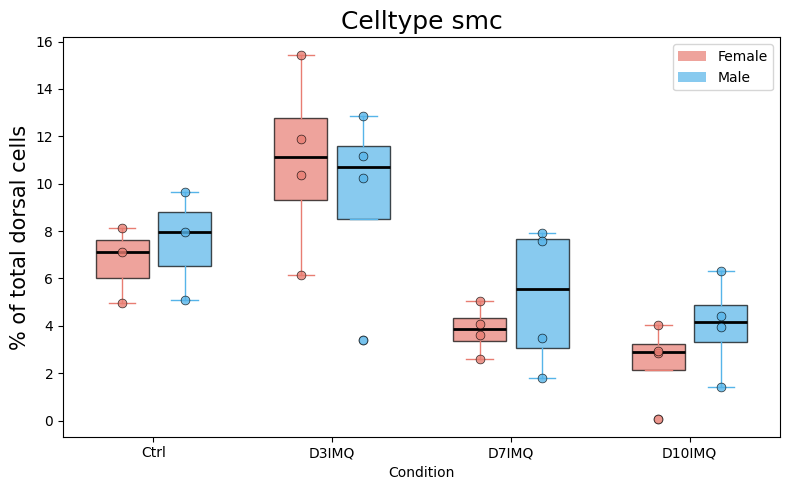

myeloid


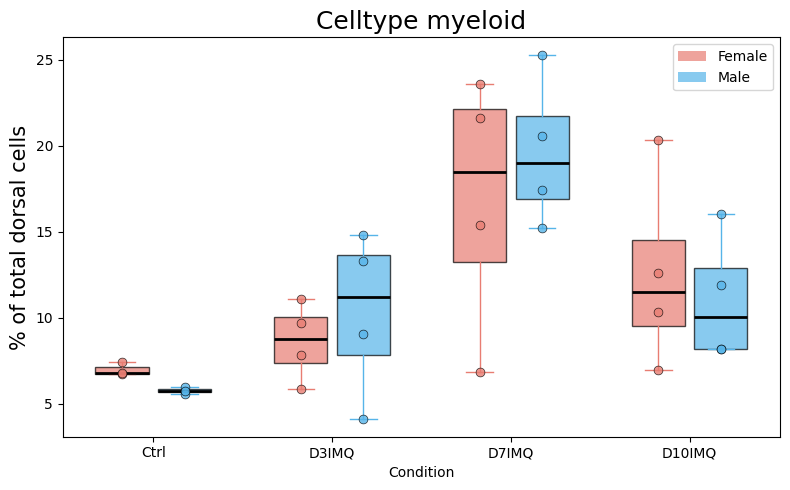

endothelial


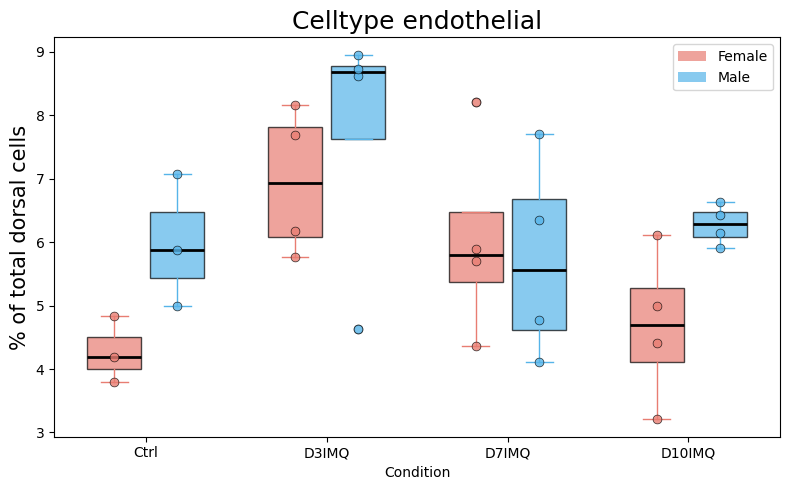

follicle_cell


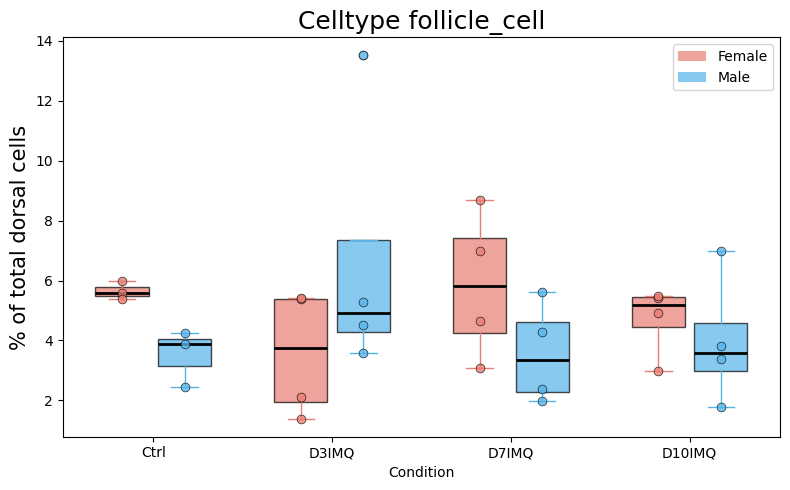

schwann_cell


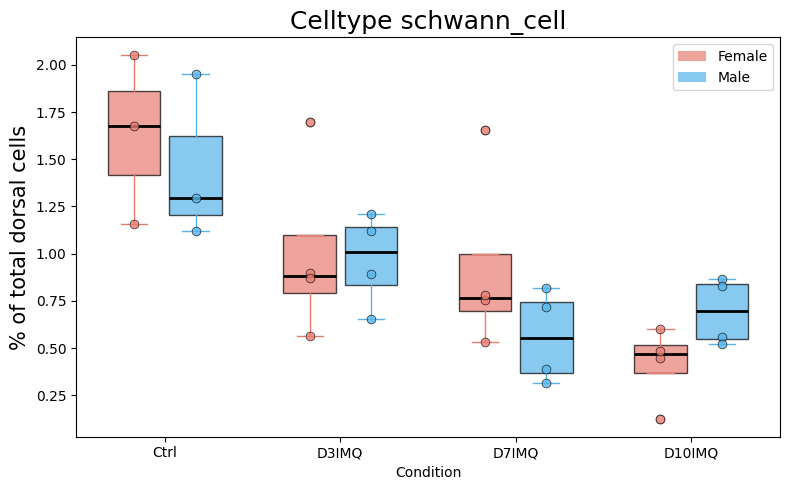

M2-like_macrophage


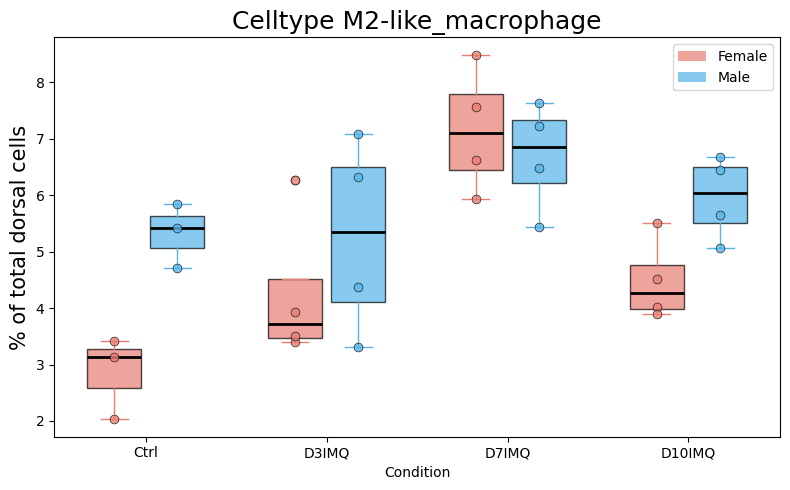

activated_basal_KC


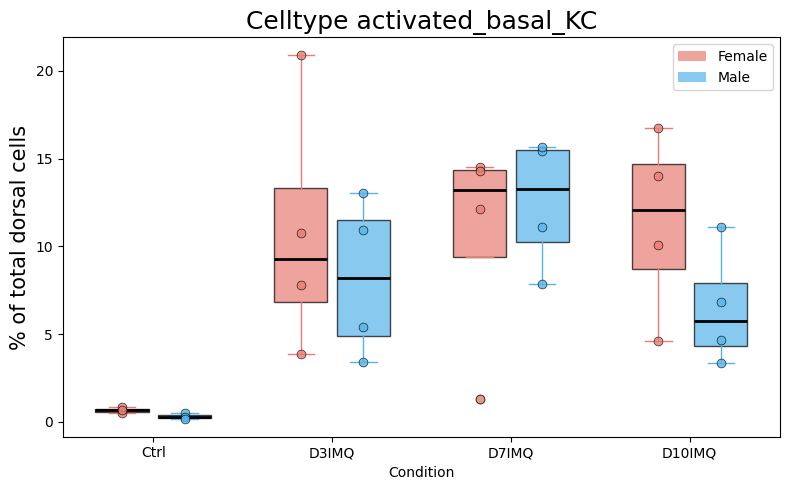

mast_cell


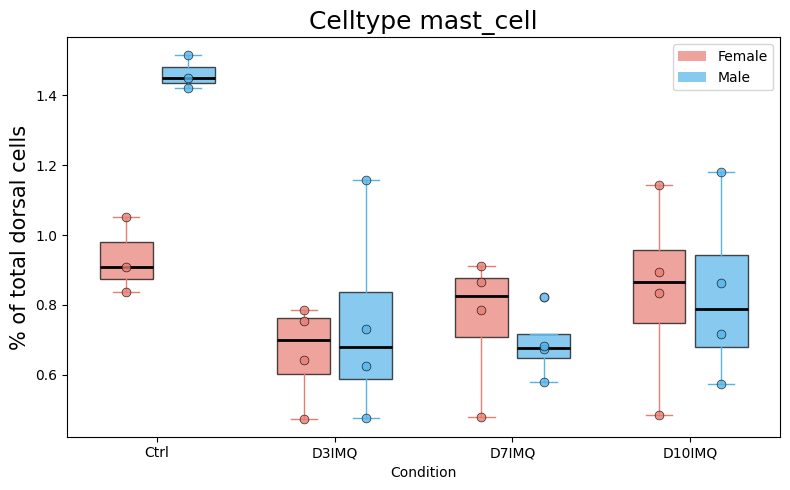

sebaceous_epithelial


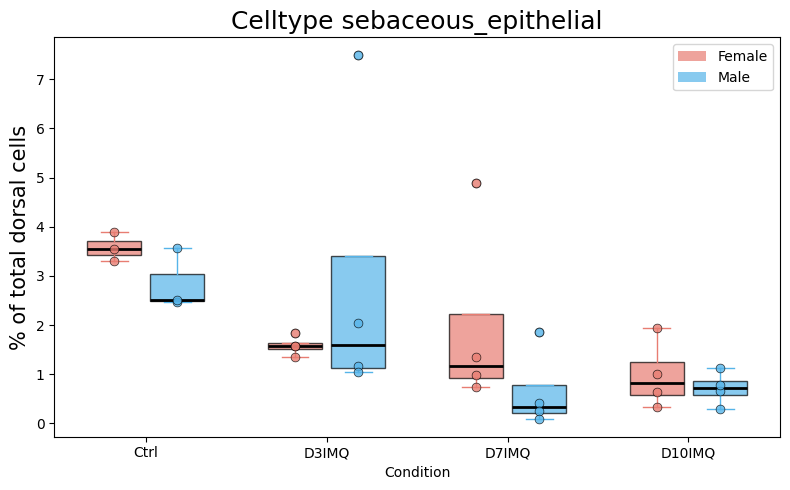

adipocyte


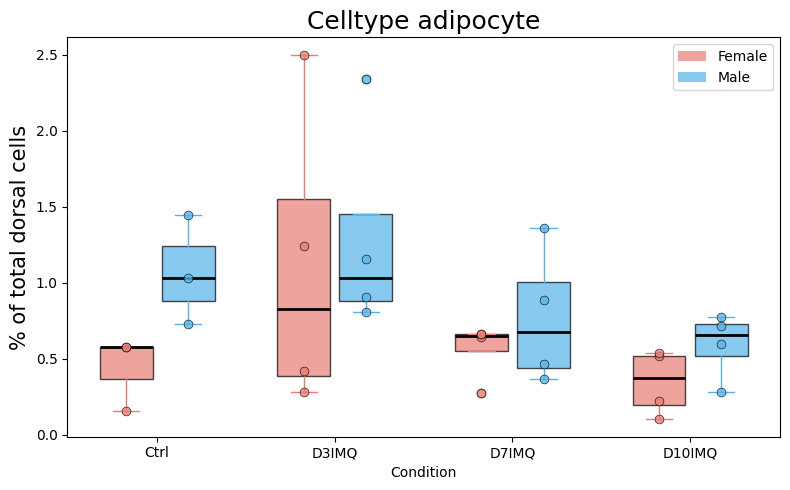

intermediate_basal_suprabasal_KC


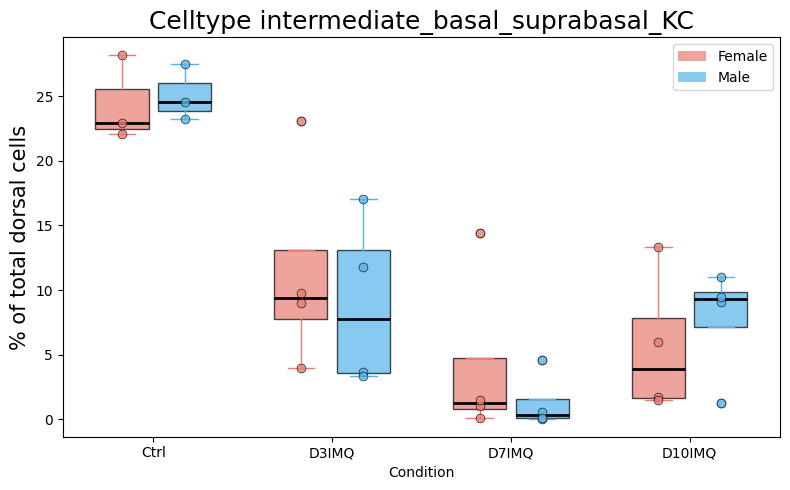

basal_KC


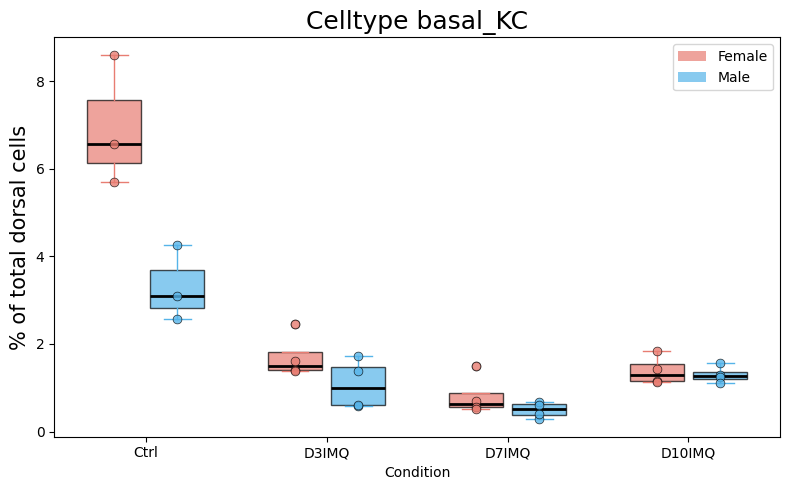

suprabasal_KC


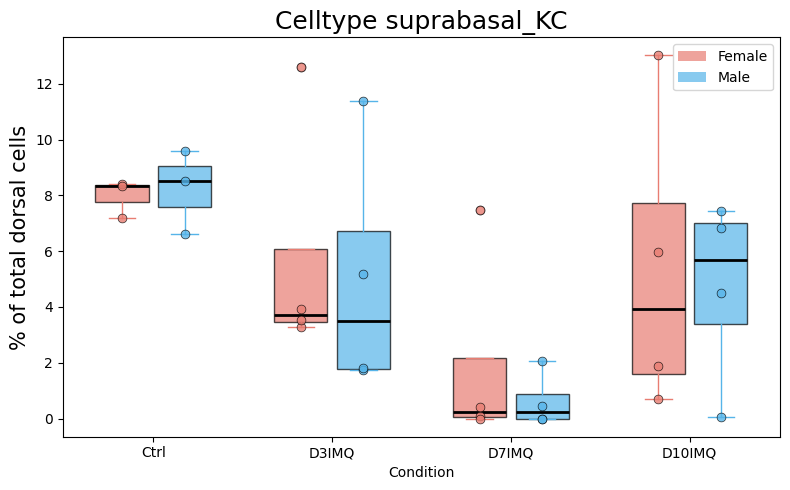

activated_suprabasal_KC


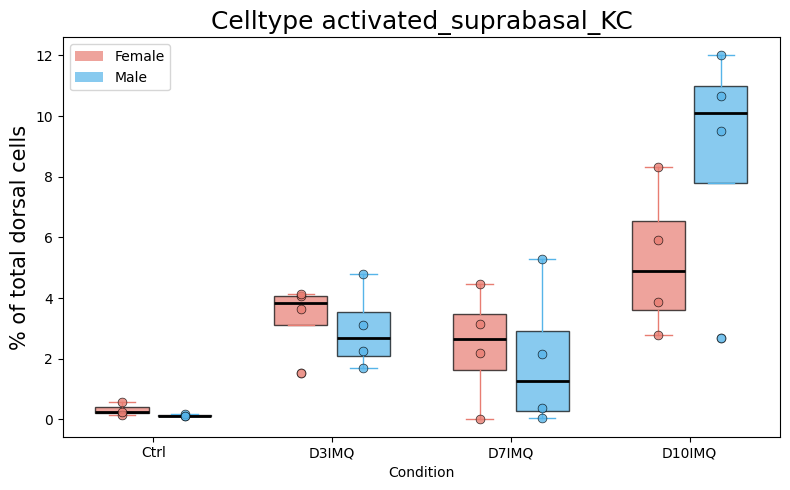

corneocyte


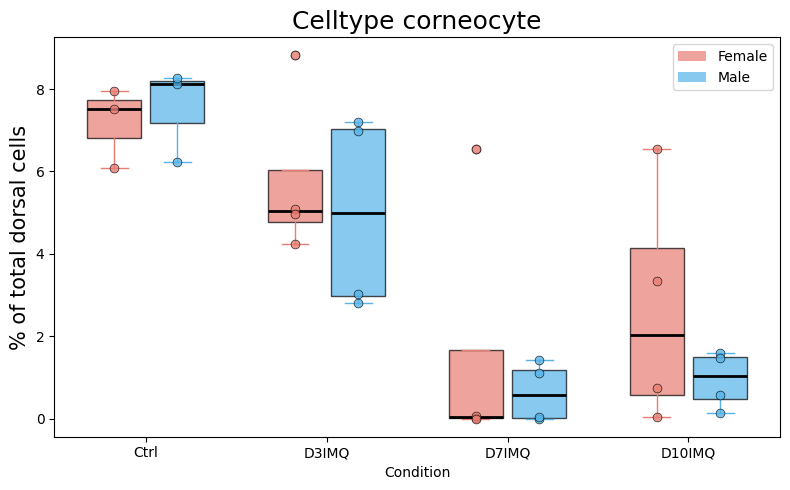

activated_corneocyte


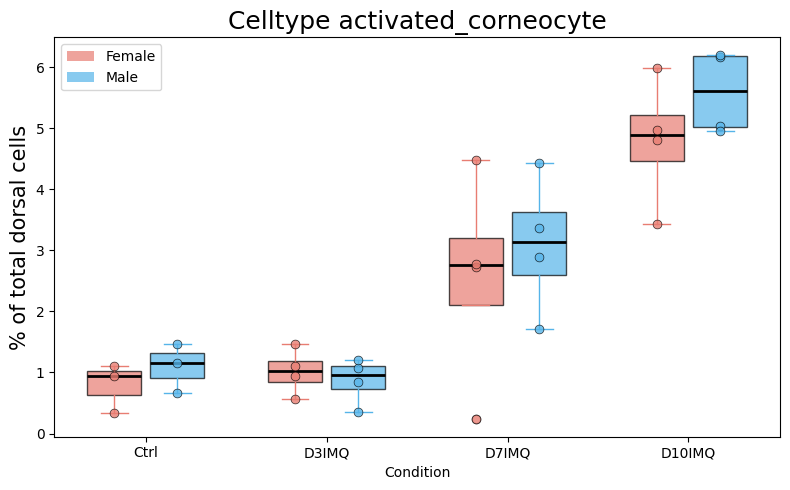

late_activated_suprabasal_KC


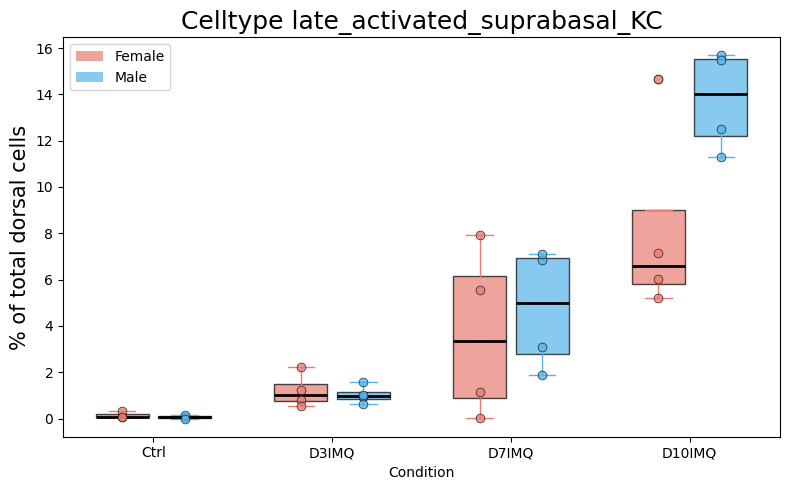

neutrophil


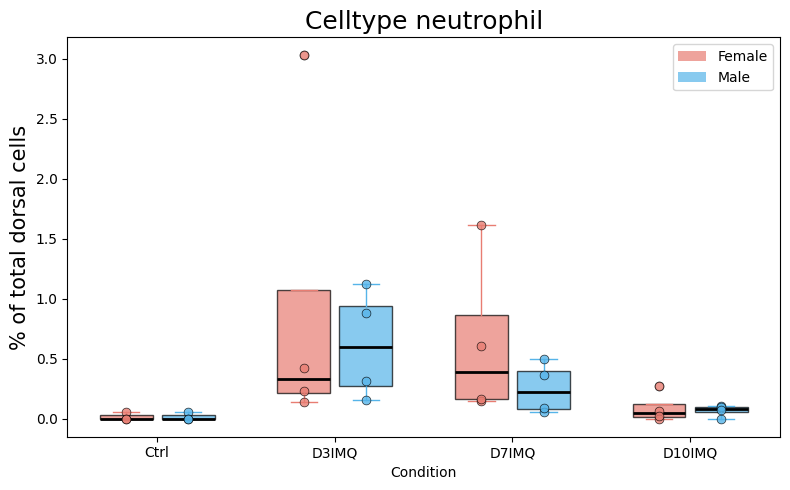

chondrocyte


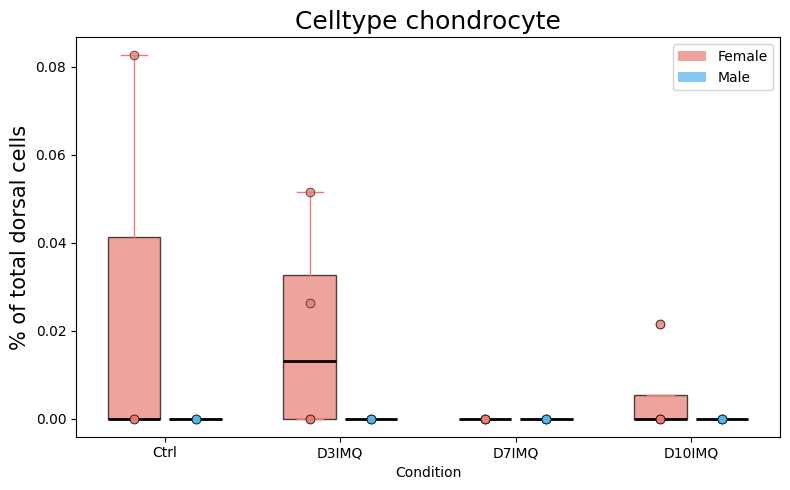

activated_intermediate_basal_suprabasal_KC


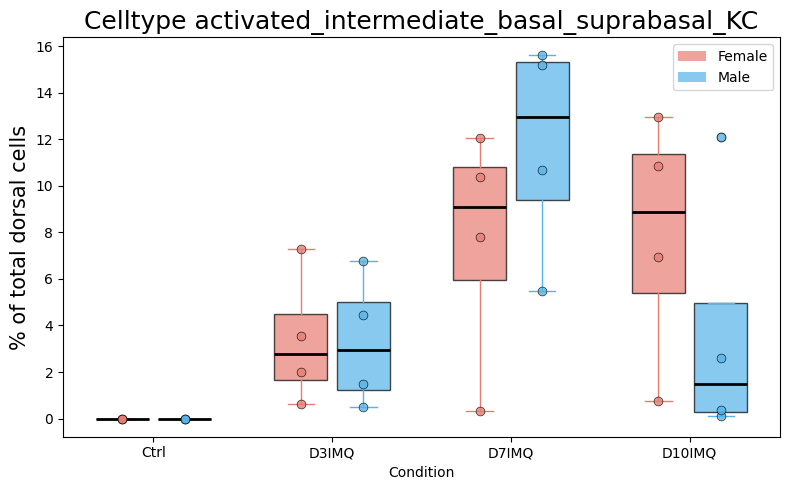

activated_spinous


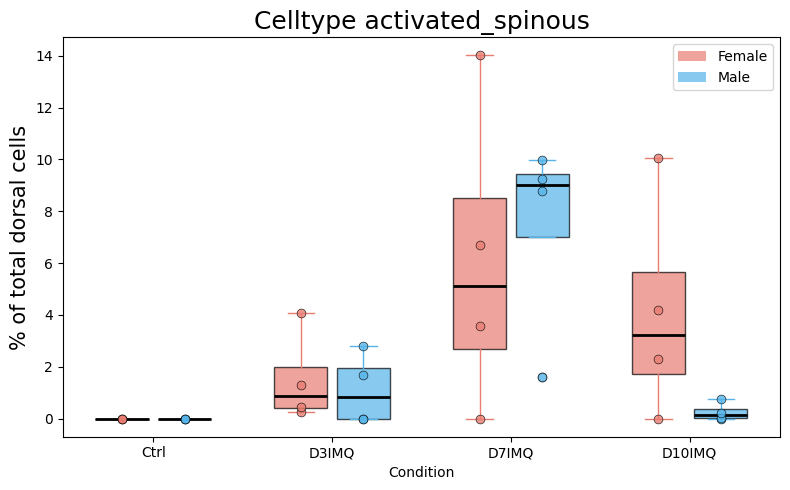

In [ ]:
#NORMALISING TO TOTAL CELLS IN REPLICATE

import matplotlib.pyplot as plt
import pandas as pd

condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

# Convert to string to avoid categorical dtype issues
bdata.obs['batch_key'] = bdata.obs['batch_key'].astype(str)
bdata.obs['celltype_assignments'] = bdata.obs['celltype_assignments'].astype(str)

batch_totals = bdata.obs['batch_key'].value_counts()

for cluster in bdata.obs['celltype_assignments'].unique():
    print(cluster)
    cluster_data = bdata[bdata.obs['celltype_assignments'] == cluster].copy()

    batch_counts = cluster_data.obs['batch_key'].value_counts()

    props = (batch_counts / batch_totals * 100).rename('proportion').reset_index()
    props.columns = ['batch_key', 'proportion']
    props['condition'] = props['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    props['sex'] = props['batch_key'].str.extract(r'_([FM])\d+$')

    all_batches = bdata.obs[['batch_key']].drop_duplicates().copy()
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex'] = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    # Convert all relevant columns to string before merge/fillna
    for df in [props, all_batches]:
        for col in ['batch_key', 'condition', 'sex']:
            df[col] = df[col].astype(str)

    props = all_batches.merge(props[['batch_key', 'proportion']], on='batch_key', how='left')
    props['proportion'] = props['proportion'].fillna(0)  # Only fillna on the numeric column

    fig, ax = plt.subplots(figsize=(8, 5))

    sex_colors = {'F': '#E87D72', 'M': '#56B4E9'}
    sex_labels = {'F': 'Female', 'M': 'Male'}
    width = 0.35
    x = range(len(condition_order))

    for i, (sex, offset) in enumerate({'F': -width/2, 'M': width/2}.items()):
        sex_data = props[props['sex'] == sex]

        box_data = [
            sex_data.loc[sex_data['condition'] == cond, 'proportion'].values
            for cond in condition_order
        ]

        positions = [xi + offset for xi in x]
        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            boxprops=dict(facecolor=sex_colors[sex], alpha=0.7),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color=sex_colors[sex]),
            capprops=dict(color=sex_colors[sex]),
            flierprops=dict(marker='o', color=sex_colors[sex], alpha=0.5)
        )

        for pos, vals in zip(positions, box_data):
            ax.scatter(
                [pos] * len(vals), vals,
                color=sex_colors[sex], edgecolors='black',
                linewidths=0.5, zorder=5, s=40, alpha=0.8
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(condition_order)
    ax.set_title(f'Celltype {cluster}', fontsize=18)
    ax.set_xlabel('Condition')
    ax.set_ylabel('% of total dorsal cells', fontsize=15)

    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=sex_colors[s], alpha=0.7, label=sex_labels[s]) for s in ['F', 'M']]
    ax.legend(handles=handles)

    plt.tight_layout()
    plt.show()

perichondral_fibroblast


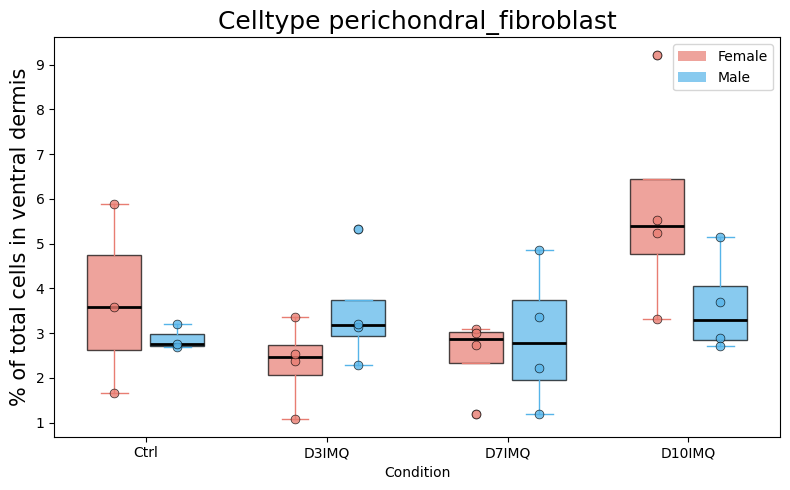

dermal_fibroblast


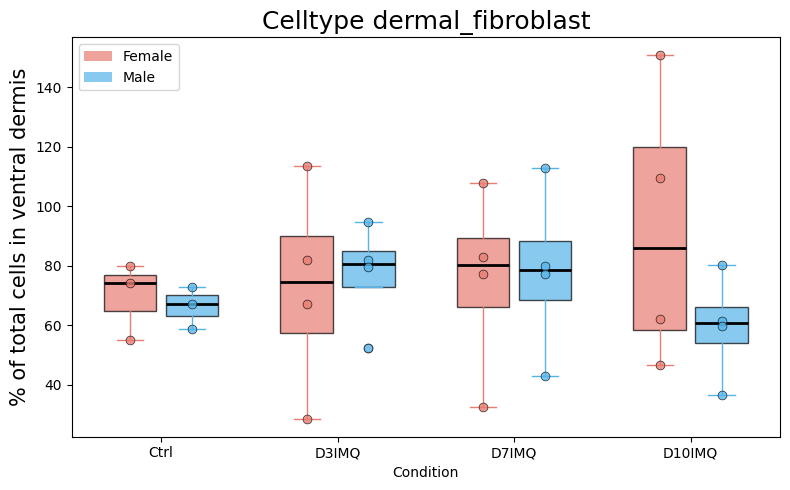

smc


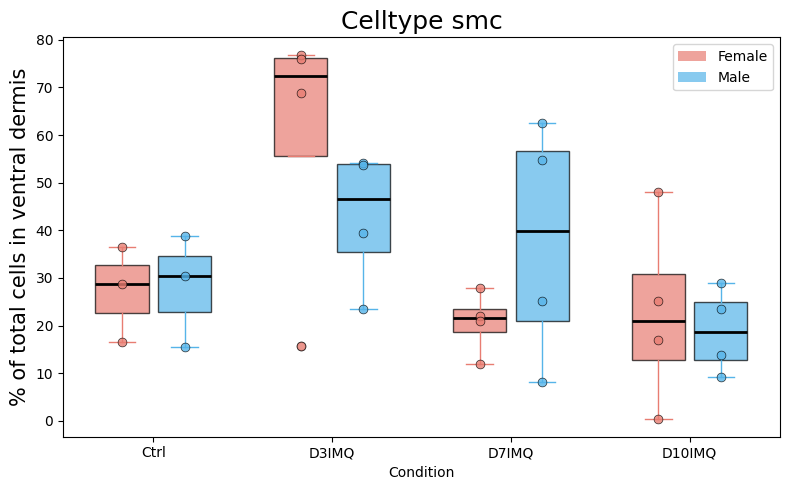

myeloid


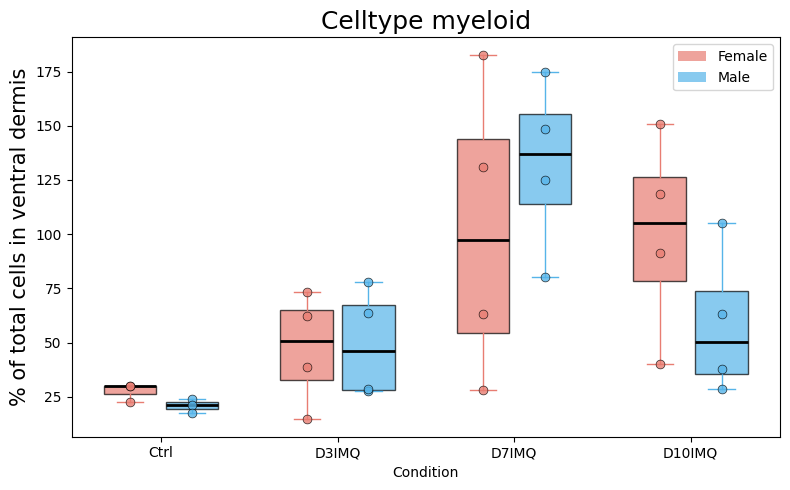

endothelial


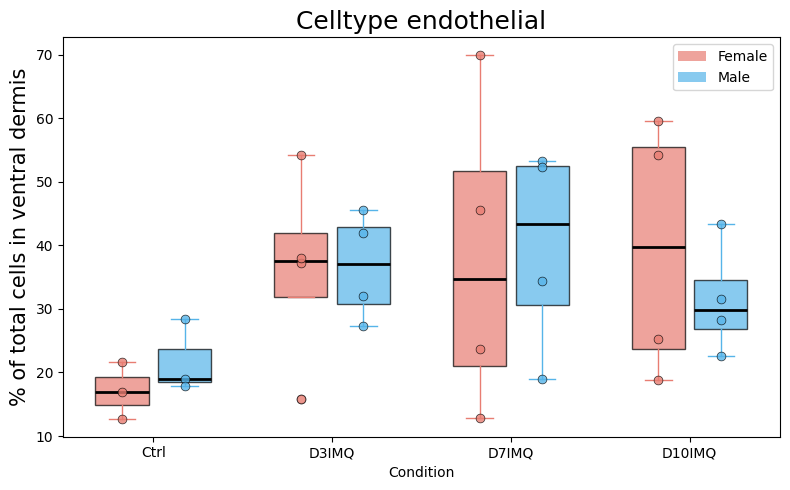

follicle_cell


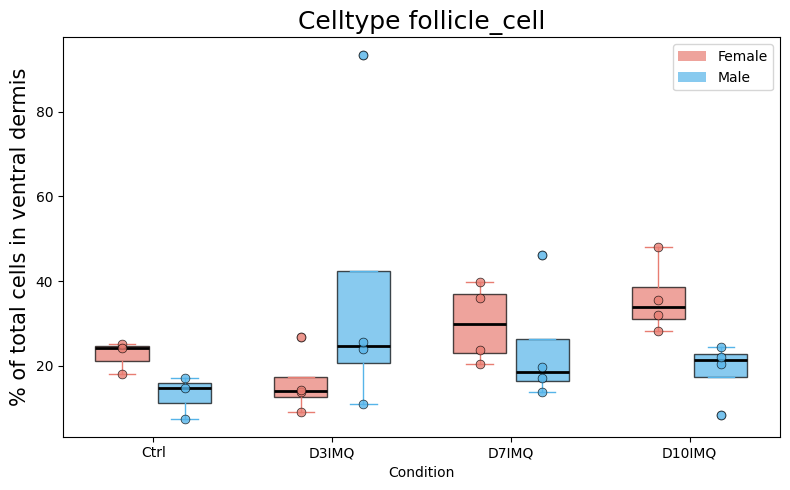

schwann_cell


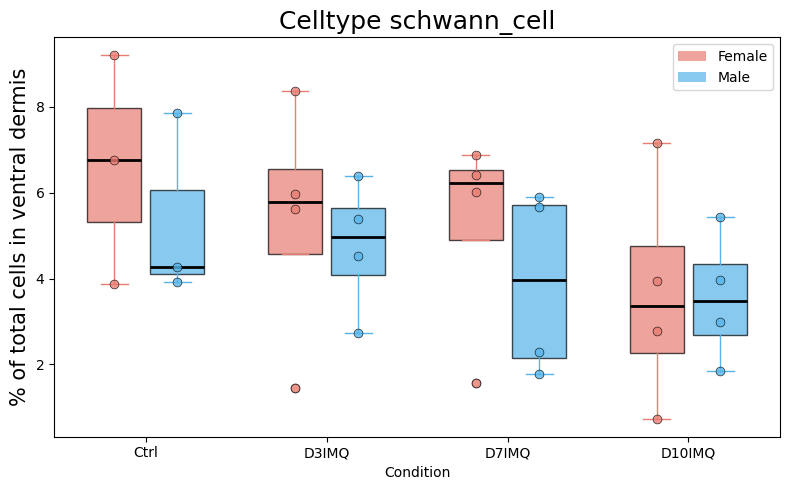

M2-like_macrophage


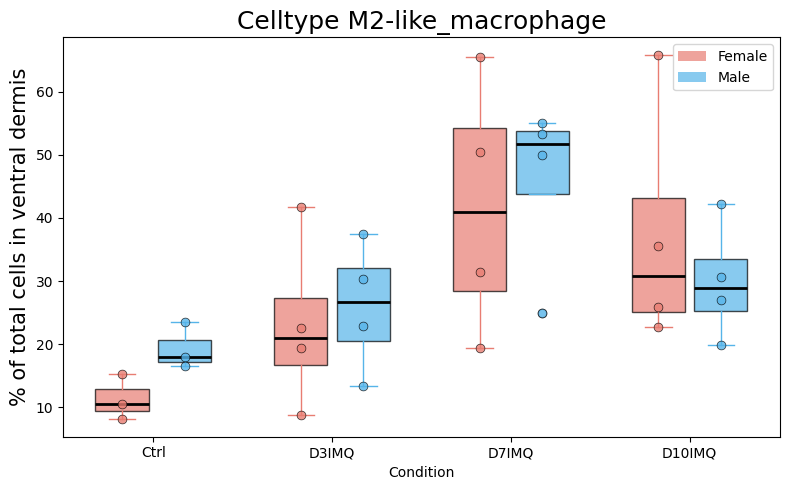

activated_basal_KC


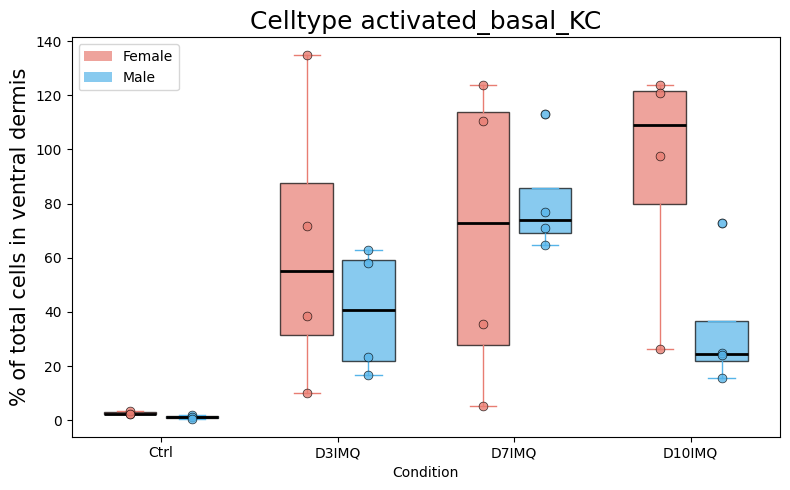

mast_cell


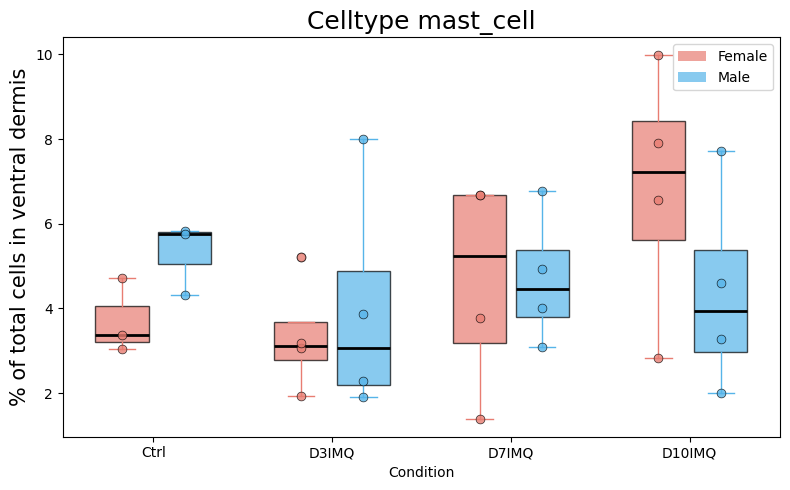

sebaceous_epithelial


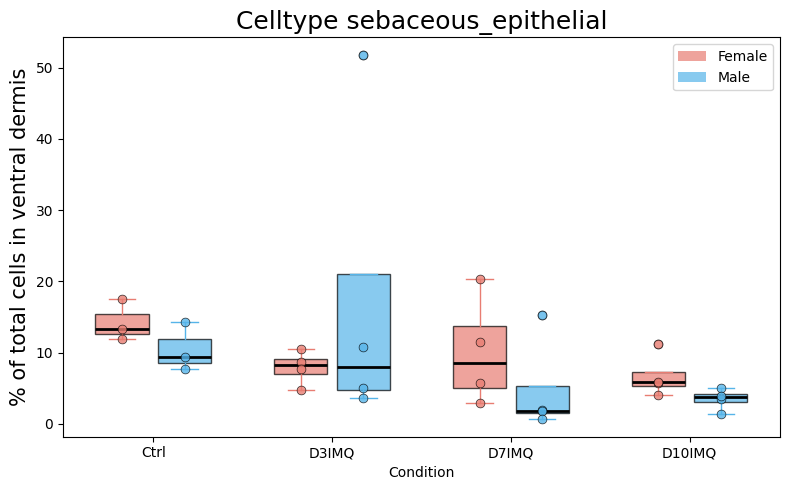

adipocyte


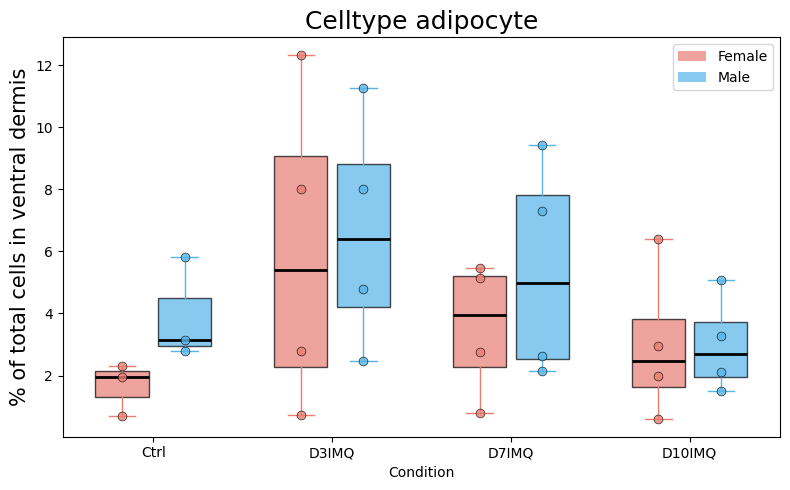

intermediate_basal_suprabasal_KC


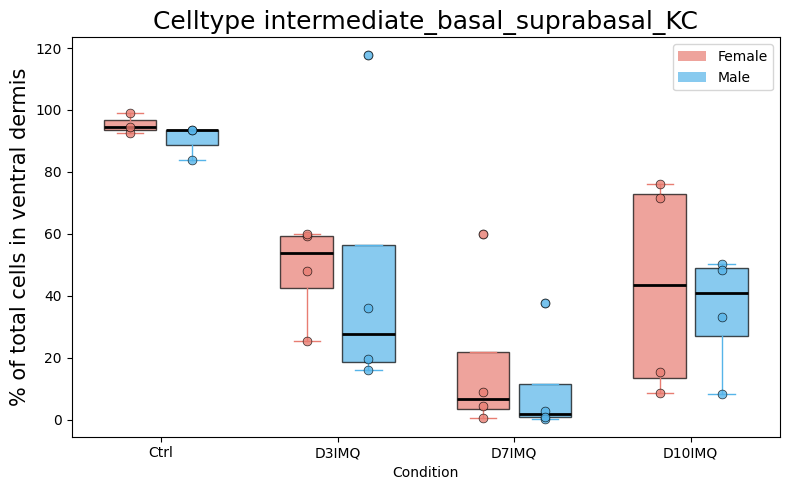

basal_KC


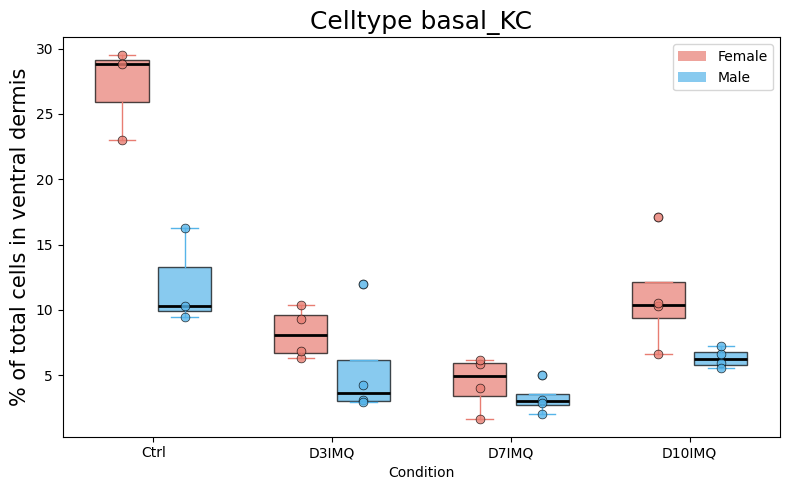

suprabasal_KC


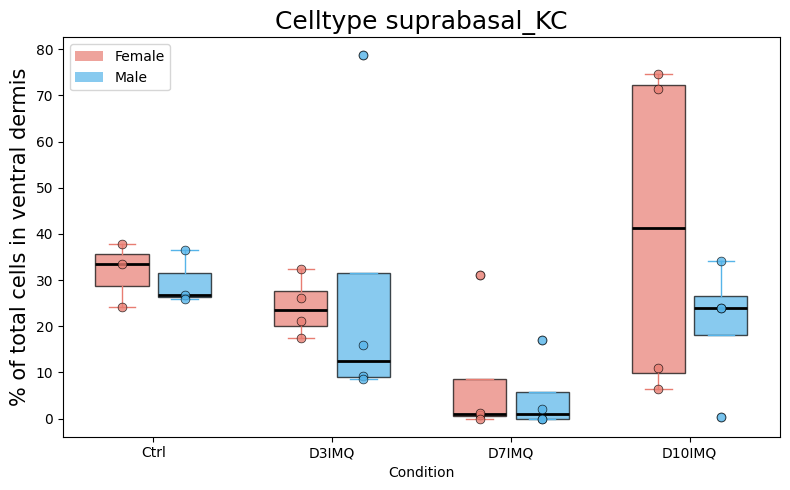

activated_suprabasal_KC


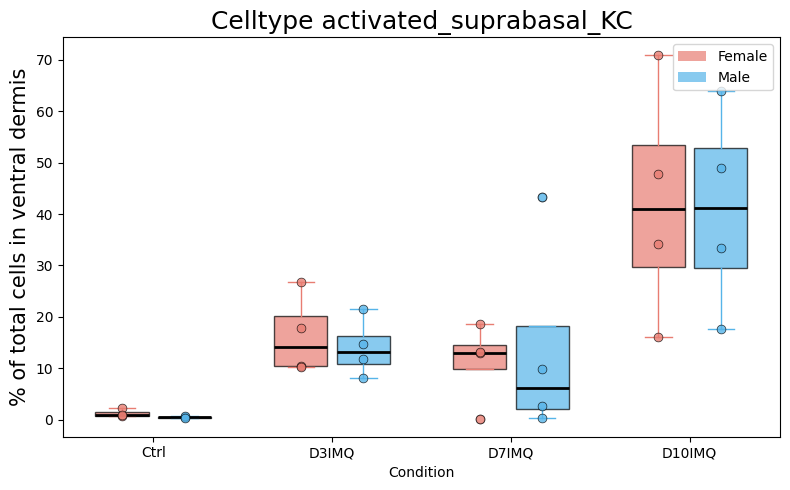

corneocyte


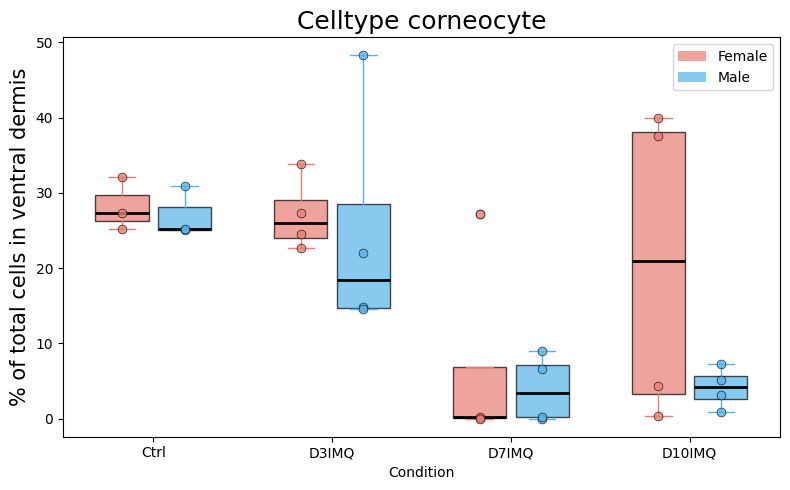

activated_corneocyte


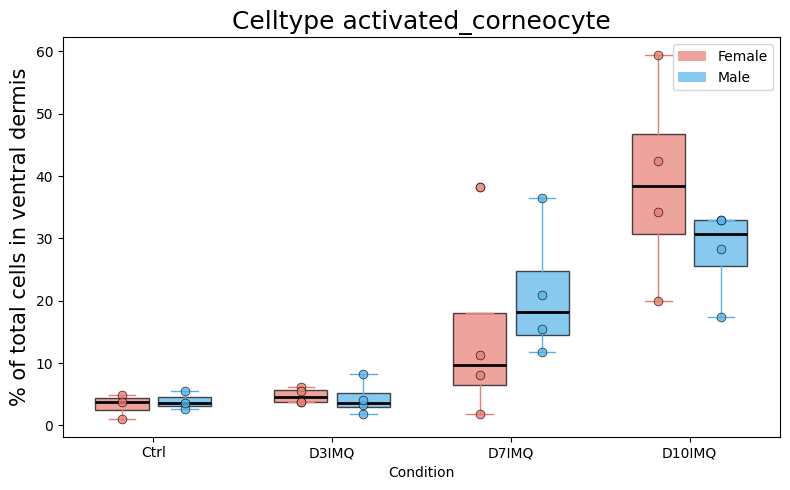

late_activated_suprabasal_KC


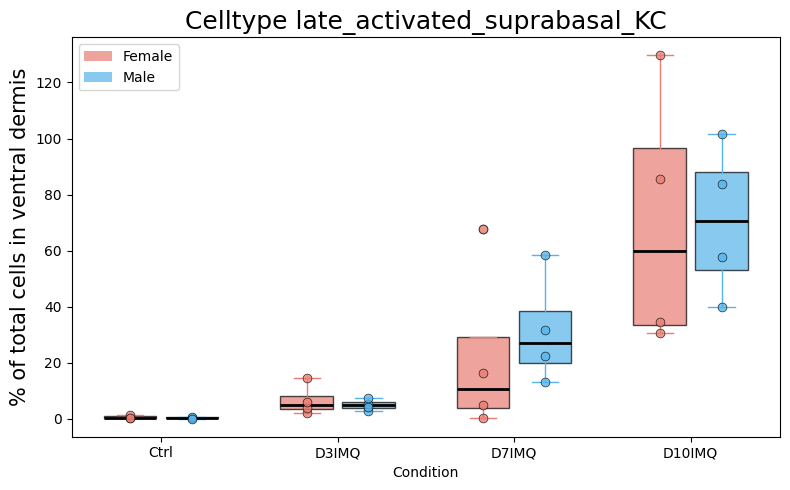

neutrophil


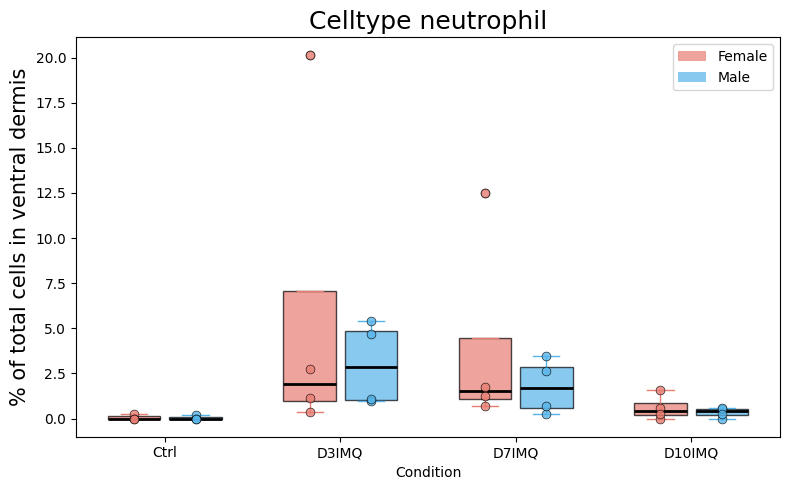

chondrocyte


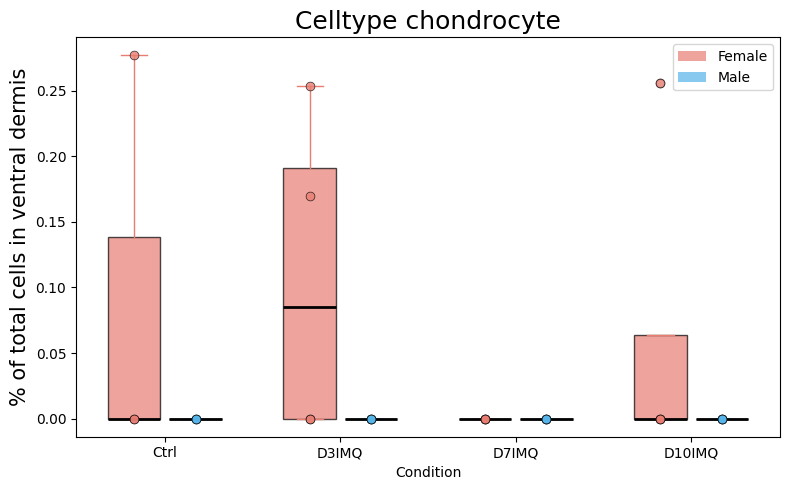

activated_intermediate_basal_suprabasal_KC


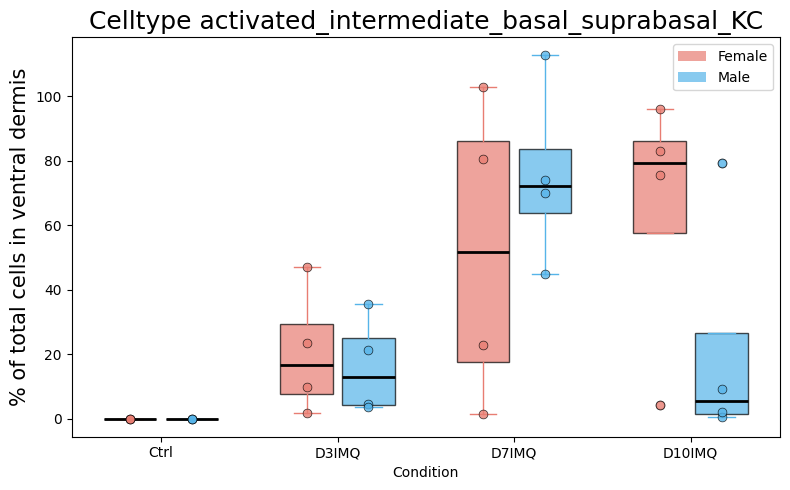

activated_spinous


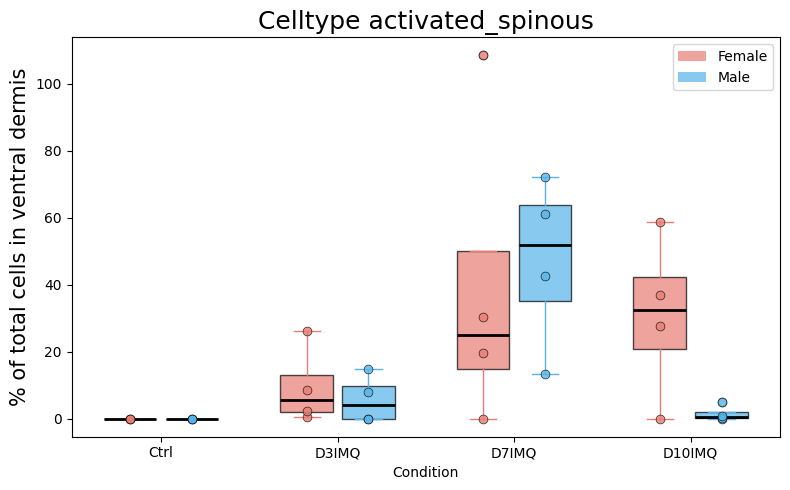

In [ ]:
#CELLS NORMALISED TO WHATEVER COMPARTMENT IS IN 'normalisation_compartment'

import matplotlib.pyplot as plt
import pandas as pd



condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

# Convert to string to avoid categorical dtype issues
bdata.obs['batch_key'] = bdata.obs['batch_key'].astype(str)
bdata.obs['celltype_assignments'] = bdata.obs['celltype_assignments'].astype(str)

batch_totals = cdata.obs['batch_key'].astype(str).value_counts() #KEY NORMALISATION STEP THAT DIFFERS FROM ABOVE FUNCTION

for cluster in bdata.obs['celltype_assignments'].unique():
    print(cluster)
    cluster_data = bdata[bdata.obs['celltype_assignments'] == cluster].copy()

    batch_counts = cluster_data.obs['batch_key'].value_counts()

    props = (batch_counts / batch_totals * 100).rename('proportion').reset_index()
    props.columns = ['batch_key', 'proportion']
    props['condition'] = props['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    props['sex'] = props['batch_key'].str.extract(r'_([FM])\d+$')

    all_batches = bdata.obs[['batch_key']].drop_duplicates().copy()
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex'] = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    # Convert all relevant columns to string before merge/fillna
    for df in [props, all_batches]:
        for col in ['batch_key', 'condition', 'sex']:
            df[col] = df[col].astype(str)

    props = all_batches.merge(props[['batch_key', 'proportion']], on='batch_key', how='left')
    props['proportion'] = props['proportion'].fillna(0)  # Only fillna on the numeric column

    fig, ax = plt.subplots(figsize=(8, 5))

    sex_colors = {'F': '#E87D72', 'M': '#56B4E9'}
    sex_labels = {'F': 'Female', 'M': 'Male'}
    width = 0.35
    x = range(len(condition_order))

    for i, (sex, offset) in enumerate({'F': -width/2, 'M': width/2}.items()):
        sex_data = props[props['sex'] == sex]

        box_data = [
            sex_data.loc[sex_data['condition'] == cond, 'proportion'].values
            for cond in condition_order
        ]

        positions = [xi + offset for xi in x]
        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            boxprops=dict(facecolor=sex_colors[sex], alpha=0.7),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color=sex_colors[sex]),
            capprops=dict(color=sex_colors[sex]),
            flierprops=dict(marker='o', color=sex_colors[sex], alpha=0.5)
        )

        for pos, vals in zip(positions, box_data):
            ax.scatter(
                [pos] * len(vals), vals,
                color=sex_colors[sex], edgecolors='black',
                linewidths=0.5, zorder=5, s=40, alpha=0.8
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(condition_order)
    ax.set_title(f'Celltype {cluster}', fontsize=18)
    ax.set_xlabel('Condition')
    ax.set_ylabel('% of total cells in ventral dermis', fontsize=15) #MAKE SURE YOU CHANGE THIS TO WHATEVER IS IN NORMALISATION COMPARTMENT

    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=sex_colors[s], alpha=0.7, label=sex_labels[s]) for s in ['F', 'M']]
    ax.legend(handles=handles)

    plt.tight_layout()
    plt.show()

perichondral_fibroblast


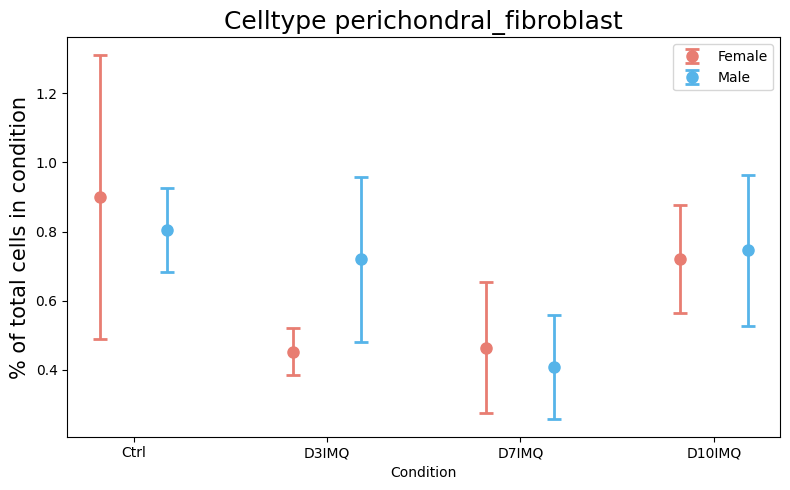

dermal_fibroblast


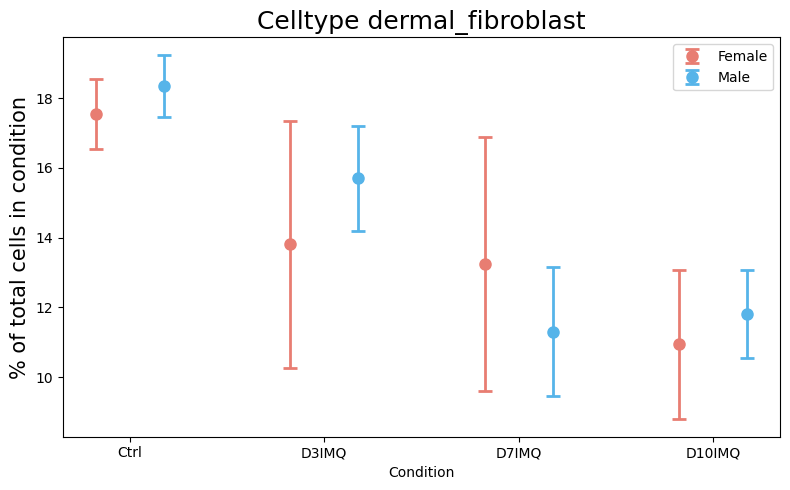

smc


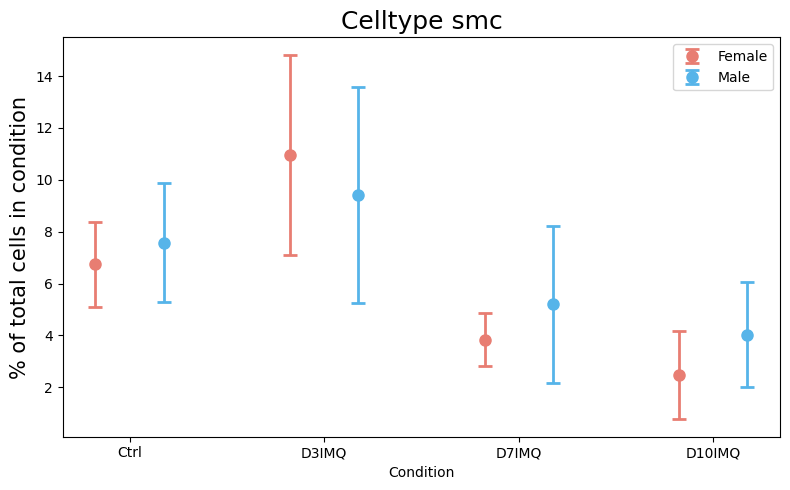

myeloid


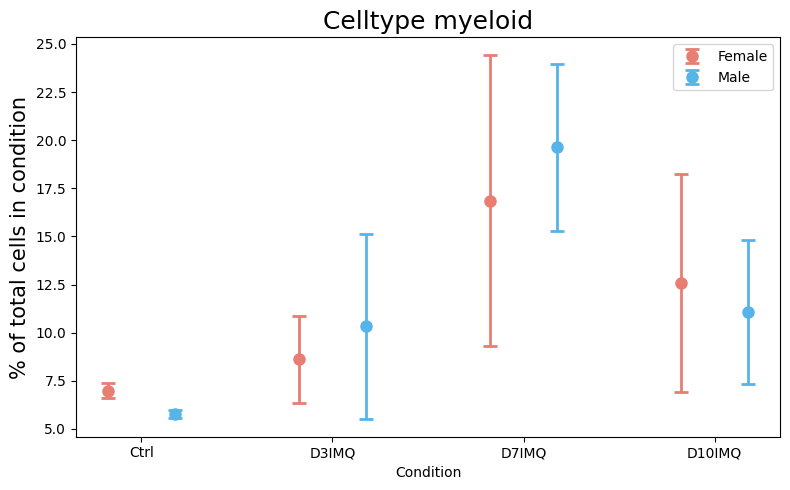

endothelial


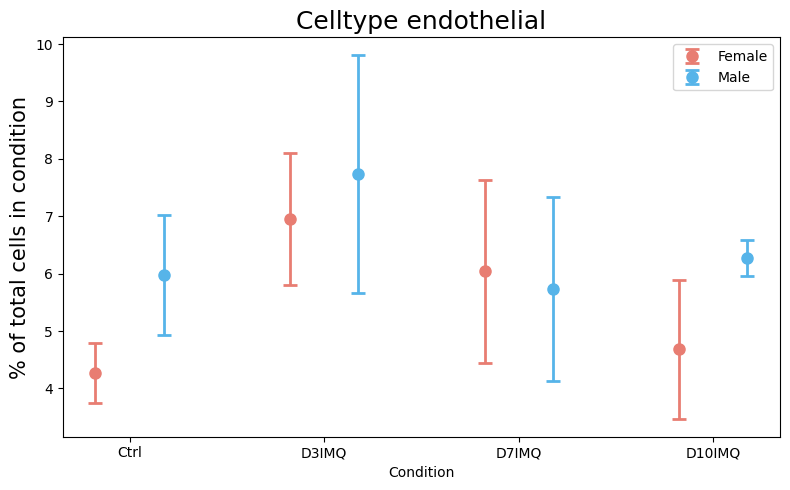

follicle_cell


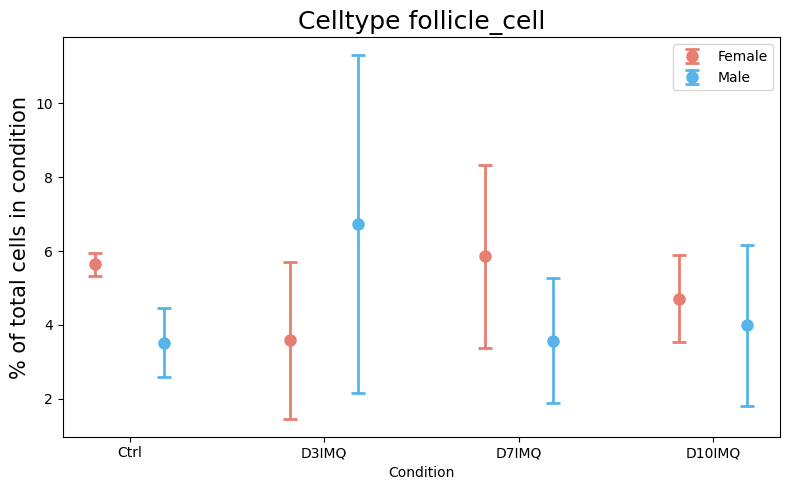

schwann_cell


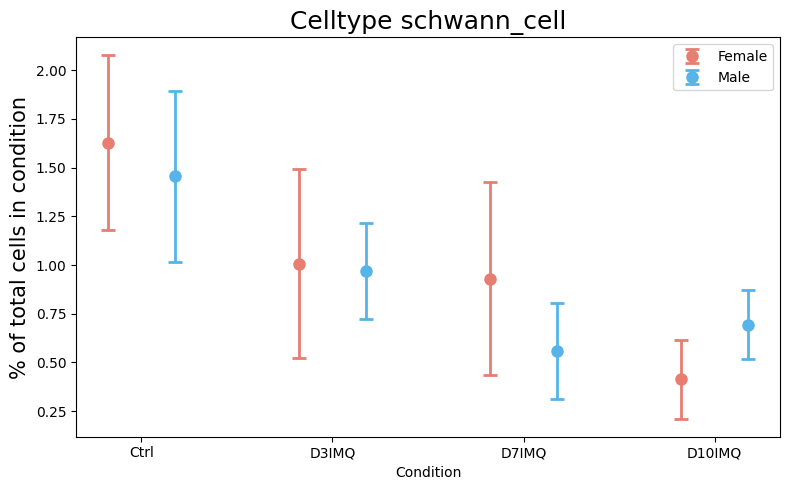

M2-like_macrophage


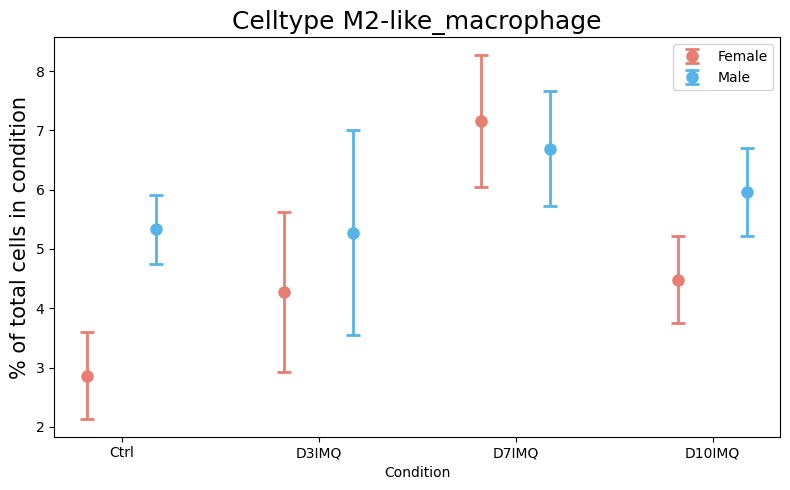

activated_basal_KC


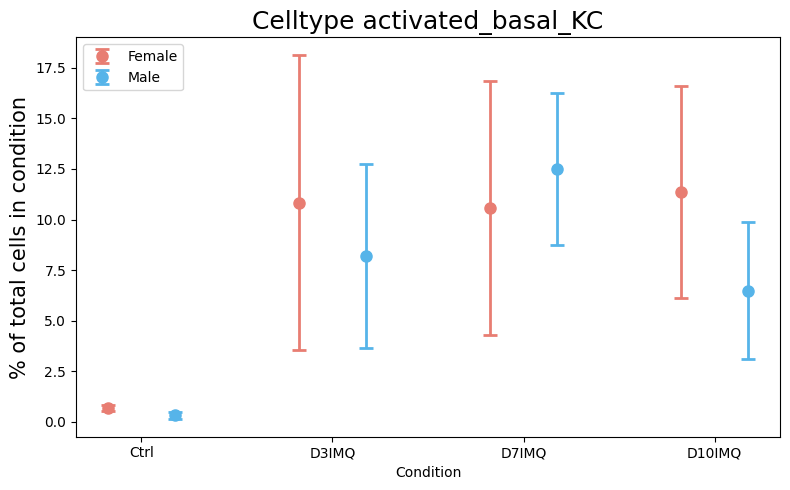

mast_cell


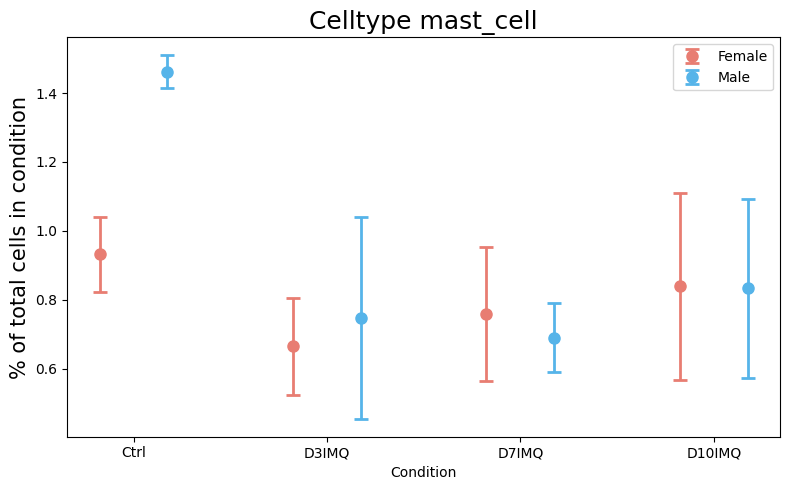

sebaceous_epithelial


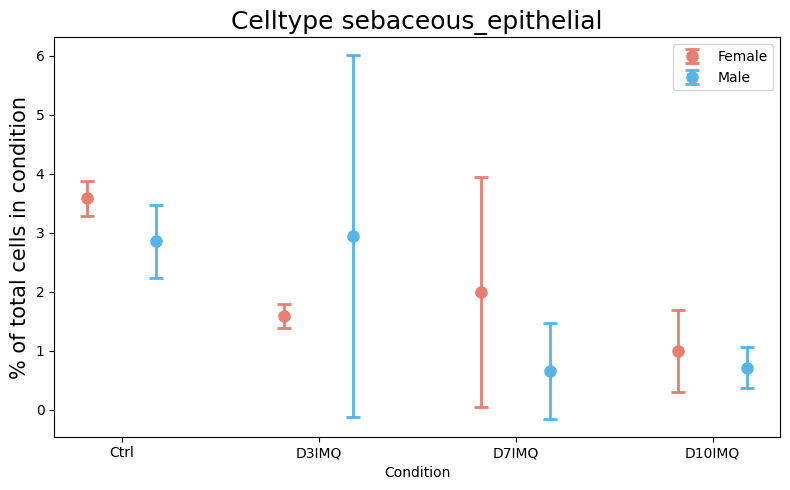

adipocyte


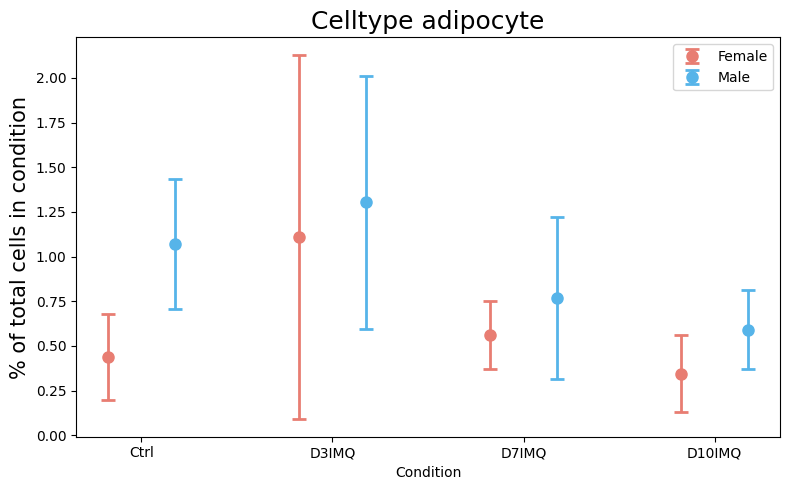

intermediate_basal_suprabasal_KC


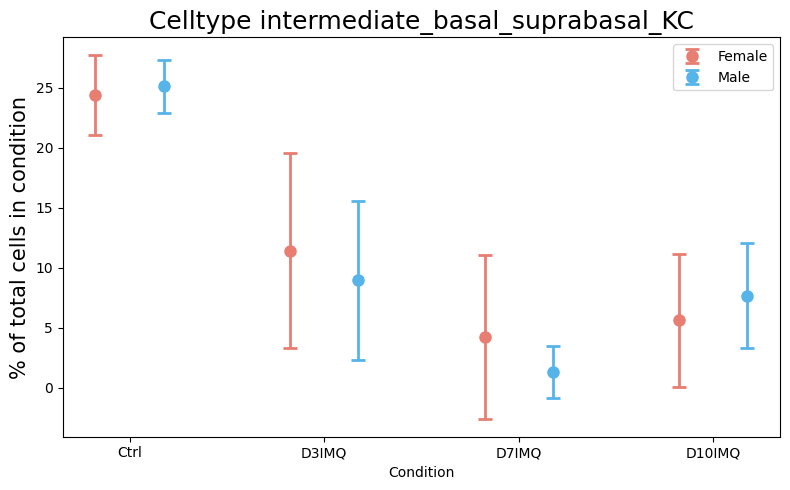

basal_KC


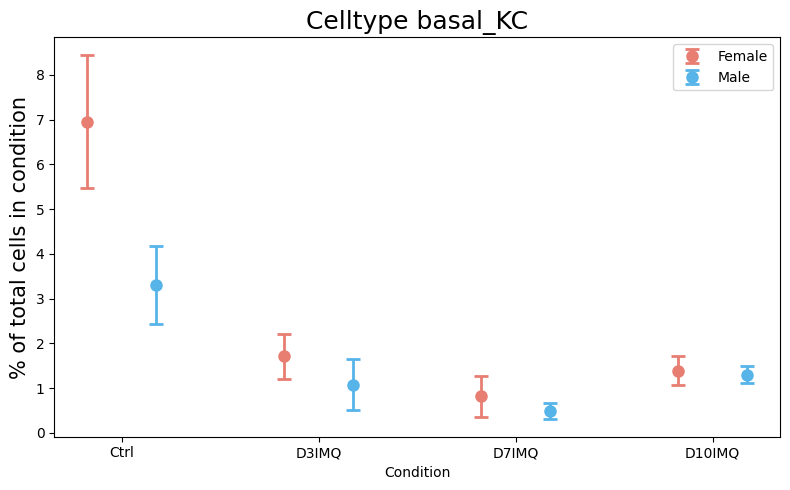

suprabasal_KC


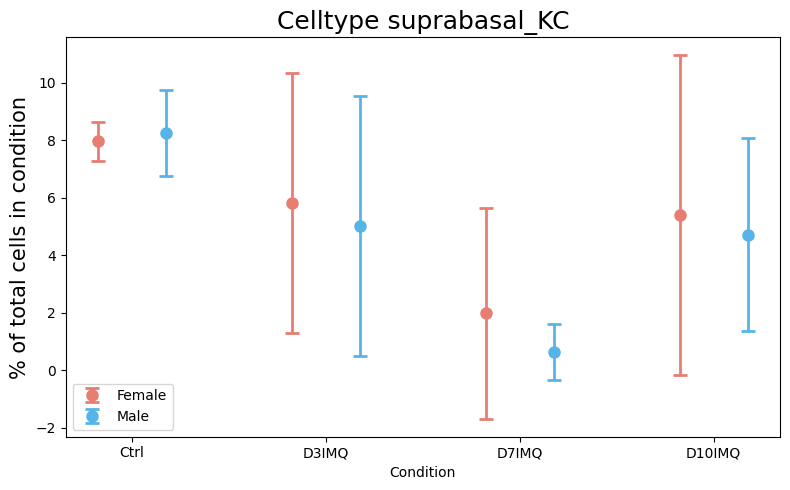

activated_suprabasal_KC


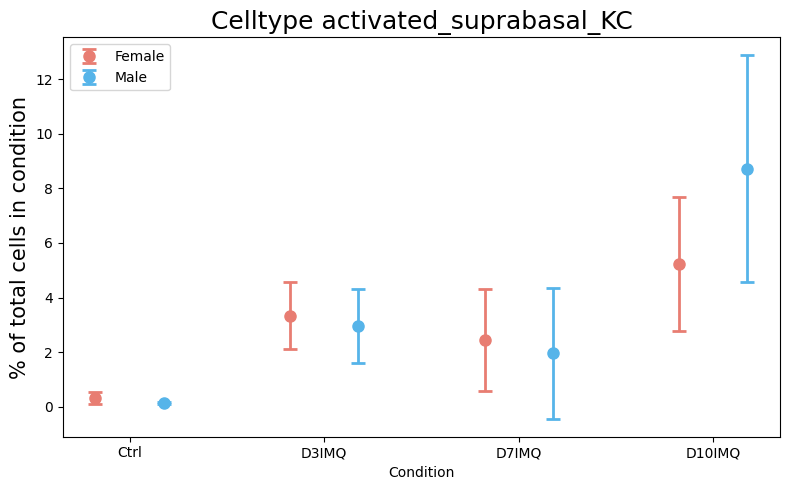

corneocyte


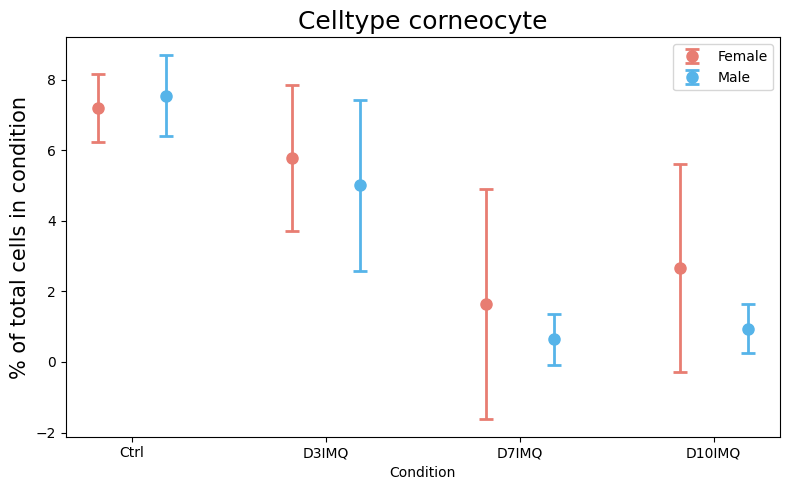

activated_corneocyte


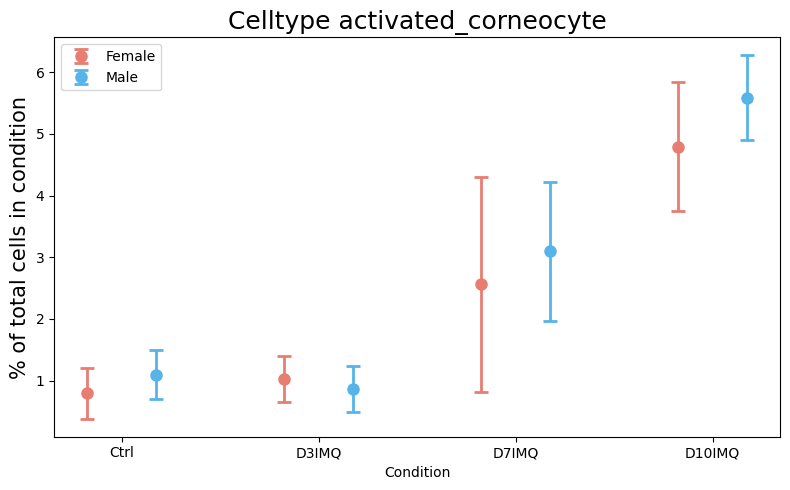

late_activated_suprabasal_KC


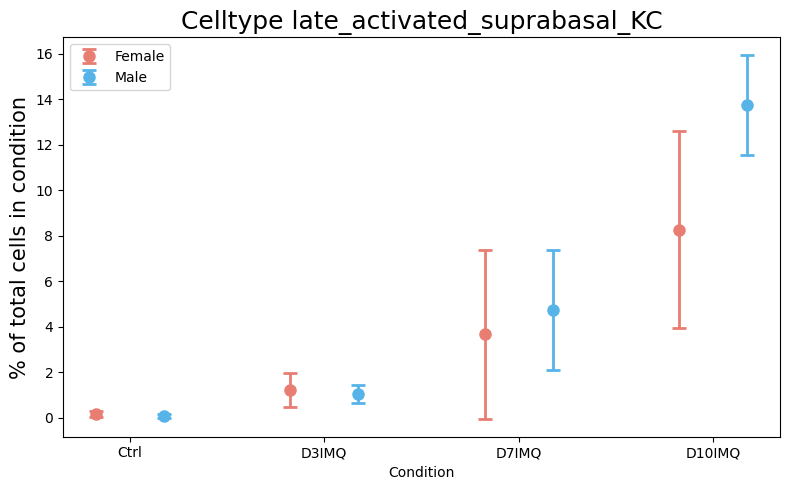

neutrophil


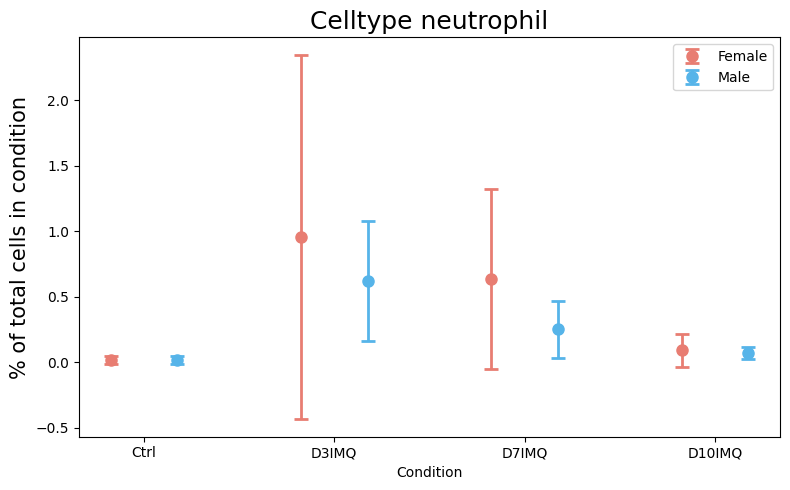

chondrocyte


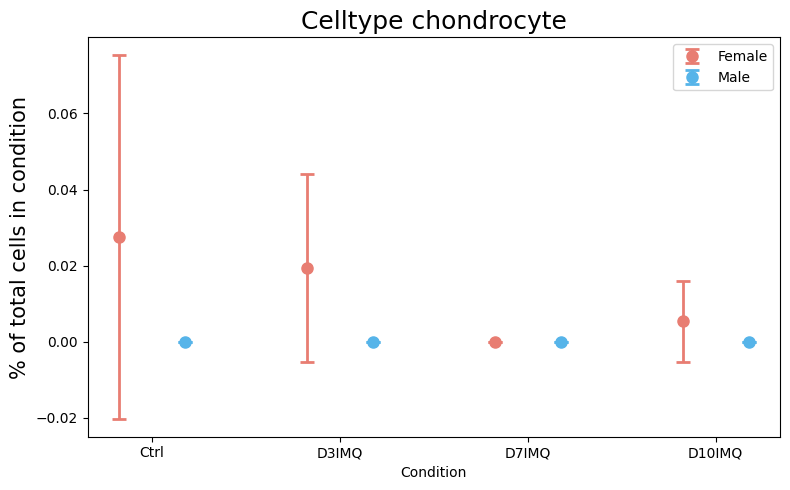

activated_intermediate_basal_suprabasal_KC


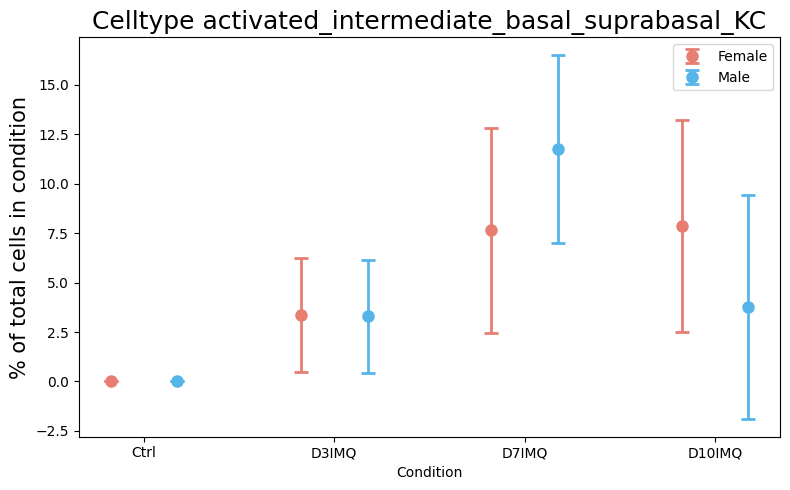

activated_spinous


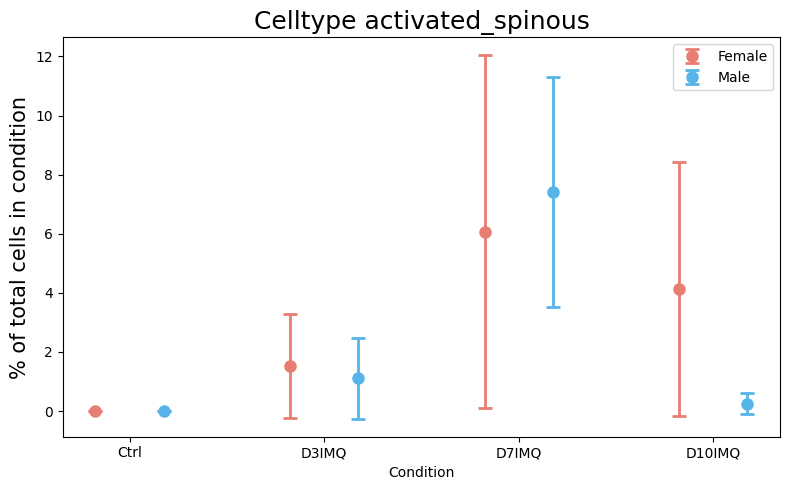

In [ ]:
#normalised to total cells across condition (dorsal side)
#mean and error bar (std) version of above plot

import matplotlib.pyplot as plt
import pandas as pd

condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

# Convert to string to avoid categorical dtype issues
bdata.obs['batch_key'] = bdata.obs['batch_key'].astype(str)
bdata.obs['celltype_assignments'] = bdata.obs['celltype_assignments'].astype(str)

batch_totals = bdata.obs['batch_key'].value_counts()

for cluster in bdata.obs['celltype_assignments'].unique():
    print(cluster)
    cluster_data = bdata[bdata.obs['celltype_assignments'] == cluster].copy()

    batch_counts = cluster_data.obs['batch_key'].value_counts()

    props = (batch_counts / batch_totals * 100).rename('proportion').reset_index()
    props.columns = ['batch_key', 'proportion']
    props['condition'] = props['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    props['sex'] = props['batch_key'].str.extract(r'_([FM])\d+$')

    all_batches = bdata.obs[['batch_key']].drop_duplicates().copy()
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex'] = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    # Convert all relevant columns to string before merge/fillna
    for df in [props, all_batches]:
        for col in ['batch_key', 'condition', 'sex']:
            df[col] = df[col].astype(str)

    props = all_batches.merge(props[['batch_key', 'proportion']], on='batch_key', how='left')
    props['proportion'] = props['proportion'].fillna(0)  # Only fillna on the numeric column

    fig, ax = plt.subplots(figsize=(8, 5))

    sex_colors = {'F': '#E87D72', 'M': '#56B4E9'}
    sex_labels = {'F': 'Female', 'M': 'Male'}
    width = 0.35
    x = range(len(condition_order))

    for sex, offset in {'F': -width/2, 'M': width/2}.items():
        sex_data = props[props['sex'] == sex]

        means = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].mean() for cond in condition_order]
        stds  = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].std()  for cond in condition_order]

        positions = [xi + offset for xi in x]

        ax.errorbar(
            positions, means, yerr=stds,
            fmt='o', color=sex_colors[sex],
            ecolor=sex_colors[sex], elinewidth=2,
            capsize=5, capthick=2,
            markersize=8, label=sex_labels[sex],
            zorder=3
        )

        # # Overlay individual points
        # for pos, cond in zip(positions, condition_order):
        #     vals = sex_data.loc[sex_data['condition'] == cond, 'proportion'].values
        #     ax.scatter(
        #         [pos] * len(vals), vals,
        #         color=sex_colors[sex], edgecolors='black',
        #         linewidths=0.5, zorder=5, s=30, alpha=0.6
        #     )

    ax.set_xticks(list(x))
    ax.set_xticklabels(condition_order)
    ax.set_title(f'Celltype {cluster}', fontsize=18)
    ax.set_xlabel('Condition')
    ax.set_ylabel('% of total cells in condition', fontsize=15)

    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=sex_colors[s], alpha=0.7, label=sex_labels[s]) for s in ['F', 'M']]
    ax.legend()

    plt.tight_layout()
    plt.show()

perichondral_fibroblast


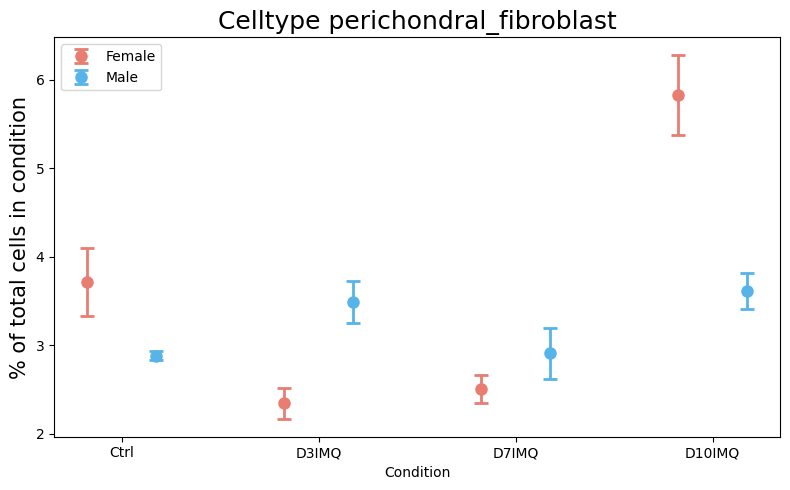

dermal_fibroblast


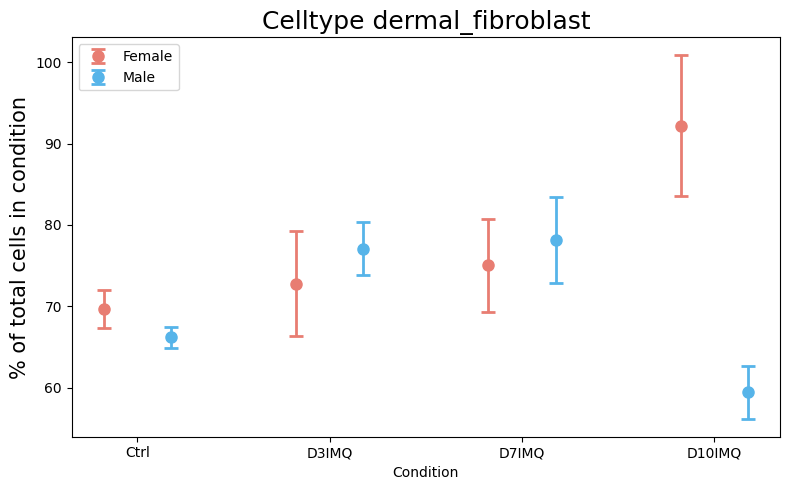

smc


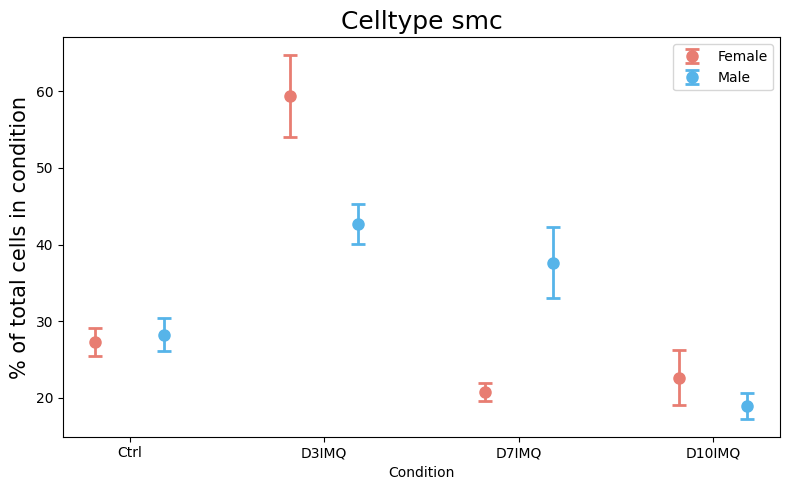

myeloid


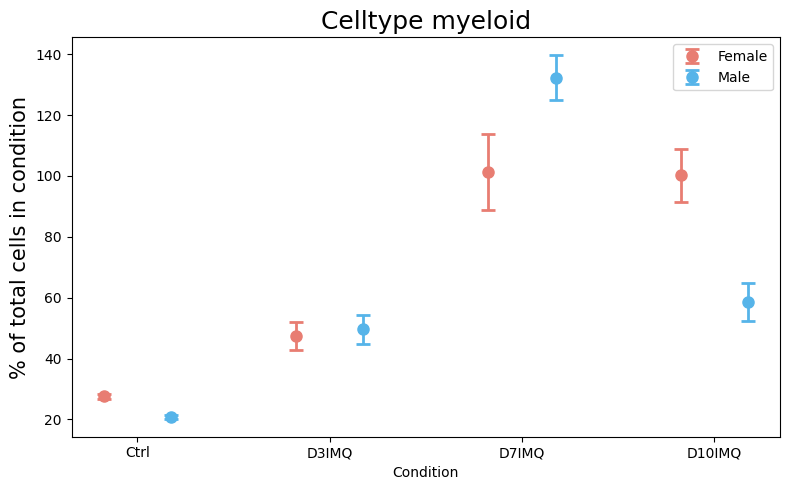

endothelial


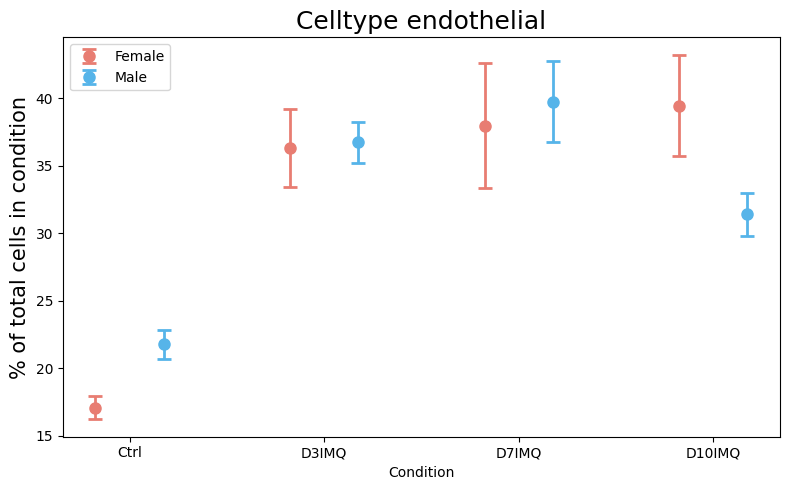

follicle_cell


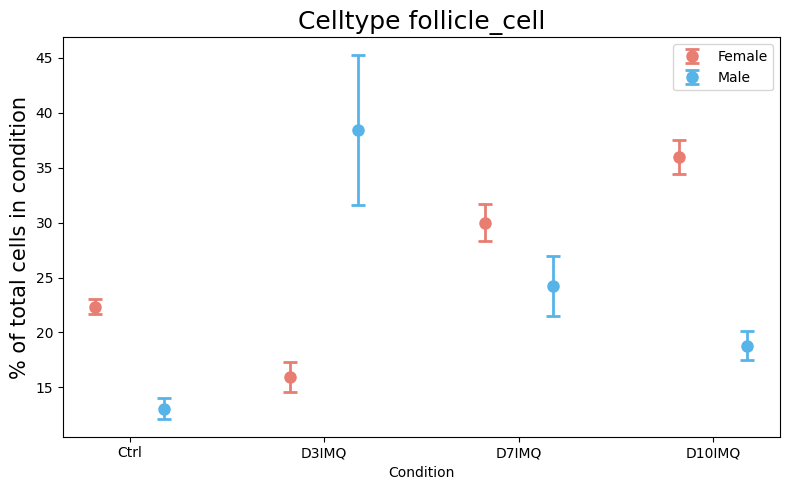

schwann_cell


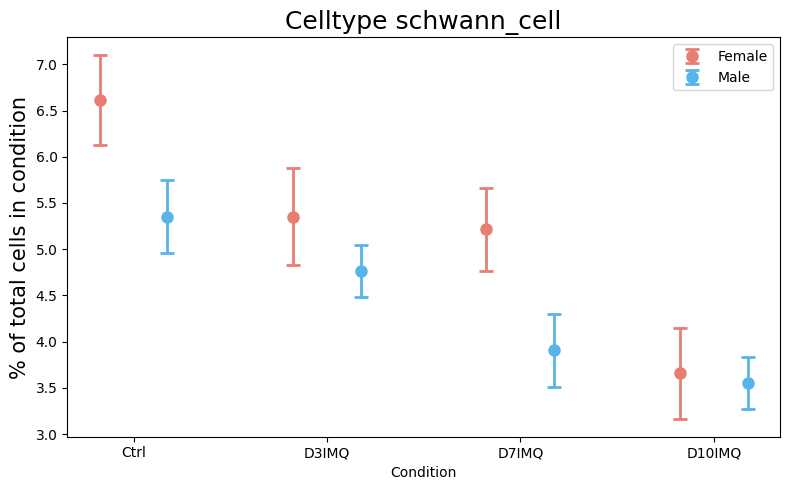

M2-like_macrophage


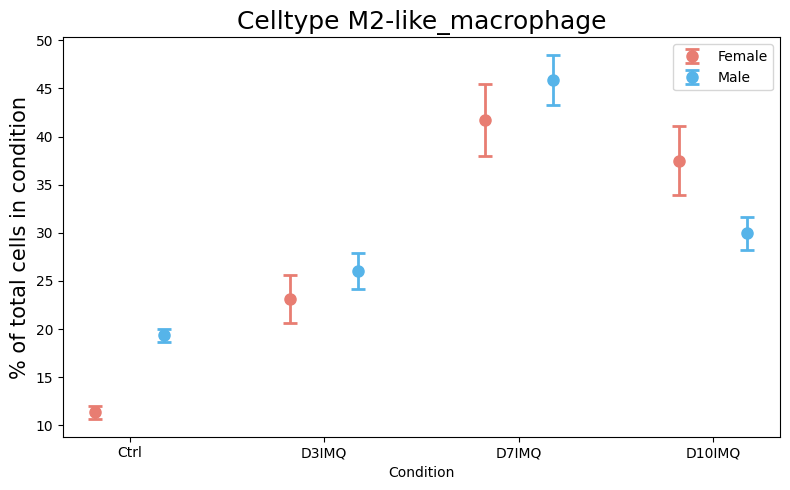

activated_basal_KC


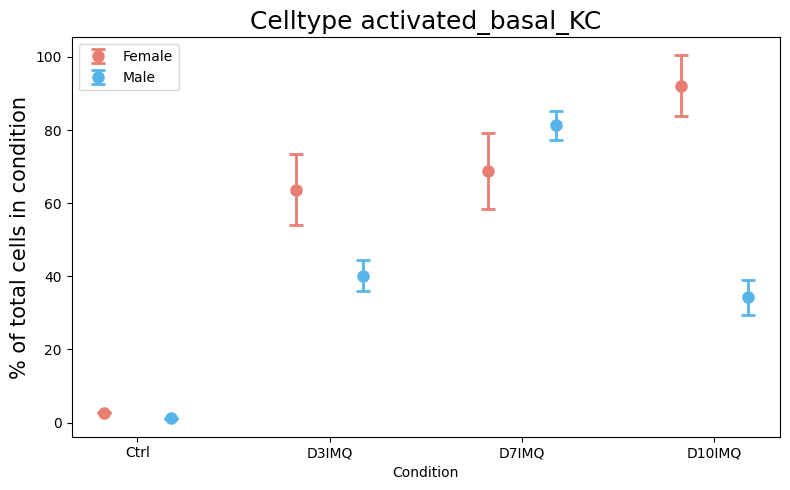

mast_cell


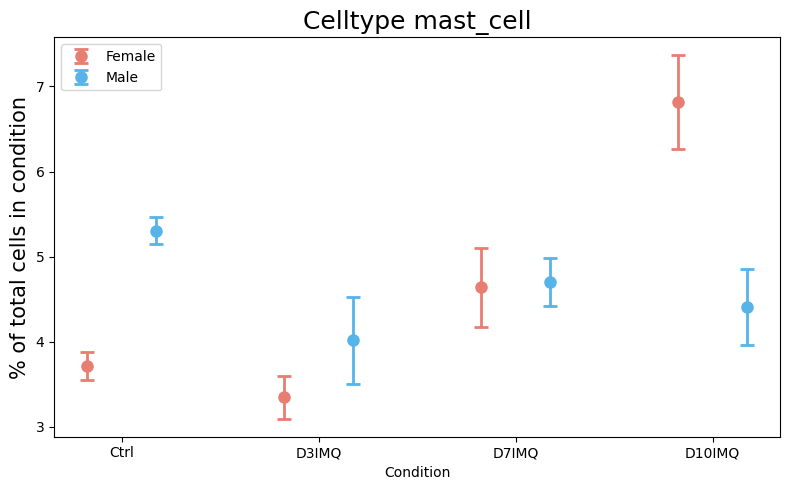

sebaceous_epithelial


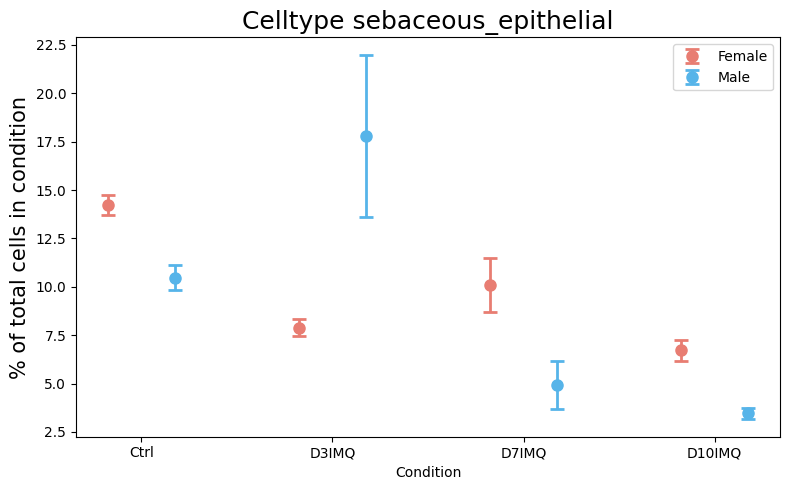

adipocyte


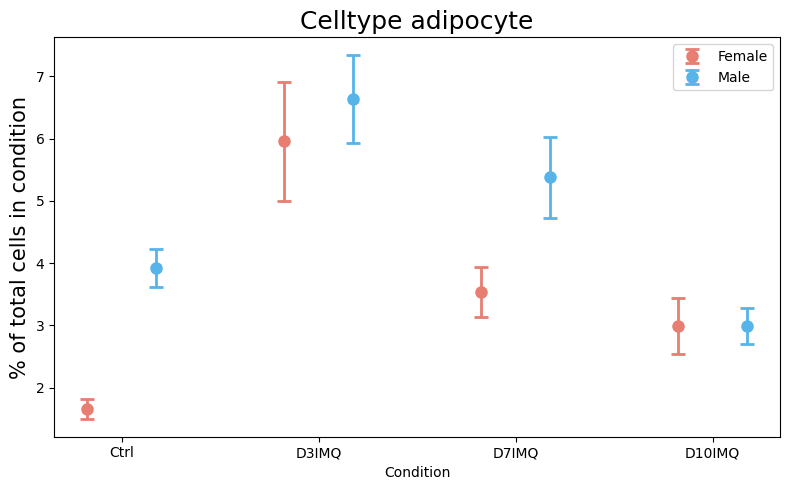

intermediate_basal_suprabasal_KC


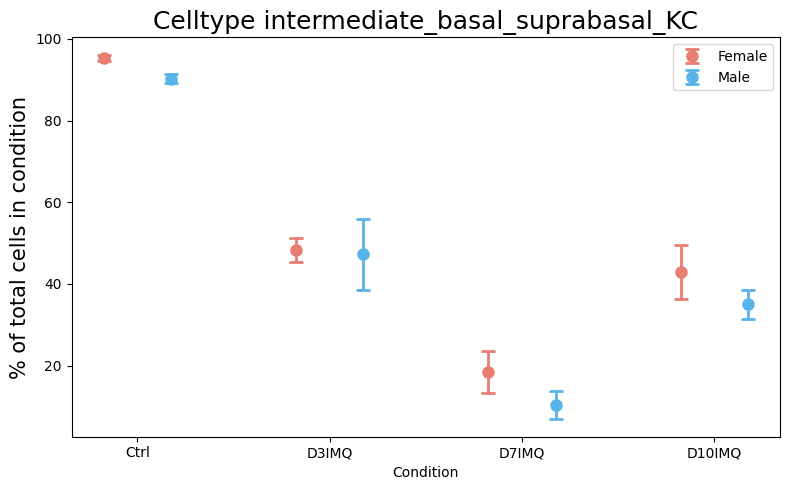

basal_KC


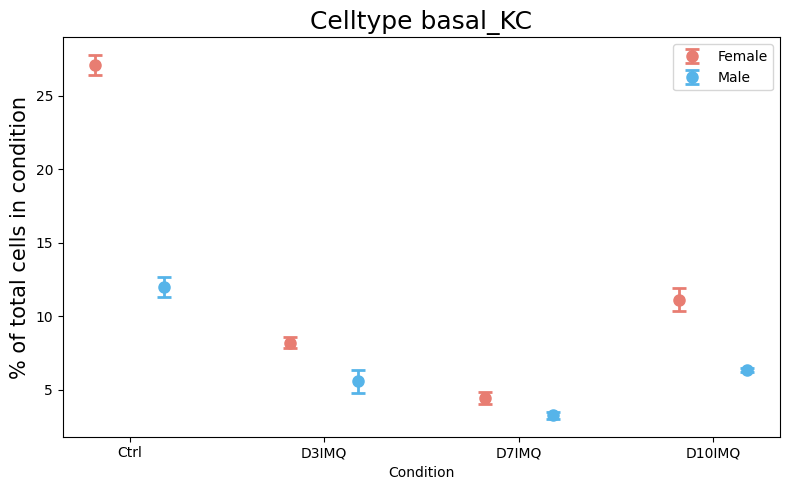

suprabasal_KC


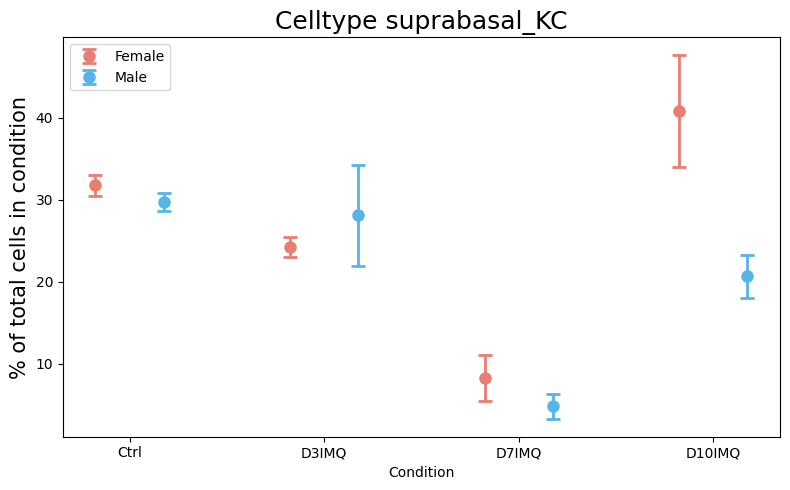

activated_suprabasal_KC


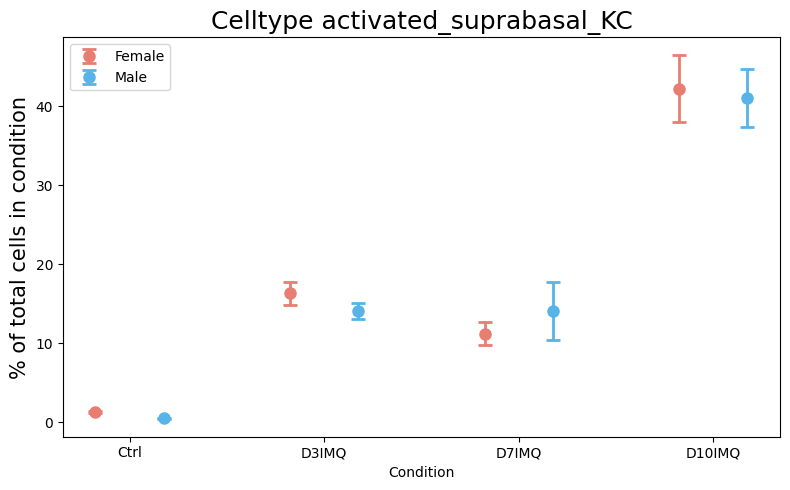

corneocyte


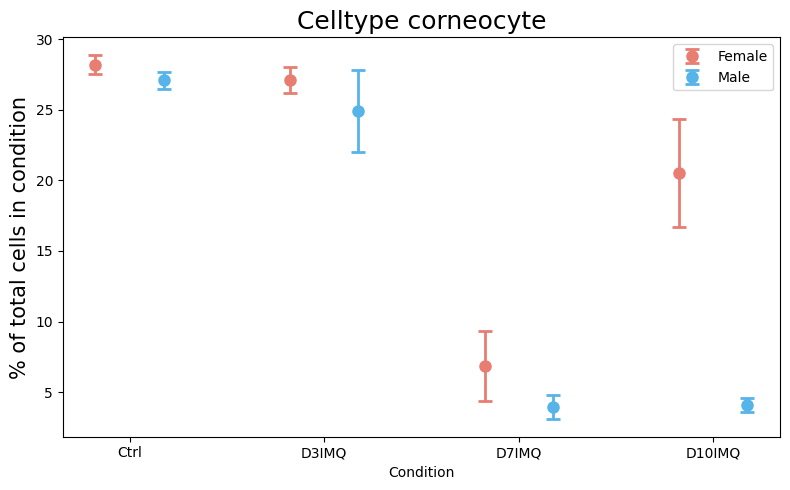

activated_corneocyte


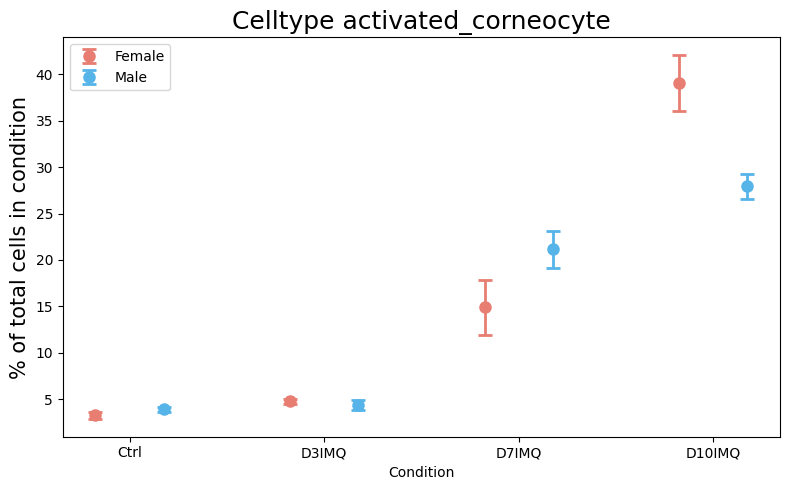

late_activated_suprabasal_KC


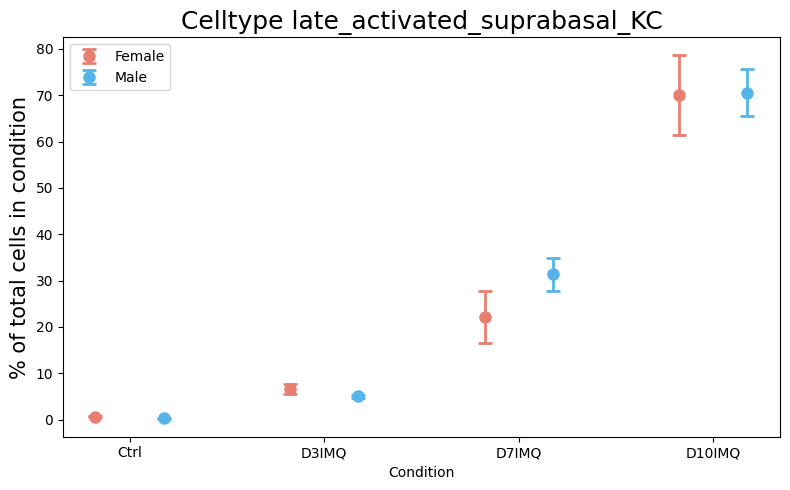

neutrophil


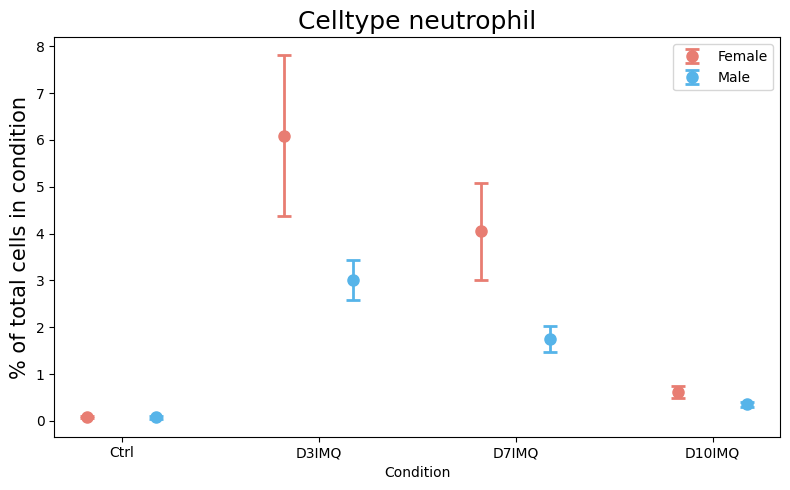

chondrocyte


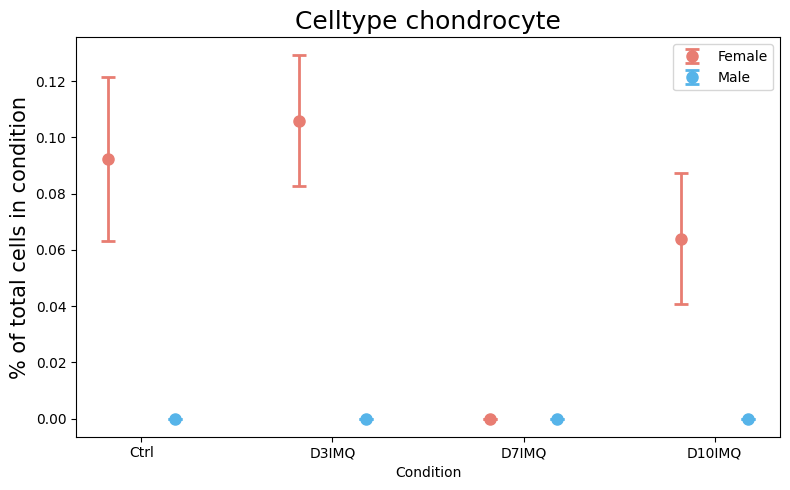

activated_intermediate_basal_suprabasal_KC


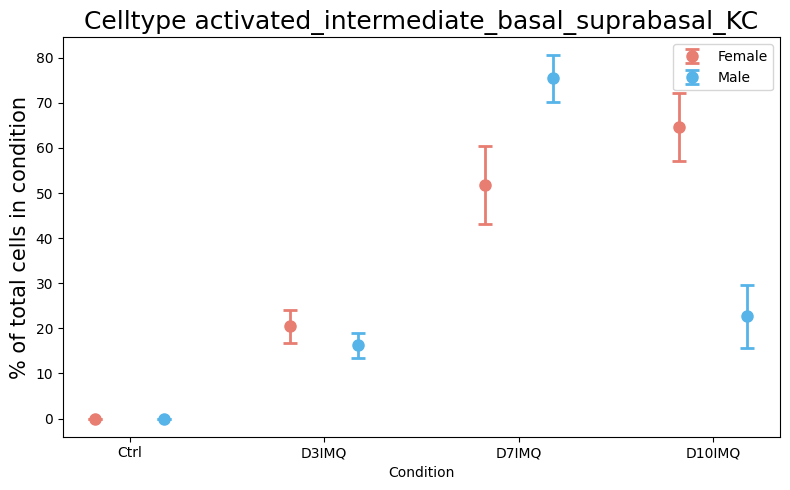

activated_spinous


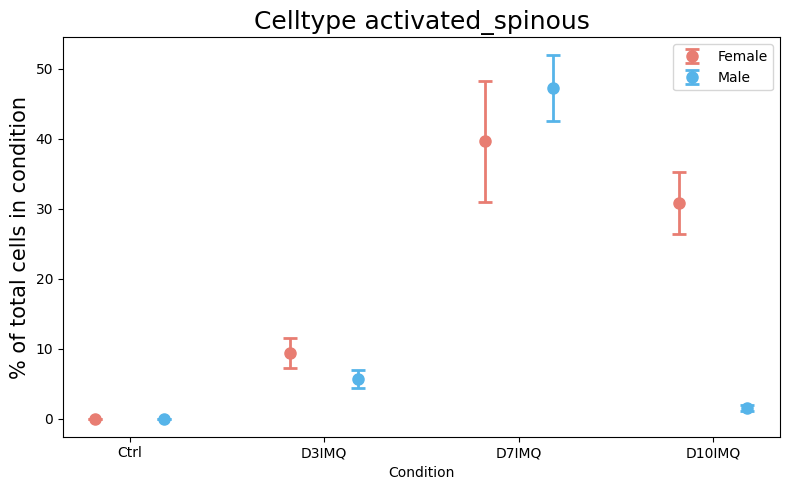

In [46]:
#normalised to cells in whatever is in 'normalisation_compartment'
#mean and error bar (std) version of above plot

import matplotlib.pyplot as plt
import pandas as pd
import math

condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

# Convert to string to avoid categorical dtype issues
bdata.obs['batch_key'] = bdata.obs['batch_key'].astype(str)
bdata.obs['celltype_assignments'] = bdata.obs['celltype_assignments'].astype(str)

batch_totals = cdata.obs['batch_key'].astype(str).value_counts() #KEY NORMALISATION STEP THAT DIFFERS FROM ABOVE FUNCTION

for cluster in bdata.obs['celltype_assignments'].unique():
    print(cluster)
    cluster_data = bdata[bdata.obs['celltype_assignments'] == cluster].copy()

    batch_counts = cluster_data.obs['batch_key'].value_counts()

    props = (batch_counts / batch_totals * 100).rename('proportion').reset_index()
    props.columns = ['batch_key', 'proportion']
    props['condition'] = props['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    props['sex'] = props['batch_key'].str.extract(r'_([FM])\d+$')

    all_batches = bdata.obs[['batch_key']].drop_duplicates().copy()
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex'] = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    # Convert all relevant columns to string before merge/fillna
    for df in [props, all_batches]:
        for col in ['batch_key', 'condition', 'sex']:
            df[col] = df[col].astype(str)

    props = all_batches.merge(props[['batch_key', 'proportion']], on='batch_key', how='left')
    props['proportion'] = props['proportion'].fillna(0)  # Only fillna on the numeric column

    fig, ax = plt.subplots(figsize=(8, 5))

    sex_colors = {'F': '#E87D72', 'M': '#56B4E9'}
    sex_labels = {'F': 'Female', 'M': 'Male'}
    width = 0.35
    x = range(len(condition_order))

    for sex, offset in {'F': -width/2, 'M': width/2}.items():
        sex_data = props[props['sex'] == sex]

        num_replicates = len(adata.obs.batch_key.unique())
        means = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].mean() for cond in condition_order]
        stds  = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].std()/math.sqrt(num_replicates)  for cond in condition_order]

        positions = [xi + offset for xi in x]

        ax.errorbar(
            positions, means, yerr=stds,
            fmt='o', color=sex_colors[sex],
            ecolor=sex_colors[sex], elinewidth=2,
            capsize=5, capthick=2,
            markersize=8, label=sex_labels[sex],
            zorder=3
        )

        # # Overlay individual points
        # for pos, cond in zip(positions, condition_order):
        #     vals = sex_data.loc[sex_data['condition'] == cond, 'proportion'].values
        #     ax.scatter(
        #         [pos] * len(vals), vals,
        #         color=sex_colors[sex], edgecolors='black',
        #         linewidths=0.5, zorder=5, s=30, alpha=0.6
        #     )

    ax.set_xticks(list(x))
    ax.set_xticklabels(condition_order)
    ax.set_title(f'Celltype {cluster}', fontsize=18)
    ax.set_xlabel('Condition')
    ax.set_ylabel('% of total cells in condition', fontsize=15)

    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=sex_colors[s], alpha=0.7, label=sex_labels[s]) for s in ['F', 'M']]
    ax.legend()

    plt.tight_layout()
    plt.show()

In [48]:
bdata.obs.celltype_assignments.unique()

array(['perichondral_fibroblast', 'dermal_fibroblast', 'smc', 'myeloid',
       'endothelial', 'follicle_cell', 'schwann_cell',
       'M2-like_macrophage', 'activated_basal_KC', 'mast_cell',
       'sebaceous_epithelial', 'adipocyte',
       'intermediate_basal_suprabasal_KC', 'basal_KC', 'suprabasal_KC',
       'activated_suprabasal_KC', 'corneocyte', 'activated_corneocyte',
       'late_activated_suprabasal_KC', 'neutrophil', 'chondrocyte',
       'activated_intermediate_basal_suprabasal_KC', 'activated_spinous'],
      dtype=object)

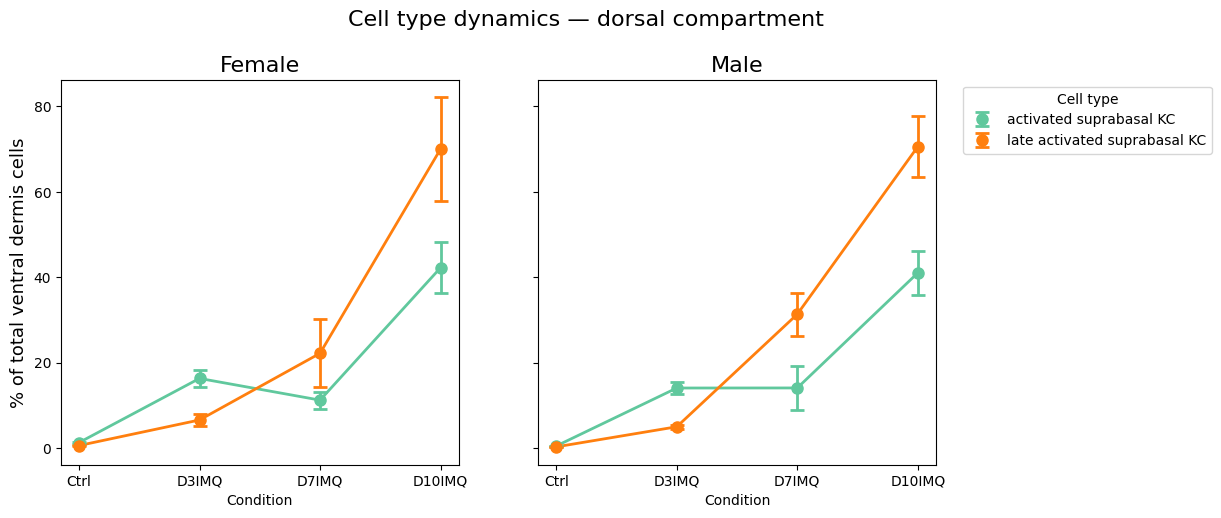

In [66]:
#visualising celltype dynamics, again, using the dorsal compartment and normalising to whatever is in normalisation compartment

import matplotlib.pyplot as plt
import pandas as pd
import math
import numpy as np

#clusters_to_plot = ['basal_KC', 'intermediate_basal_suprabasal_KC', 'suprabasal_KC', 'corneocyte']
#clusters_to_plot = ['activated_basal_KC', 'activated_intermediate_basal_suprabasal_KC', 'activated_suprabasal_KC', 'activated_corneocyte']
#clusters_to_plot = ['myeloid', 'neutrophil', 'M2-like_macrophage']
#clusters_to_plot = ['dermal_fibroblast', 'smc', 'schwann_cell', 'adipocyte']
clusters_to_plot = ['activated_suprabasal_KC', 'late_activated_suprabasal_KC']


condition_order  = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']


# Build colour map from AnnData
sorted_clusters = sorted(adata.obs['celltype_assignments'].unique())
color_map = dict(zip(sorted_clusters, adata.uns['celltype_assignments_colors']))

# Precompute normalisation denominators
bdata.obs['batch_key']            = bdata.obs['batch_key'].astype(str)
bdata.obs['celltype_assignments'] = bdata.obs['celltype_assignments'].astype(str)
batch_totals = cdata.obs['batch_key'].astype(str).value_counts()

all_batches = bdata.obs[['batch_key']].drop_duplicates().copy()
all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')
for col in ['batch_key', 'condition', 'sex']:
    all_batches[col] = all_batches[col].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sex_labels = {'F': 'Female', 'M': 'Male'}
x = np.arange(len(condition_order))

for cluster in clusters_to_plot:
    cluster_data = bdata[bdata.obs['celltype_assignments'] == cluster]
    batch_counts = cluster_data.obs['batch_key'].value_counts()

    props = (batch_counts / batch_totals * 100).rename('proportion').reset_index()
    props.columns = ['batch_key', 'proportion']
    for col in ['batch_key']:
        props[col] = props[col].astype(str)

    props = all_batches.merge(props[['batch_key', 'proportion']], on='batch_key', how='left')
    props['proportion'] = props['proportion'].fillna(0)

    color = color_map[cluster]

    for ax, (sex, sex_label) in zip(axes, sex_labels.items()):
        sex_data = props[props['sex'] == sex]

        num_replicates = len(sex_data['batch_key'].unique())

        means = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].mean()
                 for cond in condition_order]
        sems  = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].std()
                 / math.sqrt(num_replicates)
                 for cond in condition_order]

        ax.plot(x, means, color=color, linewidth=2, zorder=3)
        ax.errorbar(
            x, means, yerr=sems,
            fmt='o', color=color,
            ecolor=color, elinewidth=2,
            capsize=5, capthick=2,
            markersize=8, label=cluster.replace('_', ' '),
            zorder=4
        )

for ax, (sex, sex_label) in zip(axes, sex_labels.items()):
    ax.set_xticks(x)
    ax.set_xticklabels(condition_order)
    ax.set_title(sex_label, fontsize=16)
    ax.set_xlabel('Condition')

comp_label = normalisation_compartment.replace("_", " ")
axes[0].set_ylabel(f'% of total {comp_label} cells', fontsize=13)

axes[1].legend(title='Cell type', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.subplots_adjust(right=0.75)


plt.suptitle('Cell type dynamics — dorsal compartment', fontsize=16, y=1.02)
plt.show()

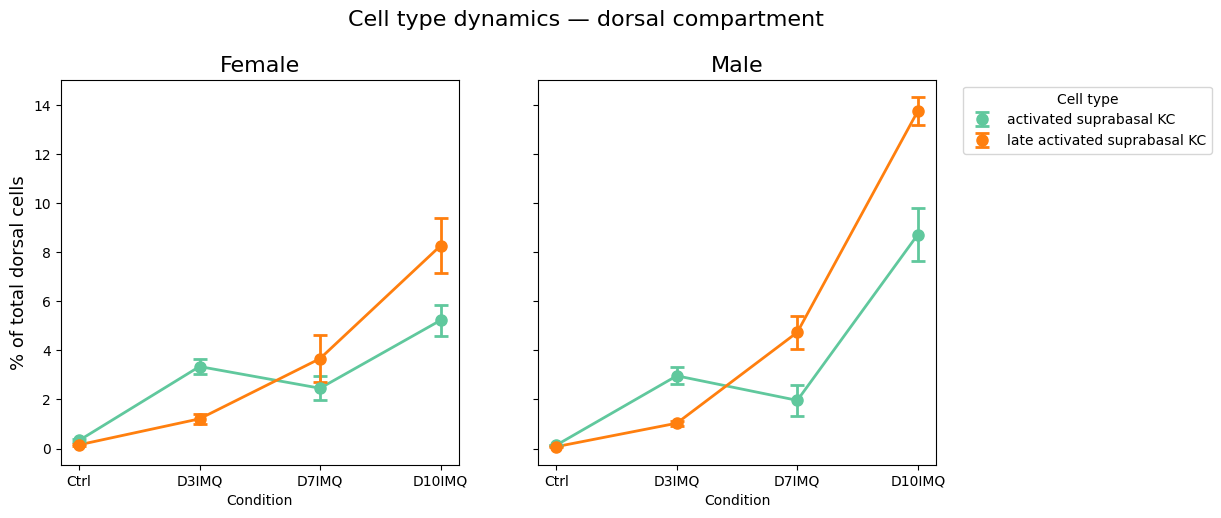

In [65]:
#visualising celltype dynamics, normalised to total cells in dorsal compartment

import matplotlib.pyplot as plt
import pandas as pd
import math
import numpy as np

#clusters_to_plot = ['basal_KC', 'intermediate_basal_suprabasal_KC', 'suprabasal_KC', 'corneocyte']
#clusters_to_plot = ['activated_basal_KC', 'activated_intermediate_basal_suprabasal_KC', 'activated_suprabasal_KC', 'activated_corneocyte']
#clusters_to_plot = ['myeloid', 'neutrophil', 'M2-like_macrophage']
#clusters_to_plot = ['dermal_fibroblast', 'smc', 'schwann_cell', 'adipocyte']
clusters_to_plot = ['activated_suprabasal_KC', 'late_activated_suprabasal_KC']

condition_order  = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']


# Build colour map from AnnData
sorted_clusters = sorted(adata.obs['celltype_assignments'].unique())
color_map = dict(zip(sorted_clusters, adata.uns['celltype_assignments_colors']))

# Precompute normalisation denominators
bdata.obs['batch_key']            = bdata.obs['batch_key'].astype(str)
bdata.obs['celltype_assignments'] = bdata.obs['celltype_assignments'].astype(str)
batch_totals = bdata.obs['batch_key'].value_counts()

all_batches = bdata.obs[['batch_key']].drop_duplicates().copy()
all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')
for col in ['batch_key', 'condition', 'sex']:
    all_batches[col] = all_batches[col].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sex_labels = {'F': 'Female', 'M': 'Male'}
x = np.arange(len(condition_order))

for cluster in clusters_to_plot:
    cluster_data = bdata[bdata.obs['celltype_assignments'] == cluster]
    batch_counts = cluster_data.obs['batch_key'].value_counts()

    props = (batch_counts / batch_totals * 100).rename('proportion').reset_index()
    props.columns = ['batch_key', 'proportion']
    for col in ['batch_key']:
        props[col] = props[col].astype(str)

    props = all_batches.merge(props[['batch_key', 'proportion']], on='batch_key', how='left')
    props['proportion'] = props['proportion'].fillna(0)

    color = color_map[cluster]

    for ax, (sex, sex_label) in zip(axes, sex_labels.items()):
        sex_data = props[props['sex'] == sex]

        num_replicates = len(sex_data['batch_key'].unique())

        means = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].mean()
                 for cond in condition_order]
        sems  = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].std()
                 / math.sqrt(num_replicates)
                 for cond in condition_order]

        ax.plot(x, means, color=color, linewidth=2, zorder=3)
        ax.errorbar(
            x, means, yerr=sems,
            fmt='o', color=color,
            ecolor=color, elinewidth=2,
            capsize=5, capthick=2,
            markersize=8, label=cluster.replace('_', ' '),
            zorder=4
        )

for ax, (sex, sex_label) in zip(axes, sex_labels.items()):
    ax.set_xticks(x)
    ax.set_xticklabels(condition_order)
    ax.set_title(sex_label, fontsize=16)
    ax.set_xlabel('Condition')

comp_label = 'dorsal'
axes[0].set_ylabel(f'% of total {comp_label} cells', fontsize=13)

axes[1].legend(title='Cell type', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.subplots_adjust(right=0.75)


plt.suptitle('Cell type dynamics — dorsal compartment', fontsize=16, y=1.02)
plt.show()

# Normalising using surface area (cell density)

In [69]:
import scanpy as sc 
adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters_withraw.h5ad")
adata = adata[adata.obs.compartment.str.contains('orsal')]
adata

View of AnnData object with n_obs × n_vars = 162096 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'compartment', 'shape_index', 'solidity', 'replicate', 'condition', 'batch_key', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden', 'highlight', 'leiden_0.5', 'leiden_0.65', 'leiden_0.75', 'leiden_0.85', 'leiden_1.0', 'mac_subcluster', '3_subcluster', 'celltype_assignments', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter', 'sex'
    uns: '3_subcluster', '3_subclust

## celltype - compartment - single plots

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_cell_density(adata, celltype, compartment, condition_order=None):
    """
    Plot cell density (cells per µm²) for a given celltype, normalised
    to the surface area of the specified compartment.

    Parameters
    ----------
    adata : AnnData
        AnnData object containing dorsal cells.
    celltype : str
        Value in adata.obs['celltype_assignments'] to plot.
    compartment : str
        Key in adata.uns['region_surface_areas_um2'][replicate] to use
        as the area denominator (e.g. 'dorsal_dermis', 'dorsal_epidermis').
    condition_order : list, optional
        Order of conditions on x-axis. Defaults to sorted unique conditions.
    """

    if condition_order is None:
        condition_order = sorted(adata.obs['batch_key'].astype(str).unique())

    # ── Surface area lookup ───────────────────────────────────────────────────
    surface_areas = {
        batch: regions[compartment]
        for batch, regions in adata.uns['region_surface_areas_um2'].items()
        if compartment in regions
    }

    # ── Cell counts per replicate ─────────────────────────────────────────────
    adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)
    adata.obs['celltype_assignments'] = adata.obs['celltype_assignments'].astype(str)

    cluster_data = adata[adata.obs['celltype_assignments'] == celltype]
    batch_counts = cluster_data.obs['batch_key'].value_counts()

    # ── Build per-replicate dataframe ─────────────────────────────────────────
    all_batches = (
        adata.obs[['batch_key']]
        .drop_duplicates()
        .copy()
        .astype(str)
    )
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')
    all_batches['count']     = all_batches['batch_key'].map(batch_counts).fillna(0)
    all_batches['area_um2']  = all_batches['batch_key'].map(surface_areas)
    all_batches['density']   = all_batches['count'] / all_batches['area_um2'] *100

    missing = all_batches['area_um2'].isna().sum()
    if missing:
        print(f"Warning: {missing} replicate(s) have no area data for '{compartment}' and will be dropped.")
        all_batches = all_batches.dropna(subset=['area_um2'])

    # ── Plot ──────────────────────────────────────────────────────────────────
    sex_colors = {'F': 'darkred', 'M': '#002147'}
    sex_labels = {'F': 'Female',  'M': 'Male'}
    width = 0.35
    x = range(len(condition_order))

    fig, ax = plt.subplots(figsize=(8, 5))

    for sex, offset in {'F': -width / 2, 'M': width / 2}.items():
        sex_data = all_batches[all_batches['sex'] == sex]

        box_data = [
            sex_data.loc[sex_data['condition'] == cond, 'density'].values
            for cond in condition_order
        ]
        positions = [xi + offset for xi in x]

        ax.boxplot(
            box_data,
            positions=positions,
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            boxprops=dict(facecolor=sex_colors[sex], alpha=0.7),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color=sex_colors[sex]),
            capprops=dict(color=sex_colors[sex]),
            flierprops=dict(marker='o', color=sex_colors[sex], alpha=0.5),
        )

        for pos, vals in zip(positions, box_data):
            ax.scatter(
                [pos] * len(vals), vals,
                color=sex_colors[sex], edgecolors='black',
                linewidths=0.5, zorder=5, s=40, alpha=0.8,
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(condition_order)
    ax.set_title(f'{celltype.replace("_", " ")}  |  normalised to {compartment.replace("_", " ")}', fontsize=16)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Cells per 100 µm²', fontsize=13)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=sex_colors[s], alpha=0.7, label=sex_labels[s])
        for s in ['F', 'M']
    ]
    ax.legend(handles=handles)
    plt.tight_layout()
    plt.show()

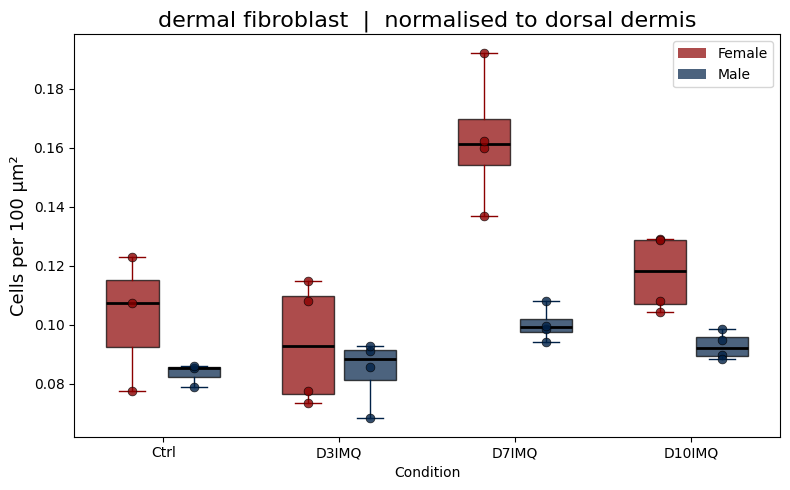

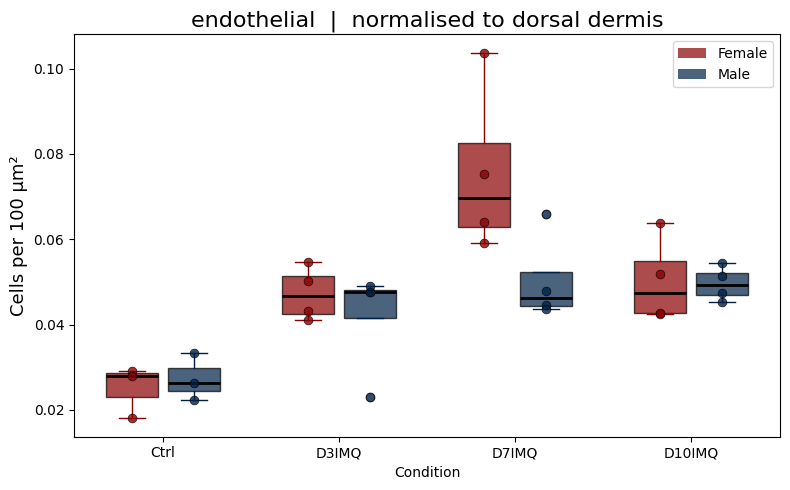

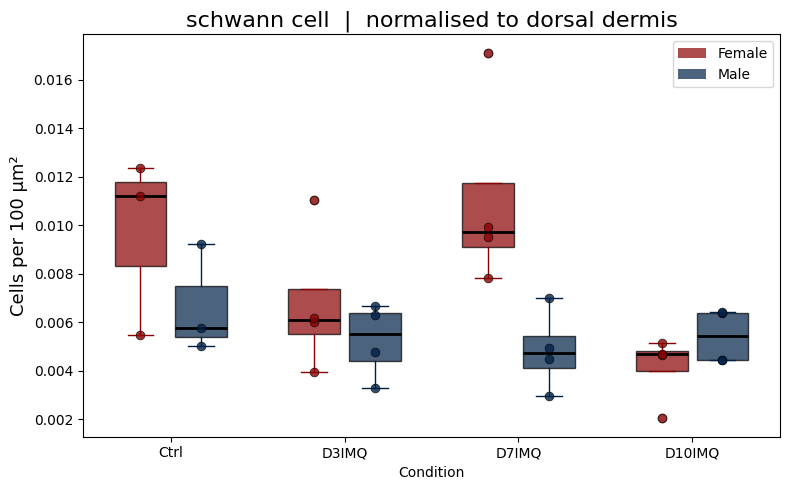

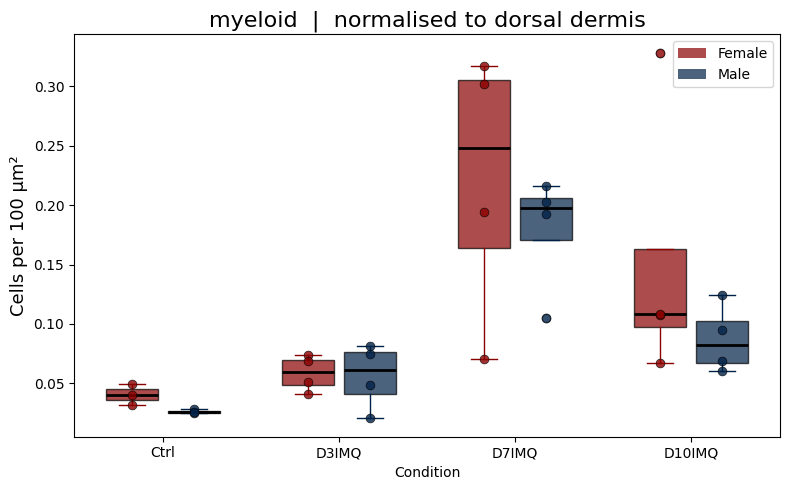

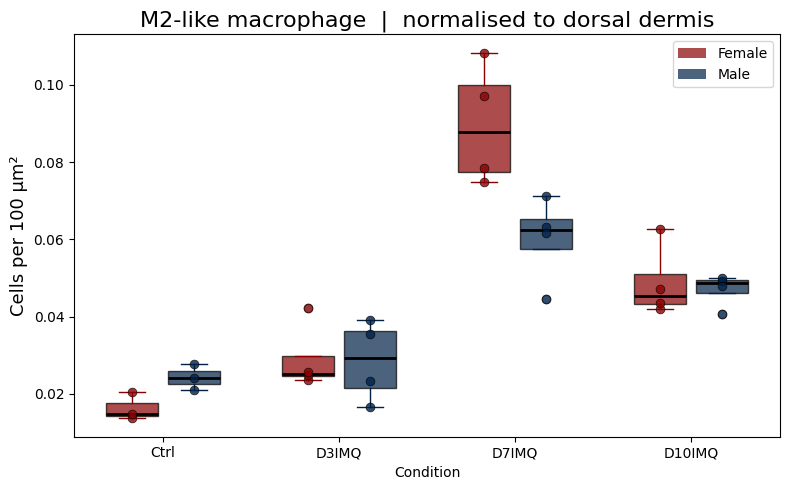

In [18]:
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

for celltype in ['dermal_fibroblast', 'endothelial', 'schwann_cell', 'myeloid', 'M2-like_macrophage']:
    plot_cell_density(adata, celltype, 'dorsal_dermis', condition_order=condition_order)

## multiple cell types on one graph - proportions

In [80]:
def plot_grouped_proportions(adata, celltypes, compartment, condition_order=None):

    # ── Colour mapping - before filtering ────────────────────────────────────────────────────────
    categories = list(adata.obs['celltype_assignments'].astype('category').cat.categories)
    colors = adata.uns['celltype_assignments_colors']
    color_map = dict(zip(categories, colors))
    adata = adata[adata.obs['compartment'] == compartment]

    if condition_order is None:
        condition_order = sorted(adata.obs['batch_key'].astype(str).unique())

    adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)
    adata.obs['celltype_assignments'] = adata.obs['celltype_assignments'].astype(str)



    # ── Build per-replicate proportions for each celltype ─────────────────────
    batch_totals = adata.obs['batch_key'].value_counts()

    all_batches = adata.obs[['batch_key']].drop_duplicates().copy().astype(str)
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    for ct in celltypes:
        ct_counts = (
            adata[adata.obs['celltype_assignments'] == ct]
            .obs['batch_key'].value_counts()
        )
        all_batches[ct] = all_batches['batch_key'].map(ct_counts).fillna(0)
        all_batches[ct] = all_batches[ct] / all_batches['batch_key'].map(batch_totals) * 100

    # ── Plot ──────────────────────────────────────────────────────────────────
    sexes      = ['F', 'M']
    sex_labels = {'F': 'Female', 'M': 'Male'}

    n_conditions = len(condition_order)
    n_celltypes  = len(celltypes)
    bar_width    = 0.8 / n_celltypes
    x            = range(n_conditions)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, sex in zip(axes, sexes):
        sex_data = all_batches[all_batches['sex'] == sex]

        for i, ct in enumerate(celltypes):
            offsets = [(xi - 0.4 + i * bar_width + bar_width / 2) for xi in x]
            means   = [sex_data.loc[sex_data['condition'] == cond, ct].mean() for cond in condition_order]
            sems    = [sex_data.loc[sex_data['condition'] == cond, ct].sem()  for cond in condition_order]

            ax.bar(
                offsets, means, width=bar_width * 0.9,
                color=color_map[ct], alpha=0.85,
                yerr=sems, error_kw=dict(ecolor='black', capsize=3, linewidth=1)
            )

            for j, cond in enumerate(condition_order):
                vals = sex_data.loc[sex_data['condition'] == cond, ct].values
                ax.scatter(
                    [offsets[j]] * len(vals), vals,
                    color=color_map[ct], edgecolors='black',
                    linewidths=0.5, zorder=5, s=30, alpha=0.9
                )

        ax.set_xticks(list(x))
        ax.set_xticklabels(condition_order)
        ax.set_title(sex_labels[sex], fontsize=14)
        ax.set_xlabel('Condition')

    axes[0].set_ylabel(f'% of total {compartment.replace("_", " ")} cells', fontsize=12)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=color_map[ct], alpha=0.85, label=ct.replace('_', ' '))
        for ct in celltypes
    ]
    fig.legend(
        handles=handles,
        loc='upper left',
        bbox_to_anchor=(1.001, 0.84),
        bbox_transform=fig.transFigure,
        frameon=True,
        fancybox=False,
        edgecolor='black',
        fontsize=10,
    )
    fig.suptitle(f'Cell type proportions  |  {compartment.replace("_", " ")}', fontsize=16, y=1.02)

    plt.tight_layout()
    plt.show()

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_40448\1931646838.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)


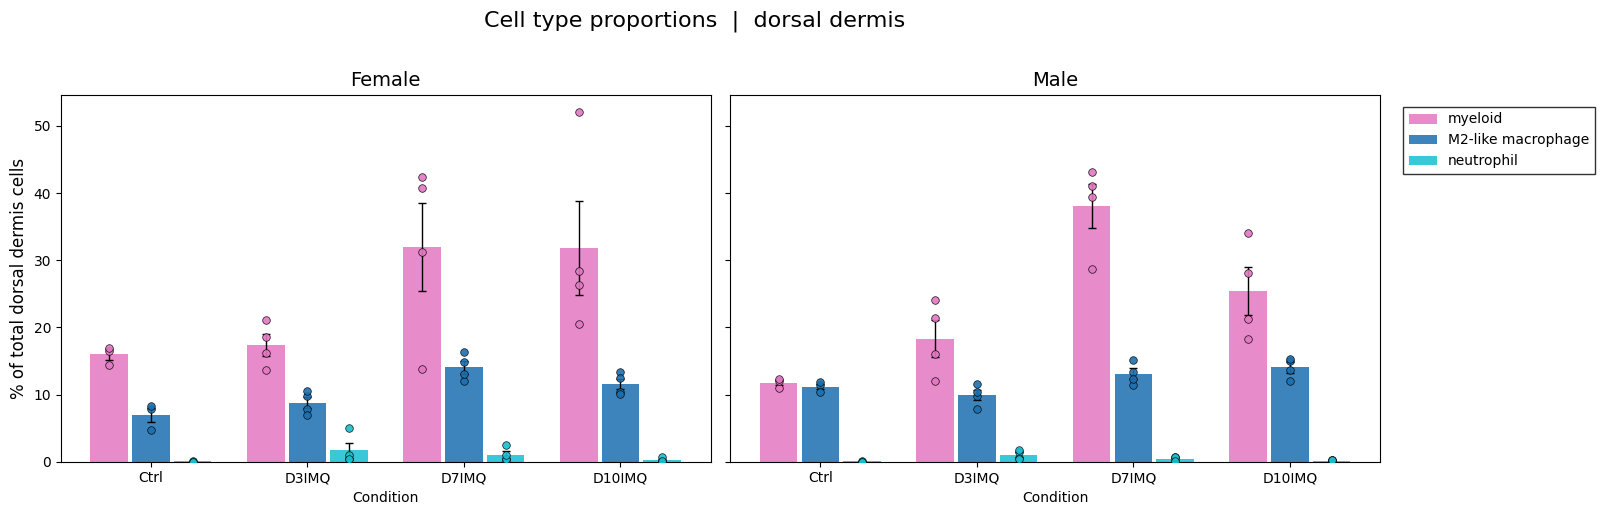

In [41]:
celltypes = ['myeloid', 'M2-like_macrophage', 'neutrophil']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_proportions(adata, celltypes, compartment='dorsal_dermis', condition_order=condition_order)

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_40448\1931646838.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)


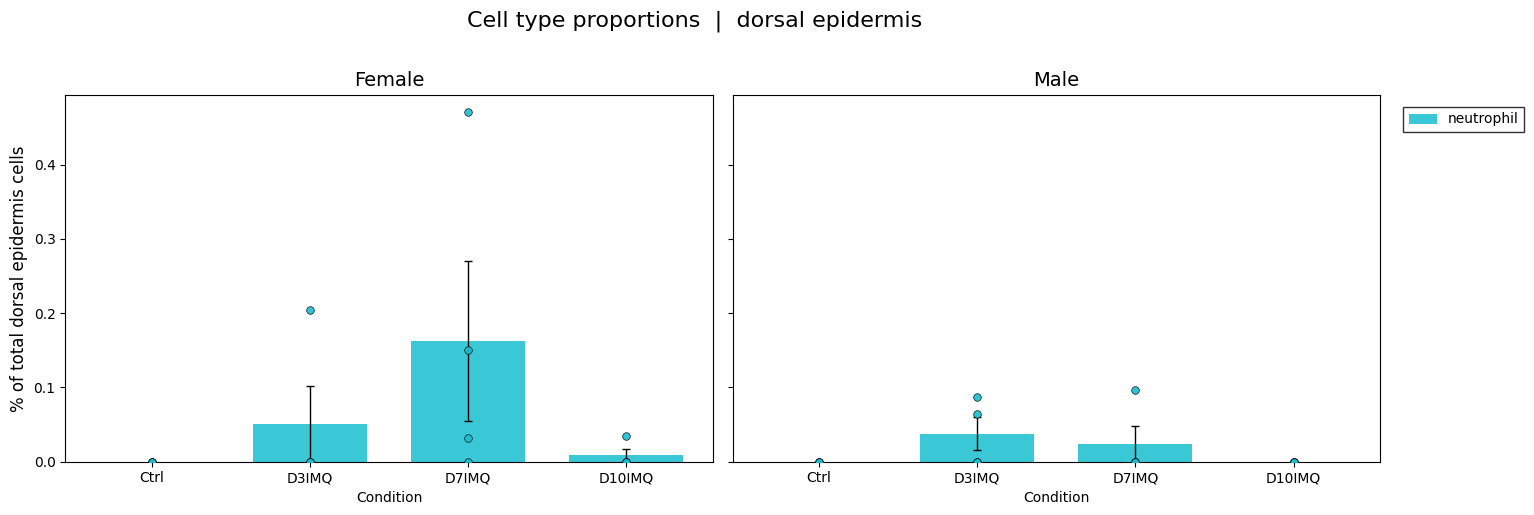

In [44]:
celltypes = ['neutrophil']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_proportions(adata, celltypes, 'dorsal_epidermis', condition_order=condition_order)

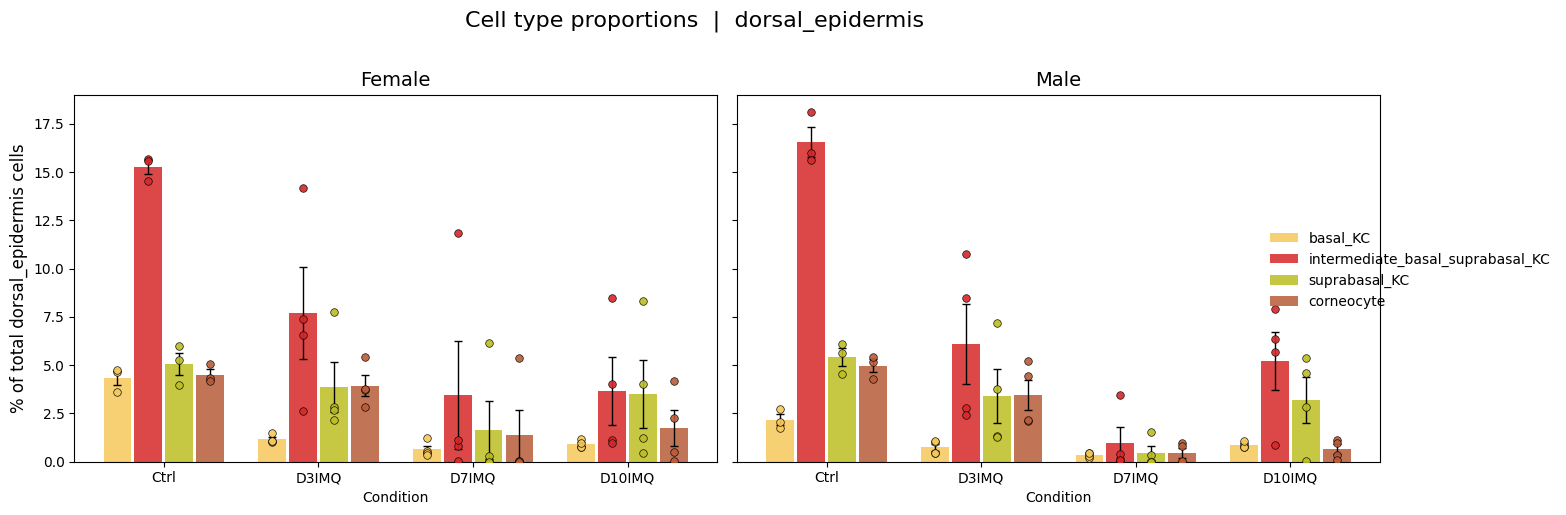

In [27]:
celltypes = ['basal_KC', 'intermediate_basal_suprabasal_KC', 'suprabasal_KC', 'corneocyte']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_proportions(adata, celltypes, compartment, condition_order=condition_order)

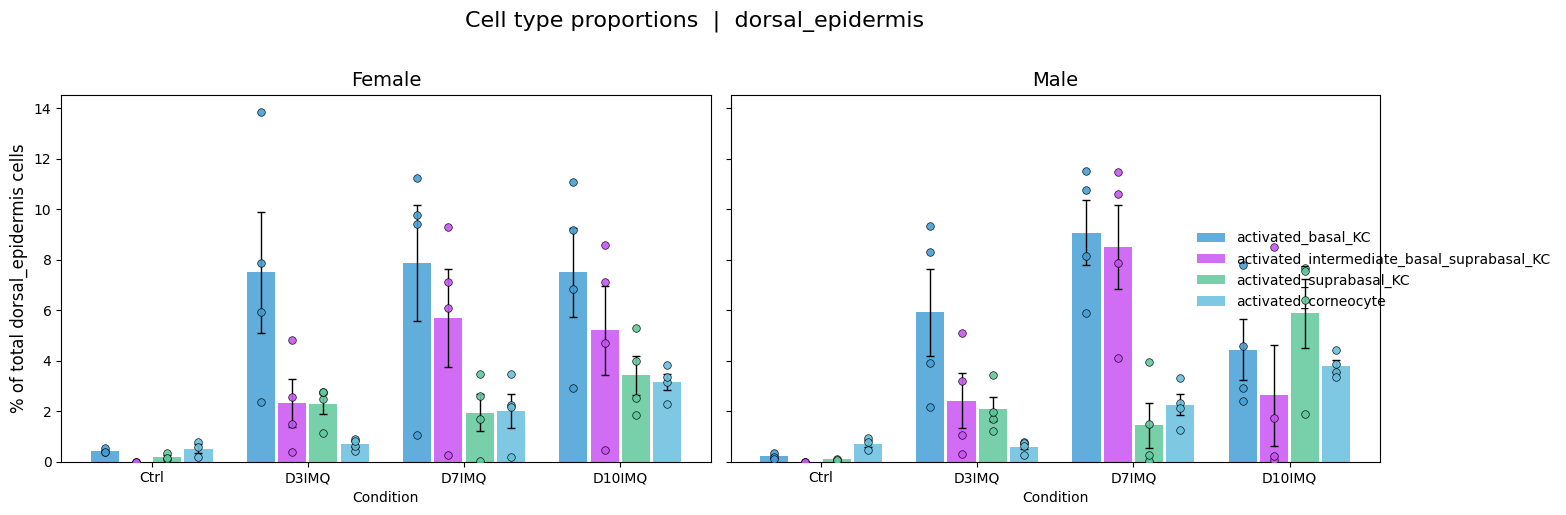

: 

In [ ]:
celltypes = ['activated_basal_KC', 'activated_intermediate_basal_suprabasal_KC', 'activated_suprabasal_KC', 'activated_corneocyte']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_proportions(adata, celltypes, compartment, condition_order=condition_order)

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_40448\1931646838.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)


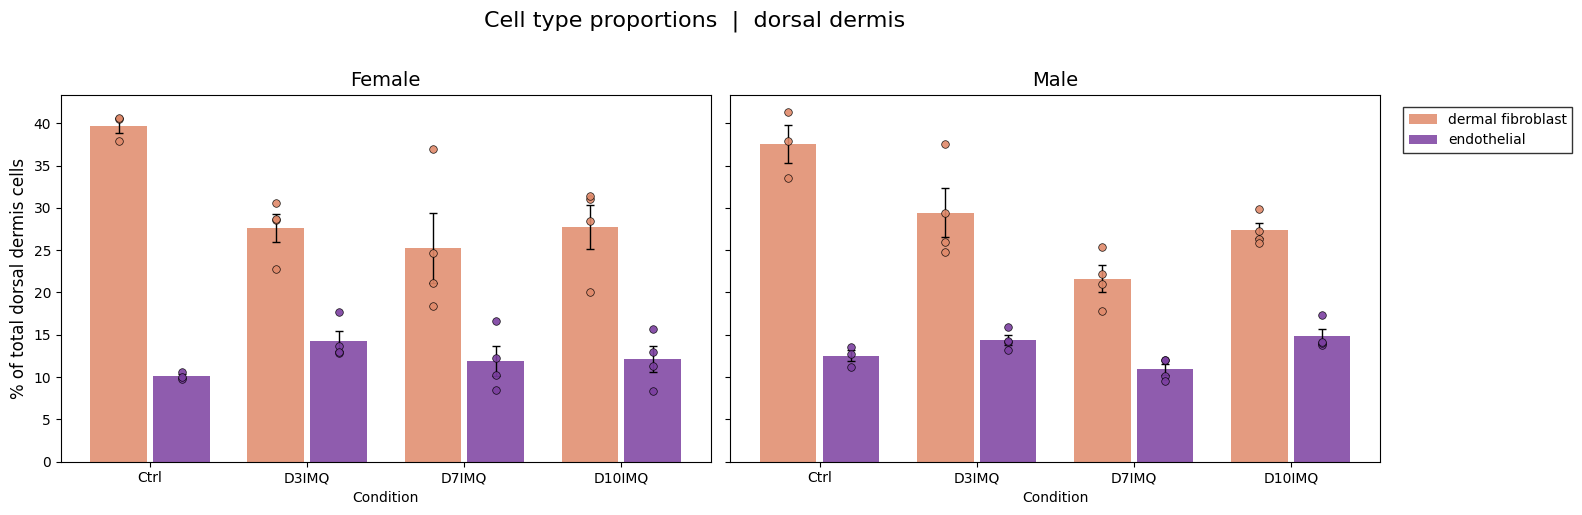

In [83]:
celltypes = ['dermal_fibroblast', 'endothelial']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_proportions(adata, celltypes, 'dorsal_dermis', condition_order=condition_order)

## multiple cell types on one graph - density (Surface area normalisation)

In [74]:
def plot_grouped_densities(adata, celltypes, compartment, condition_order=None):

    # ── Colour mapping - before filtering ────────────────────────────────────
    categories = list(adata.obs['celltype_assignments'].astype('category').cat.categories)
    colors     = adata.uns['celltype_assignments_colors']
    color_map  = dict(zip(categories, colors))

    adata = adata[adata.obs['compartment'] == compartment]

    if condition_order is None:
        condition_order = sorted(adata.obs['batch_key'].astype(str).unique())

    adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)
    adata.obs['celltype_assignments']  = adata.obs['celltype_assignments'].astype(str)

    # ── Surface area lookup ───────────────────────────────────────────────────
    surface_areas = {
        batch: regions[compartment]
        for batch, regions in adata.uns['region_surface_areas_um2'].items()
        if compartment in regions
    }

    # ── Build per-replicate densities for each celltype ───────────────────────
    all_batches = adata.obs[['batch_key']].drop_duplicates().copy().astype(str)
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')
    all_batches['area_um2']  = all_batches['batch_key'].map(surface_areas)

    missing = all_batches['area_um2'].isna().sum()
    if missing:
        print(f"Warning: {missing} replicate(s) missing area data for '{compartment}' and will be dropped.")
        all_batches = all_batches.dropna(subset=['area_um2'])

    for ct in celltypes:
        ct_counts = (
            adata[adata.obs['celltype_assignments'] == ct]
            .obs['batch_key'].value_counts()
        )
        all_batches[ct] = all_batches['batch_key'].map(ct_counts).fillna(0)
        all_batches[ct] = (all_batches[ct] / all_batches['area_um2']) * 100

    # ── Plot ──────────────────────────────────────────────────────────────────
    sexes      = ['F', 'M']
    sex_labels = {'F': 'Female', 'M': 'Male'}

    n_conditions = len(condition_order)
    n_celltypes  = len(celltypes)
    bar_width    = 0.8 / n_celltypes
    x            = range(n_conditions)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, sex in zip(axes, sexes):
        sex_data = all_batches[all_batches['sex'] == sex]

        for i, ct in enumerate(celltypes):
            offsets = [(xi - 0.4 + i * bar_width + bar_width / 2) for xi in x]
            means   = [sex_data.loc[sex_data['condition'] == cond, ct].mean() for cond in condition_order]
            sems    = [sex_data.loc[sex_data['condition'] == cond, ct].sem()  for cond in condition_order]

            ax.bar(
                offsets, means, width=bar_width * 0.9,
                color=color_map[ct], alpha=0.85,
                yerr=sems, error_kw=dict(ecolor='black', capsize=3, linewidth=1)
            )

            for j, cond in enumerate(condition_order):
                vals = sex_data.loc[sex_data['condition'] == cond, ct].values
                ax.scatter(
                    [offsets[j]] * len(vals), vals,
                    color=color_map[ct], edgecolors='black',
                    linewidths=0.5, zorder=5, s=30, alpha=0.9
                )

        ax.set_xticks(list(x))
        ax.set_xticklabels(condition_order)
        ax.set_title(sex_labels[sex], fontsize=14)
        ax.set_xlabel('Condition')

    axes[0].set_ylabel(f'Cells per 100 µm²  |  {compartment.replace("_", " ")}', fontsize=12)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=color_map[ct], alpha=0.85, label=ct.replace('_', ' '))
        for ct in celltypes
    ]
    fig.legend(
        handles=handles,
        loc='upper left',
        bbox_to_anchor=(1.001, 0.84),
        bbox_transform=fig.transFigure,
        frameon=True,
        fancybox=False,
        edgecolor='black',
        fontsize=10,
    )
    fig.suptitle(f'Cell type densities  |  {compartment.replace("_", " ")}', fontsize=16, y=1.02)

    plt.tight_layout()
    plt.show()

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_40448\1189259181.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)


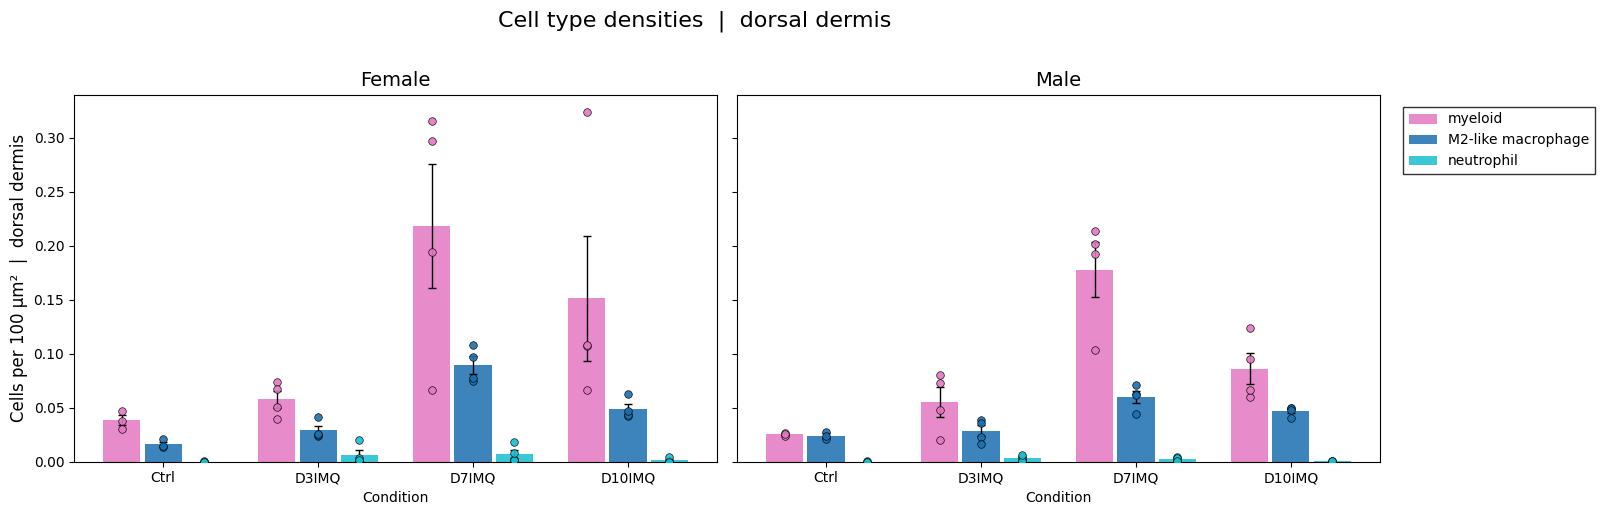

In [64]:
celltypes = ['myeloid', 'M2-like_macrophage', 'neutrophil']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_densities(adata, celltypes, 'dorsal_dermis', condition_order=condition_order)

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_40448\1189259181.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)


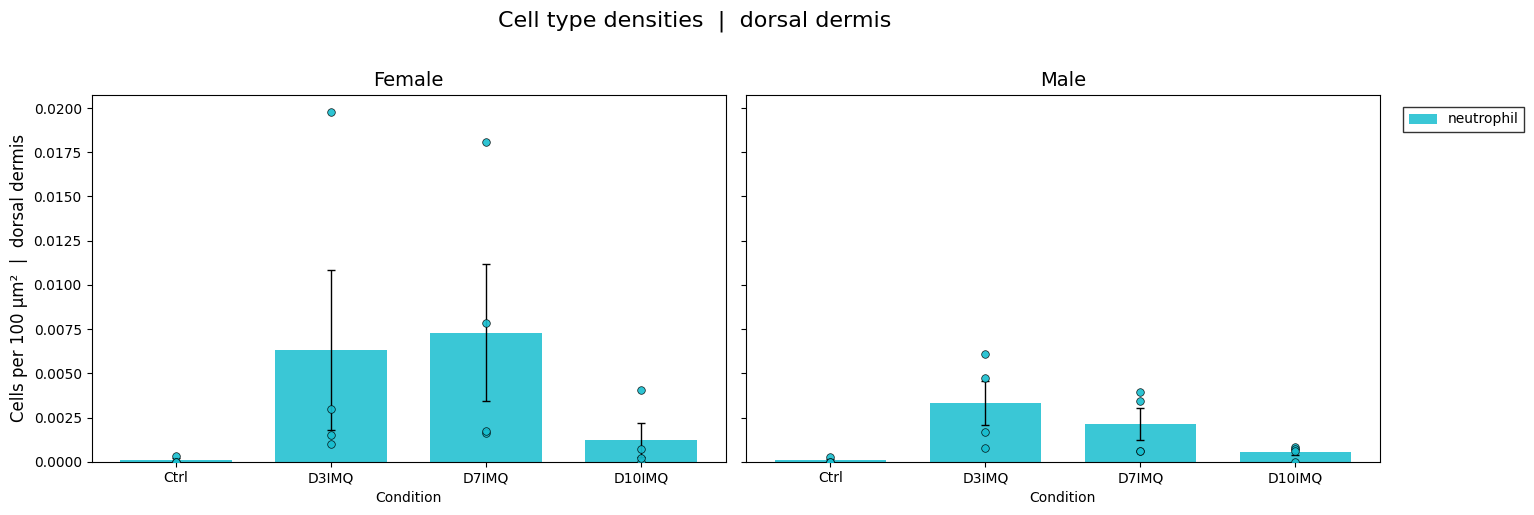

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_40448\1189259181.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)


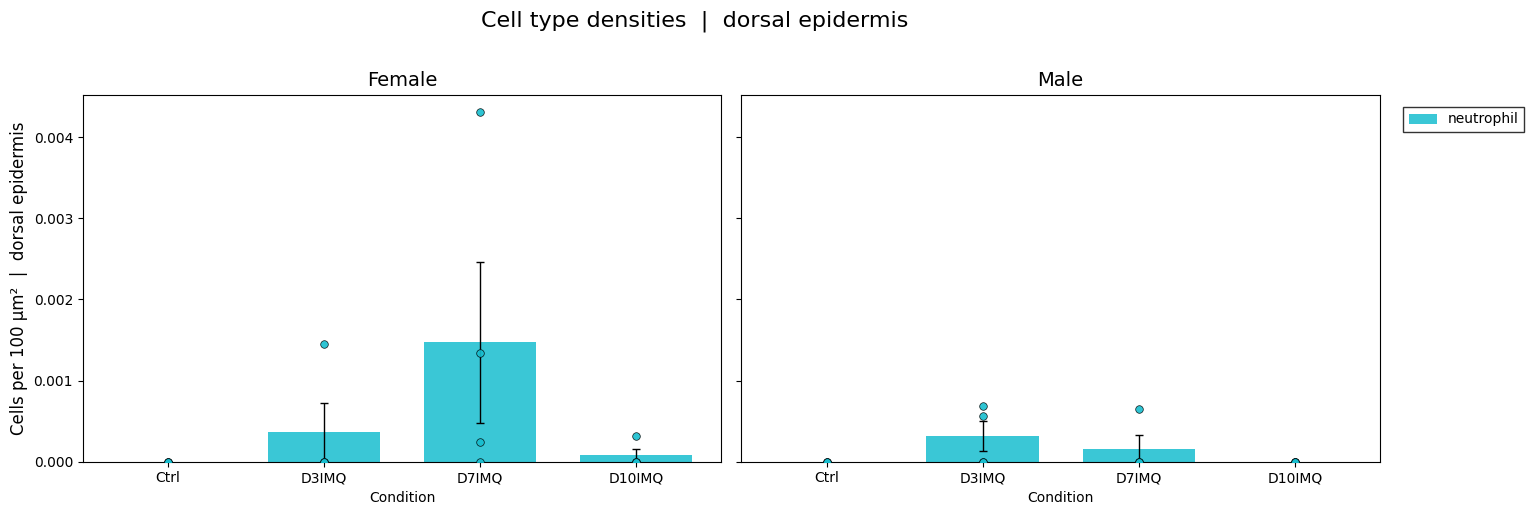

In [47]:
celltypes = ['neutrophil']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_densities(adata, celltypes, 'dorsal_dermis', condition_order=condition_order)
plot_grouped_densities(adata, celltypes, 'dorsal_epidermis', condition_order=condition_order)

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_40448\1189259181.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)


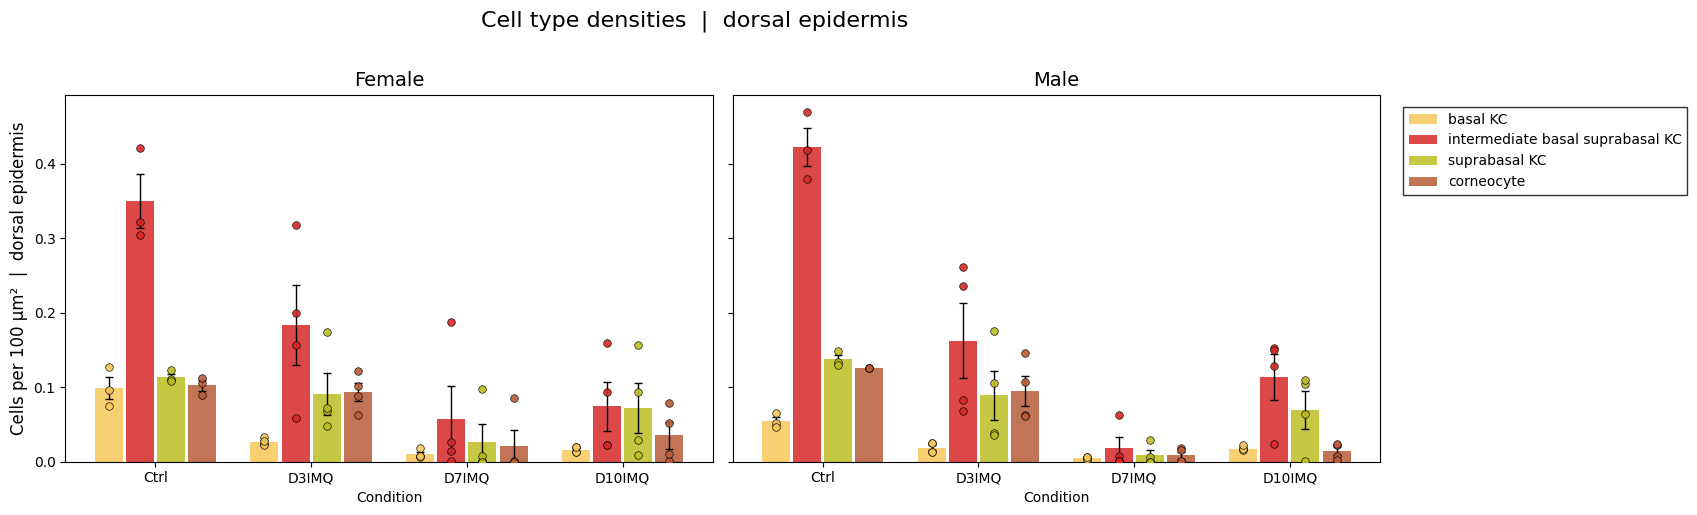

In [66]:
celltypes = ['basal_KC', 'intermediate_basal_suprabasal_KC', 'suprabasal_KC', 'corneocyte']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_densities(adata, celltypes, 'dorsal_epidermis', condition_order=condition_order)

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_40448\1189259181.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)


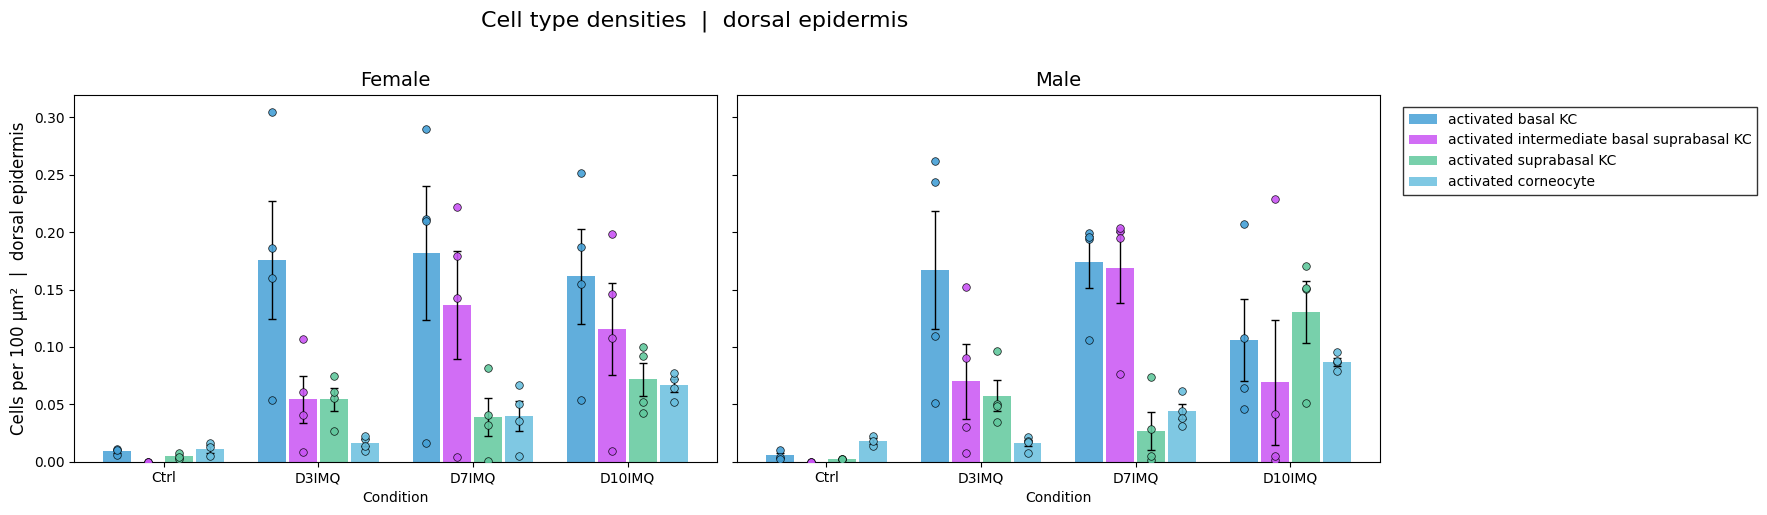

In [61]:
celltypes = ['activated_basal_KC', 'activated_intermediate_basal_suprabasal_KC', 'activated_suprabasal_KC', 'activated_corneocyte']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_densities(adata, celltypes, 'dorsal_epidermis', condition_order=condition_order)

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_40448\1189259181.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)


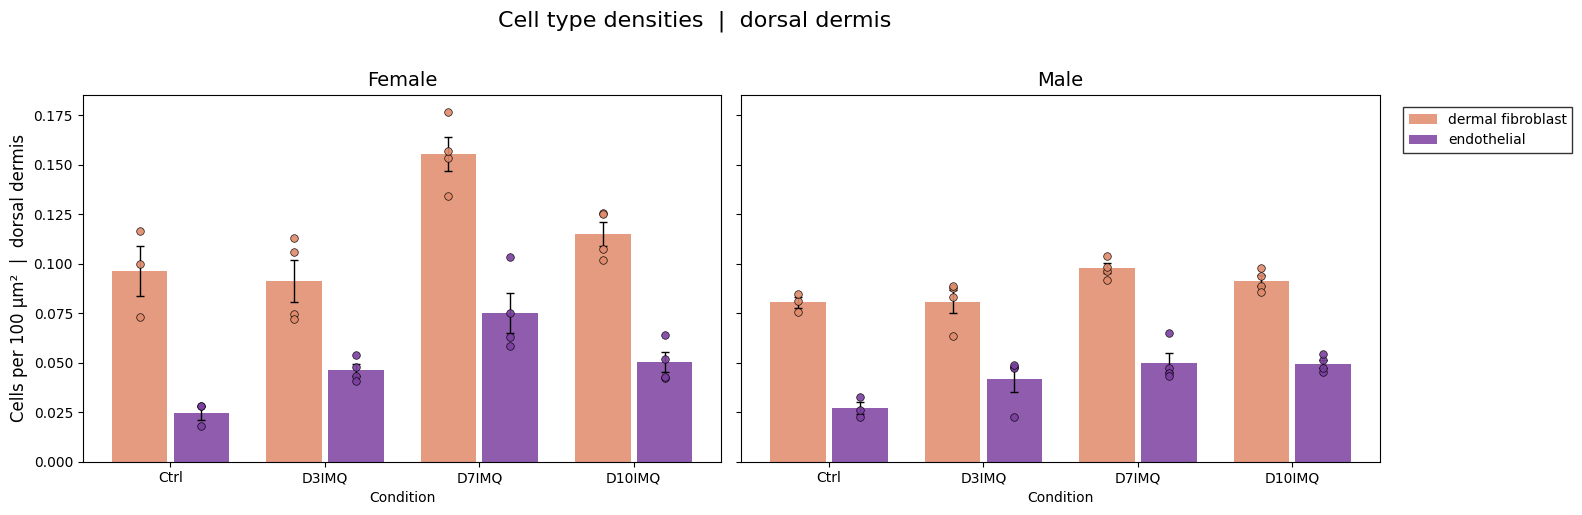

In [78]:
celltypes = ['dermal_fibroblast', 'endothelial']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_densities(adata, celltypes, 'dorsal_dermis', condition_order=condition_order)

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_40448\1189259181.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key']             = adata.obs['batch_key'].astype(str)


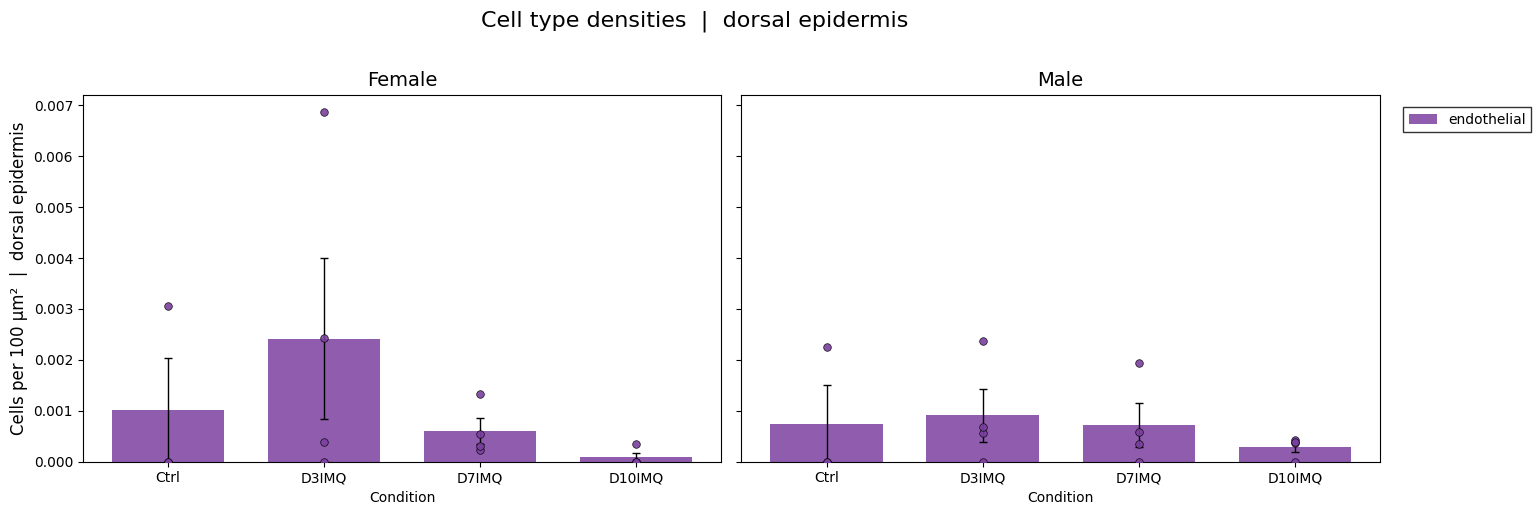

In [79]:
celltypes = ['endothelial']
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

plot_grouped_densities(adata, celltypes, 'dorsal_epidermis', condition_order=condition_order)

## Basal cell proportions

### grouped barplot

In [67]:
def plot_grouped_proportions(adata, celltypes, condition_order=None):

    # ── Colour mapping - before filtering ────────────────────────────────────
    categories = list(adata.obs['celltype_assignments'].astype('category').cat.categories)
    colors     = adata.uns['celltype_assignments_colors']
    color_map  = dict(zip(categories, colors))

    # Ensure types are string for clean matching/regex extraction
    adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)
    adata.obs['celltype_assignments'] = adata.obs['celltype_assignments'].astype(str)

    # If no order is given, dynamically extract unique base conditions from batch keys
    if condition_order is None:
        extracted_conds = adata.obs['batch_key'].str.extract(r'^(.+)_[FM]\d+$')[0]
        condition_order = sorted(extracted_conds.dropna().unique())

    # ── Build per-replicate data structure ───────────────────────────────────
    all_batches = adata.obs[['batch_key']].drop_duplicates().copy()
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    # 1. Grab raw counts for each targeted cell type per replicate
    for ct in celltypes:
        ct_counts = (
            adata[adata.obs['celltype_assignments'] == ct]
            .obs['batch_key'].value_counts()
        )
        all_batches[ct] = all_batches['batch_key'].map(ct_counts).fillna(0)

    # 2. Calculate the denominator (sum of ONLY the selected cell types)
    all_batches['total_selected_counts'] = all_batches[celltypes].sum(axis=1)

    # 3. Compute relative proportions (fraction between 0 and 1)
    for ct in celltypes:
        # fillna(0) handles rare edge-case replicates that might have 0 counts for all selected cell types
        all_batches[ct] = (all_batches[ct] / all_batches['total_selected_counts']).fillna(0)

    # ── Plot ──────────────────────────────────────────────────────────────────
    sexes      = ['F', 'M']
    sex_labels = {'F': 'Female', 'M': 'Male'}

    n_conditions = len(condition_order)
    n_celltypes  = len(celltypes)
    bar_width    = 0.8 / n_celltypes
    x            = range(n_conditions)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, sex in zip(axes, sexes):
        sex_data = all_batches[all_batches['sex'] == sex]

        for i, ct in enumerate(celltypes):
            offsets = [(xi - 0.4 + i * bar_width + bar_width / 2) for xi in x]
            means   = [sex_data.loc[sex_data['condition'] == cond, ct].mean() for cond in condition_order]
            sems    = [sex_data.loc[sex_data['condition'] == cond, ct].sem()  for cond in condition_order]

            # Plot bars
            ax.bar(
                offsets, means, width=bar_width * 0.9,
                color=color_map[ct], alpha=0.85,
                yerr=sems, error_kw=dict(ecolor='black', capsize=3, linewidth=1)
            )

            # Overlay individual replicate data points
            for j, cond in enumerate(condition_order):
                vals = sex_data.loc[sex_data['condition'] == cond, ct].values
                ax.scatter(
                    [offsets[j]] * len(vals), vals,
                    color=color_map[ct], edgecolors='black',
                    linewidths=0.5, zorder=5, s=30, alpha=0.9
                )

        ax.set_xticks(list(x))
        ax.set_xticklabels(condition_order)
        ax.set_title(sex_labels[sex], fontsize=14)
        ax.set_xlabel('Condition')

    # Informative Y-axis indicating relative profiling
    axes[0].set_ylabel('Proportion of Selected Cells (Fraction)', fontsize=12)

    # Reconstruct the legend context
    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=color_map[ct], alpha=0.85, label=ct.replace('_', ' '))
        for ct in celltypes
    ]
    fig.legend(
        handles=handles,
        loc='upper left',
        bbox_to_anchor=(1.001, 0.84),
        bbox_transform=fig.transFigure,
        frameon=True,
        fancybox=False,
        edgecolor='black',
        fontsize=10,
    )
    fig.suptitle('Relative Cell Type Proportions', fontsize=16, y=1.02)

    plt.tight_layout()
    plt.show()

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_40448\3575533633.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)


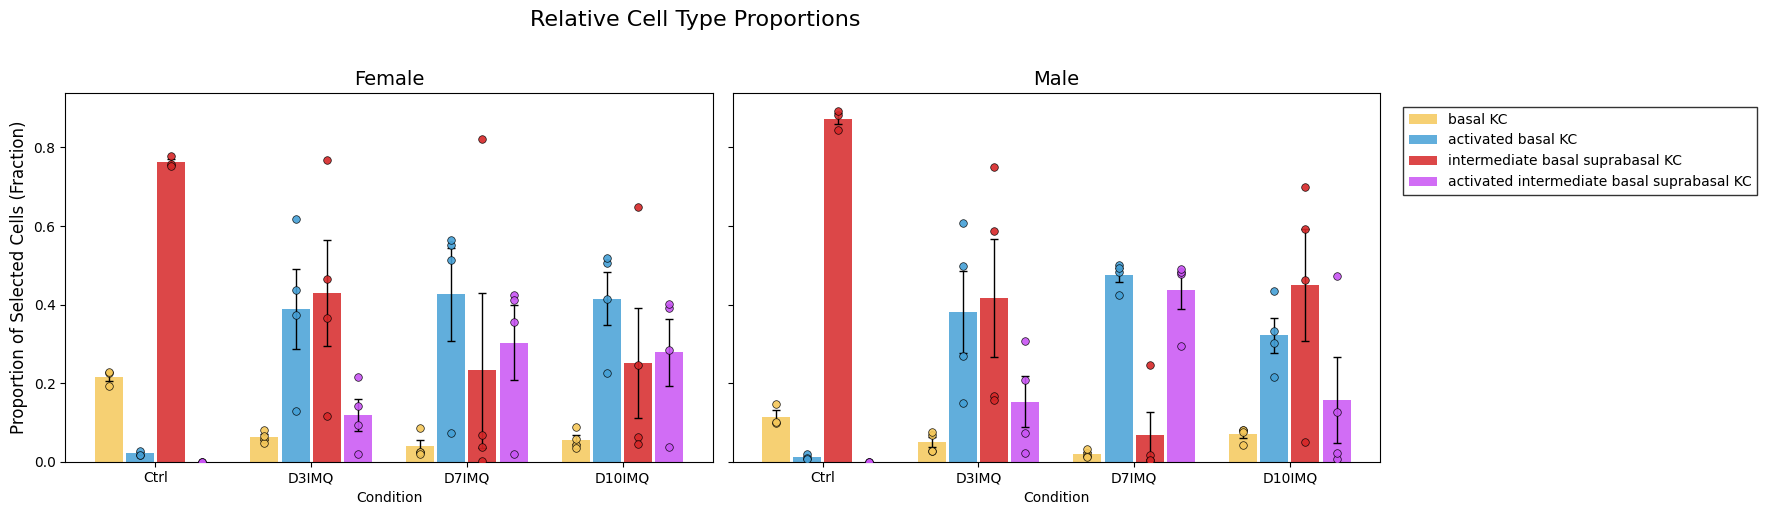

In [70]:
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']
celltypes = ['basal_KC', 'activated_basal_KC', 'intermediate_basal_suprabasal_KC', 'activated_intermediate_basal_suprabasal_KC']

plot_grouped_proportions(adata, celltypes, condition_order=condition_order) #make sure to use adata with ONLY DORSAL SIDE, as this is compartment agnostic

### stacked barplot

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_stacked_proportions(adata, celltypes, condition_order=None):

    # ── Colour mapping - before filtering ────────────────────────────────────
    categories = list(adata.obs['celltype_assignments'].astype('category').cat.categories)
    colors     = adata.uns['celltype_assignments_colors']
    color_map  = dict(zip(categories, colors))

    # Ensure types are string for clean matching/regex extraction
    adata.obs['batch_key'] = adata.obs['batch_key'].astype(str)
    adata.obs['celltype_assignments'] = adata.obs['celltype_assignments'].astype(str)

    # If no order is given, dynamically extract unique base conditions from batch keys
    if condition_order is None:
        extracted_conds = adata.obs['batch_key'].str.extract(r'^(.+)_[FM]\d+$')[0]
        condition_order = sorted(extracted_conds.dropna().unique())

    # ── Build per-replicate data structure ───────────────────────────────────
    all_batches = adata.obs[['batch_key']].drop_duplicates().copy()
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    # 1. Grab raw counts for each targeted cell type per replicate
    for ct in celltypes:
        ct_counts = (
            adata[adata.obs['celltype_assignments'] == ct]
            .obs['batch_key'].value_counts()
        )
        all_batches[ct] = all_batches['batch_key'].map(ct_counts).fillna(0)

    # 2. Calculate the denominator (sum of ONLY the selected cell types)
    all_batches['total_selected_counts'] = all_batches[celltypes].sum(axis=1)

    # 3. Compute relative proportions (fraction between 0 and 1)
    for ct in celltypes:
        all_batches[ct] = (all_batches[ct] / all_batches['total_selected_counts']).fillna(0)

    # ── Plot ──────────────────────────────────────────────────────────────────
    sexes      = ['F', 'M']
    sex_labels = {'F': 'Female', 'M': 'Male'}

    n_conditions = len(condition_order)
    x            = np.arange(n_conditions)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, sex in zip(axes, sexes):
        sex_data = all_batches[all_batches['sex'] == sex]
        
        # Initialize the baseline at 0 for every condition
        bottom = np.zeros(n_conditions)

        # Stack each cell type on top of the previous one
        for ct in celltypes:
            means = []
            for cond in condition_order:
                cond_data = sex_data.loc[sex_data['condition'] == cond, ct]
                # Fallback to 0.0 if a condition completely lacks data for a given sex
                val = cond_data.mean()
                means.append(val if pd.notna(val) else 0.0)
            
            means = np.array(means)

            # Plot the segment of the bar
            ax.bar(
                x, means, bottom=bottom, width=0.6,
                color=color_map[ct], alpha=0.85,
                edgecolor='black', linewidth=0.8
            )

            # Shift the baseline upward for the next celltype layer
            bottom += means

        ax.set_xticks(x)
        ax.set_xticklabels(condition_order)
        ax.set_title(sex_labels[sex], fontsize=14)
        ax.set_xlabel('Condition')
        ax.set_ylim(0, 1.05) # Cap the y-axis cleanly just above 100%

    # Informative Y-axis indicating relative profiling
    axes[0].set_ylabel('Relative Proportion (Fraction)', fontsize=12)

    # Reconstruct the legend context
    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=color_map[ct], alpha=0.85, label=ct.replace('_', ' '))
        for ct in celltypes
    ]
    fig.legend(
        handles=handles,
        loc='upper left',
        bbox_to_anchor=(1.001, 0.84),
        bbox_transform=fig.transFigure,
        frameon=True,
        fancybox=False,
        edgecolor='black',
        fontsize=10,
    )
    fig.suptitle('Stacked Cell Type Proportions', fontsize=16, y=1.02)

    plt.tight_layout()
    plt.show()

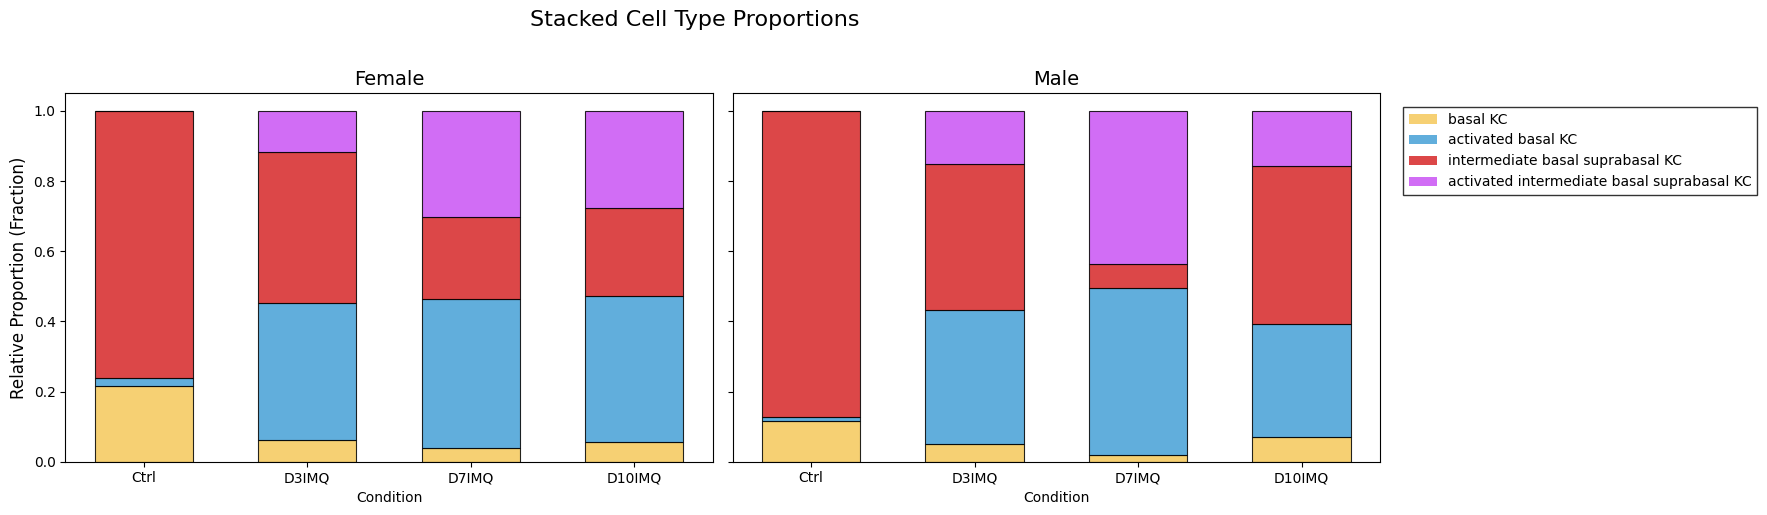

In [72]:
condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']
celltypes = ['basal_KC', 'activated_basal_KC', 'intermediate_basal_suprabasal_KC', 'activated_intermediate_basal_suprabasal_KC']

plot_stacked_proportions(adata, celltypes, condition_order=condition_order)

# DESEQ section

In [1]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import pandas as pd
import numpy as np
import seaborn as sns
import gseapy as gp
from gseapy import gseaplot

In [2]:
import scanpy as sc

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
#only considering dorsal epi/dermis
adata = adata[adata.obs['compartment'].str.contains('orsal')]
adata.obs.compartment.unique()

['dorsal_dermis', 'dorsal_epidermis']
Categories (2, object): ['dorsal_dermis', 'dorsal_epidermis']

In [3]:
import decoupler as dc

#making pseudobulk objects for the epidermis
adata_epi = adata[adata.obs['compartment'].str.contains('_epidermis')].copy()

##Filtering genes not expressed by at least 1% of cells
min_cells = int(0.01 * adata_epi.n_obs)
sc.pp.filter_genes(adata_epi, min_cells=min_cells)


big_bulk_epidermis = dc.pp.pseudobulk(
    adata_epi,
    sample_col = 'batch_key', #defines replicates
    groups_col = None, #ignore if using batch_key, add in if using celltypes
    layer = None,
    mode = 'sum',
    empty = True
)


#making pseudobulk objects for the dermis
adata_derm = adata[adata.obs['compartment'].str.contains('_dermis')].copy()

##Filtering genes not expressed by at least 1% of cells
min_cells = int(0.01 * adata_derm.n_obs)
sc.pp.filter_genes(adata_derm, min_cells=min_cells)

big_bulk_dermis = dc.pp.pseudobulk(
    adata_derm,
    sample_col = 'batch_key', #defines replicates
    groups_col = None, #ignore if using batch_key, add in if using celltypes
    layer = None,
    mode = 'sum',
    empty = True
)

d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
#Creating separate objects for males and females

def isolate_sex(adata, sex_str):
    bdata = adata[adata.obs.replicate.str.contains(sex_str)].copy()
    return bdata

bulk_objects = {'big_bulk_epidermis':big_bulk_epidermis, 'big_bulk_dermis':big_bulk_dermis}

bulk_subtypes = {}
for name, obj in bulk_objects.items():
    #bulk_subtypes[name] = obj #can remove this if you don't care about non-sex differences
    for sex in ['F', 'M']:
        bulk_subtypes[f'{name}_{sex}'] = isolate_sex(obj, sex)

for name, obj in bulk_subtypes.items():
    print(name)
    print(obj)

big_bulk_epidermis_F
AnnData object with n_obs × n_vars = 15 × 2144
    obs: 'batch_key', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'region', 'z_level', 'compartment', 'replicate', 'condition', '_scvi_batch', '_scvi_labels', 'highlight', 'sex', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mean_log1p_expression', 'n_cells'
    layers: 'psbulk_props'
big_bulk_epidermis_M
AnnData object with n_obs × n_vars = 15 × 2144
    obs: 'batch_key', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'region', 'z_level', 'compartment', 'replicate', 'condition', '_scvi_batch', '_scvi_labels', 'highlight', 'sex', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mean_log1p_expression', 'n_cells'
    layers: 'psbulk_props'
big_bulk_dermis_F
AnnData object with n_obs × n_vars = 15 × 937
    obs: 'batch_key', 'control_p

In [5]:
from pathlib import Path
results_path = Path(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\DESEQ_results")

In [6]:
#defining helper function for volcano plotting
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text   # pip install adjustText

def volcano_plot(df, title, save_dir):
    df = df.dropna(subset=['log2FoldChange', 'padj'])
    df['-log10padj'] = -np.log10(df['padj'])

    fc_thresh = 1.0
    padj_thresh = 0.05
    n_labels = 20  # number of top genes to label

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot all points
    colours = np.where(
        (df['padj'] < padj_thresh) & (df['log2FoldChange'] > fc_thresh), 'firebrick',
        np.where(
            (df['padj'] < padj_thresh) & (df['log2FoldChange'] < -fc_thresh), 'steelblue', 'lightgrey'
        )
    )
    ax.scatter(df['log2FoldChange'], df['-log10padj'], c=colours, alpha=0.6, s=15)

    # Label top genes by significance
    top_genes = df.nsmallest(n_labels, 'padj')
    texts = [
        ax.text(row['log2FoldChange'], row['-log10padj'], gene, fontsize=7)
        for gene, row in top_genes.iterrows()
    ]
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

    ax.axhline(-np.log10(padj_thresh), color='black', linestyle='--', linewidth=0.8)
    ax.axvline(fc_thresh, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(-fc_thresh, color='black', linestyle='--', linewidth=0.8)

    ax.set_xlabel('log2 Fold Change')
    ax.set_ylabel('-log10 adjusted p-value')
    ax.set_title(title)
    
    save_path = save_dir / (title)
    plt.savefig(save_path, bbox_inches='tight', dpi = 400)
    plt.close()


In [7]:
#helper function for enrichment map plotting
from gseapy import enrichment_map
import networkx as nx
import textwrap

def enrichment_plot(pre_res, output_path):

    nodes, edges = enrichment_map(pre_res.res2d)
    G = nx.from_pandas_edgelist(edges,
                            source='src_idx',
                            target='targ_idx',
                            edge_attr=['jaccard_coef', 'overlap_coef', 'overlap_genes'])
    
    fig, ax = plt.subplots(figsize=(8, 8))
    pos = nx.layout.spiral_layout(G)

    nodelist = list(G.nodes())
    nodes_aligned = nodes.loc[nodelist]

    nx.draw_networkx_nodes(G,
                        pos=pos,
                        nodelist=nodelist,
                        cmap=plt.cm.RdYlBu,
                        node_color=list(nodes_aligned.NES),
                        node_size=list(nodes_aligned.Hits_ratio * 1000))

    # wrap labels and draw with clip_on=False
    wrapped_labels = {
        node: '\n'.join(textwrap.wrap(term, width=20))
        for node, term in nodes_aligned.Term.to_dict().items()
    }
    label_objs = nx.draw_networkx_labels(G, pos=pos, labels=wrapped_labels, font_size=7)
    for _, text in label_objs.items():
        text.set_clip_on(False)

    edge_weight = nx.get_edge_attributes(G, 'jaccard_coef').values()
    nx.draw_networkx_edges(G,
                        pos=pos,
                        width=list(map(lambda x: x*10, edge_weight)),
                        edge_color='#CDDBD4')
    
    x_values = [pos[n][0] for n in G.nodes()]
    y_values = [pos[n][1] for n in G.nodes()]

    max_label_len = max(len(t) for t in nodes_aligned.Term)
    pad = 0.3 + (max_label_len * 0.01)

    ax.set_xlim(min(x_values) - pad, max(x_values) + pad)
    ax.set_ylim(min(y_values) - pad, max(y_values) + pad)

    plt.tight_layout()
    plt.savefig(output_path, dpi=400, bbox_inches='tight')
    plt.close()

In [8]:
'big_bulk_dermis_F'.split("_")[3] == 'F'

True

In [9]:
#run on a whole dictionary - single object workflow in following cells
failed_deseq2 = []
low_DEs = []
small_GSEAs = []
failed_enrichments = []

for name, bulk in bulk_subtypes.items():
    #make a deseq data set from your anndata
    
    ###avoid recalculating if already done###
    # if Path(results_path/ f'{name}_Ctrl_D3IMQ_DEgenes.csv').exists(): #bit jammy, but if D3 is calced, then so are D7/D10
    #     continue

    dds = DeseqDataSet(counts = bulk.X,
                   metadata = bulk.obs,
                   design_factors = 'condition')
    dds.var = bulk.var


    #run deseq2 on it
    try:
        dds.deseq2()
    except:
        failed_deseq2.append(f'{name}')
        continue

    #get the stats
    for day in ['D7IMQ', 'D10IMQ']:
        print(name.split("_")[3])
        print("="*80)


        stat_res = DeseqStats(dds, contrast = ['condition', day, 'Ctrl']) #pairwise comparison of days with each condition
        stat_res.summary()
        #get diffexp dataframe
        res = stat_res.results_df
        # res_file = f'{name}_Ctrl_{day}_DEgenes.csv'
        # res.to_csv(results_path / res_file) #save table with stats of DE genes
        
        #filtering any genes with baseMean <10, choice is somewhat arbitrary
        res = res[res.baseMean >10]
        #then filter all those that are not significant or large enough
        sigs = res[(abs(res.log2FoldChange) > 1)&(res.padj <0.05)] #again, log2fc threshold is bit arbitrary,being stringent so using 1.
        #check if yap1 is in the list of significantly expressed genes
        if 'Yap1' in sigs.index.to_list():
            print(f'{name}_Ctrl_{day} has a significant change in YAP1')
        
        # #plot VOLCANO PLOT and save
        # volcano_plot_name = f'{name}_Ctrl_{day}_volcano.png'

        # save_dir = results_path / 'Volcano_plots'
        # volcano_plot(res, volcano_plot_name, save_dir)
        
        # #plot CLUSTERMAP for significant genes
        # cluster_map_name = f'{name}_Ctrl_{day}_cluster.png'
        # cluster_map_path = results_path / 'clustermaps' / cluster_map_name
        # if len(sigs) >2:
        #     dds.layers['log1p'] = np.log1p(dds.layers['normed_counts'])
        #     dds_sigs = dds[:, sigs.index].copy()

        #     grapher = pd.DataFrame(dds_sigs.layers['log1p'].T,
        #                 index = dds_sigs.var_names, columns = dds_sigs.obs_names)
            
        #     clustermap = sns.clustermap(grapher, z_score = 0, cmap = 'RdYlBu_r')
        #     clustermap.savefig(cluster_map_path, bbox_inches = 'tight', dpi = 400)
        #     plt.close(clustermap.fig)
        # else:
        #     low_DEs.append(f'{name}_Ctrl_{day}')

        #do GSEA on your diffexped genes
        ranking = res['stat'].dropna().sort_values(ascending = False)

        for gene_set in ['GO_Biological_Process_2026', 'KEGG_2026']:
            if gene_set == 'GO_Biological_Process_2026':
                database = 'GO'
            else:
                database = 'KEGG' 
            
            try:
                pre_res = gp.prerank(rnk = ranking,
                        gene_sets = gene_set, #this can be a list, e.g. if you wanted to look at molecular function, or KEGG
                        organism = 'mouse',
                        seed = 6, permutation_num=100)
                
                print(name.split("_")[3])
                if name.split("_")[3] == 'F':
                    sex = 'female'
                else:
                    sex = 'male'
                
                dot_title = f'{name.split("_")[2]} {sex} Ctrl {day} {database}'
                ax = gp.dotplot(pre_res.res2d,
                            column="FDR q-val",
                            title=dot_title,
                            cmap=plt.cm.RdBu_r,
                            size=4, # adjust dot size
                            figsize=(4,5), 
                            cutoff=0.25, 
                            show_ring=False,
                            ofname=str(results_path / 'GSEA_plots' / f'{name.split("_")[2]} {sex} Ctrl {day} {database}_dotplot.png'))

                out = []
            #     for term in list(pre_res.results):
            #         out.append([term,
            #                     pre_res.results[term]['fdr'],
            #                     pre_res.results[term]['es'],
            #                     pre_res.results[term]['nes']])
            #     print("succeeded 2")
                    
            #     out_df = pd.DataFrame(out, columns = ['Term', 'fdr', 'es', 'nes']).sort_values('fdr').reset_index(drop = True)
            #     out_df.sort_values('nes', ascending = False)
            #     print("succeeded 3")



            #     out_df.to_csv(results_path / 'GSEA_csvs' / f'{name}_Ctrl_{day}_{database}.csv')

            #     #plotting the ENRICHMENT MAP
            #     output_path = results_path / 'GSEA_plots'/ f'{name}_Ctrl_{day}_{database}.png'
            #     try:
            #         enrichment_plot(pre_res, output_path)
            #     except:
            #         print(f'no signficant {database} terms for {name}_D3IMQ{day}')
            #         failed_enrichments.append(f'{name}_Ctrl_{day}_{database}')
            except:
                small_GSEAs.append(f'{name}_Ctrl_{day}_{database}')


print(failed_deseq2) 
print(low_DEs) 
print(small_GSEAs) 
print(failed_enrichments)

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_23300\2778982662.py:14: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts = bulk.X,
Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.34 seconds.

Fitting dispersion trend curve...
d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\pydeseq2\dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.32 seconds.

Fitting LFCs...
... done in 0.28 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


F


... done in 0.25 seconds.



...

Using None as control genes, passed at DeseqDataSet initialization


... done in 0.20 seconds.

Fitting dispersion trend curve...
d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\pydeseq2\dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...
... done in 0.21 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.17 seconds.



M
Log2 fold change & Wald test p-value: condition D7IMQ vs Ctrl
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Aatf     23.440309       -0.567454  0.358563 -1.582579  0.113518  0.309113
Abca1    76.806300        0.100404  0.265141  0.378684  0.704923  0.838214
Abca7    36.265019        0.017276  0.286989  0.060196  0.952000  0.980246
Abcc1    15.211495       -0.189371  0.421571 -0.449204  0.653285  0.815247
Abcf1    17.595919       -0.301472  0.367822 -0.819613  0.412437  0.634570
...            ...             ...       ...       ...       ...       ...
Zc3h11a  23.010033        0.249700  0.365124  0.683878  0.494052  0.692641
Zdhhc8   19.118576       -0.898741  0.361772 -2.484273  0.012982  0.072306
Zeb2     33.662585       -0.103053  0.326897 -0.315246  0.752575  0.863563
Zfp106   30.506359       -0.038728  0.343502 -0.112743  0.910234  0.968037
Zzef1    17.285826        0.770799  0.446733  1.725412  0.084453  0.262029

[937 rows x 6 columns]
M
M
M


Running Wald tests...
... done in 0.19 seconds.



Log2 fold change & Wald test p-value: condition D10IMQ vs Ctrl
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Aatf     23.440309       -0.247036  0.374541 -0.659568  0.509531  0.756618
Abca1    76.806300        0.693485  0.268884  2.579120  0.009905  0.085680
Abca7    36.265019       -0.188646  0.307334 -0.613812  0.539339  0.773252
Abcc1    15.211495       -0.088081  0.449410 -0.195992  0.844617       NaN
Abcf1    17.595919       -0.440271  0.399250 -1.102746  0.270138       NaN
...            ...             ...       ...       ...       ...       ...
Zc3h11a  23.010033        0.290872  0.383477  0.758513  0.448144  0.720438
Zdhhc8   19.118576       -0.464650  0.381613 -1.217594  0.223378       NaN
Zeb2     33.662585        0.386013  0.336073  1.148599  0.250721  0.535491
Zfp106   30.506359       -0.497634  0.367821 -1.352922  0.176081  0.464297
Zzef1    17.285826        0.612110  0.471182  1.299095  0.193911       NaN

[937 rows x 6 columns]
M
M
[]
[]
[]


In [ ]:
from gseapy import dotplot
# to save your figure, make sure that ``ofname`` is not None
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='KEGG_2016',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,5), cutoff=0.25, show_ring=False)

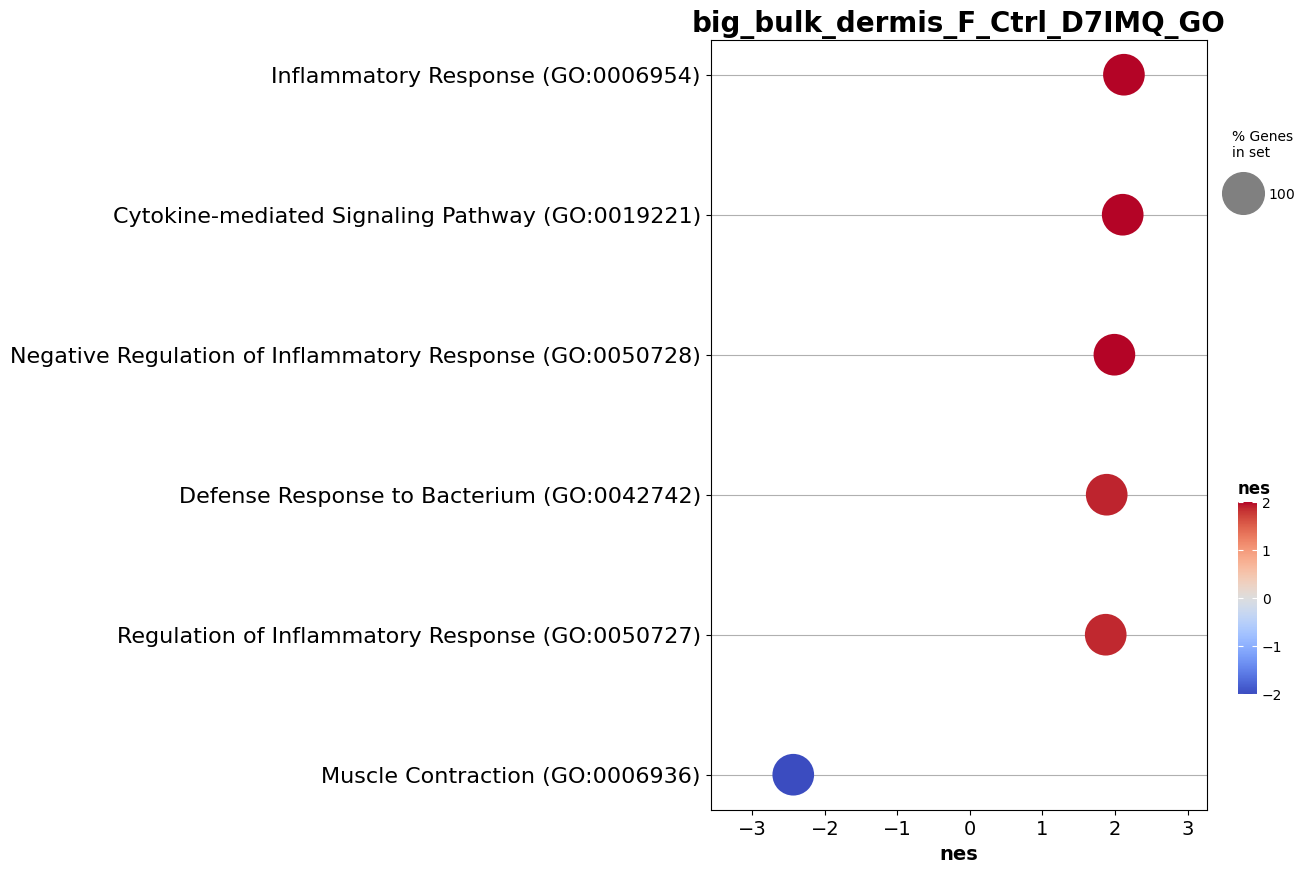

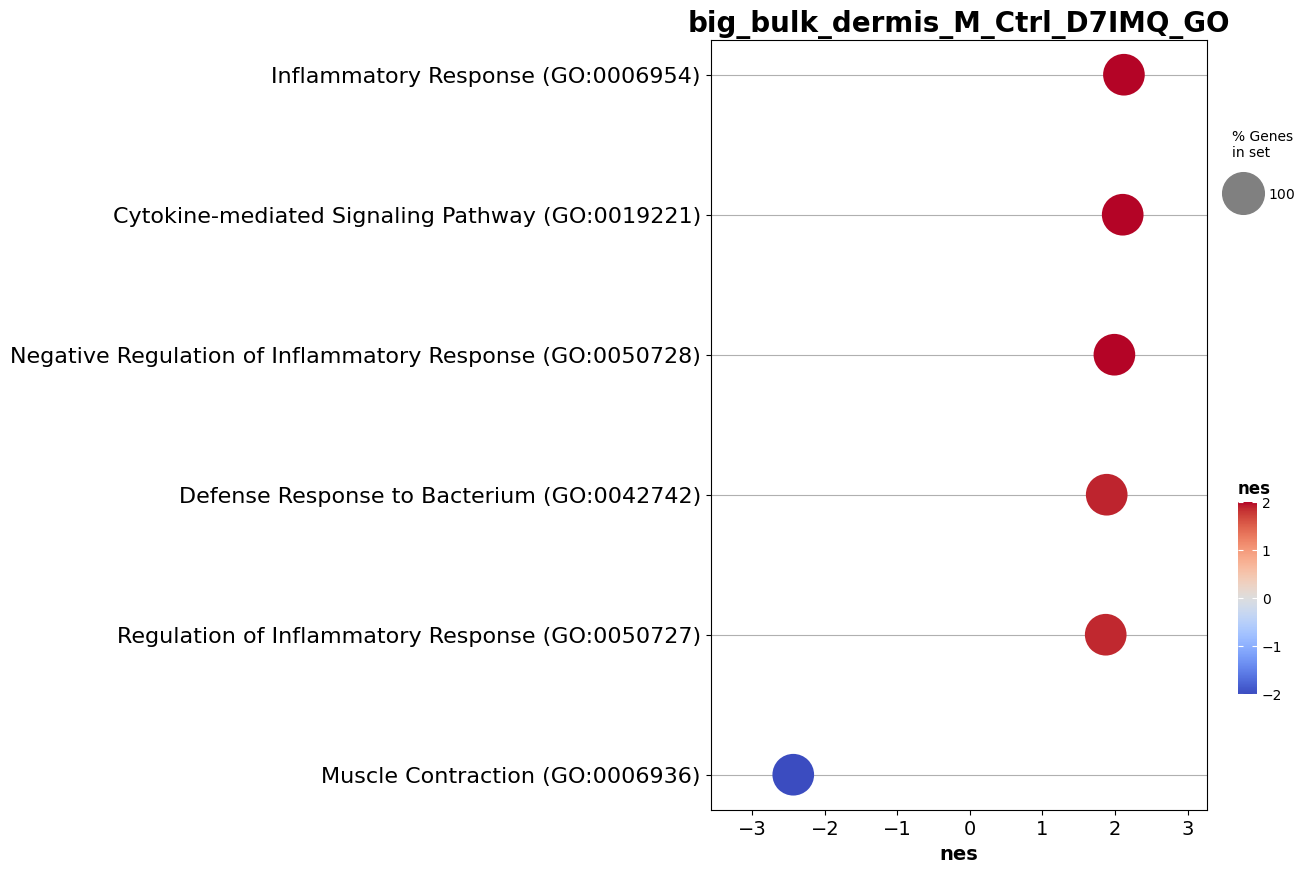

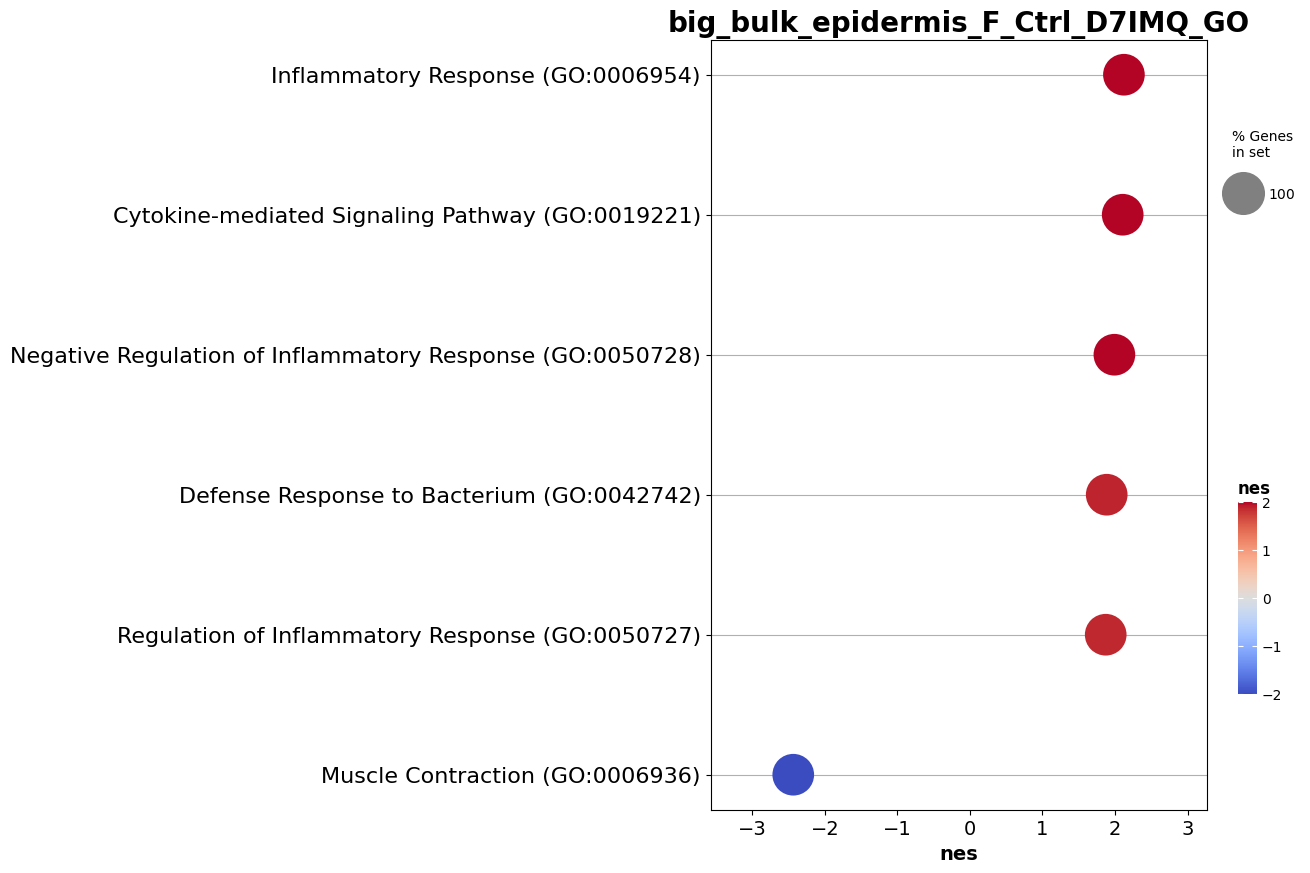

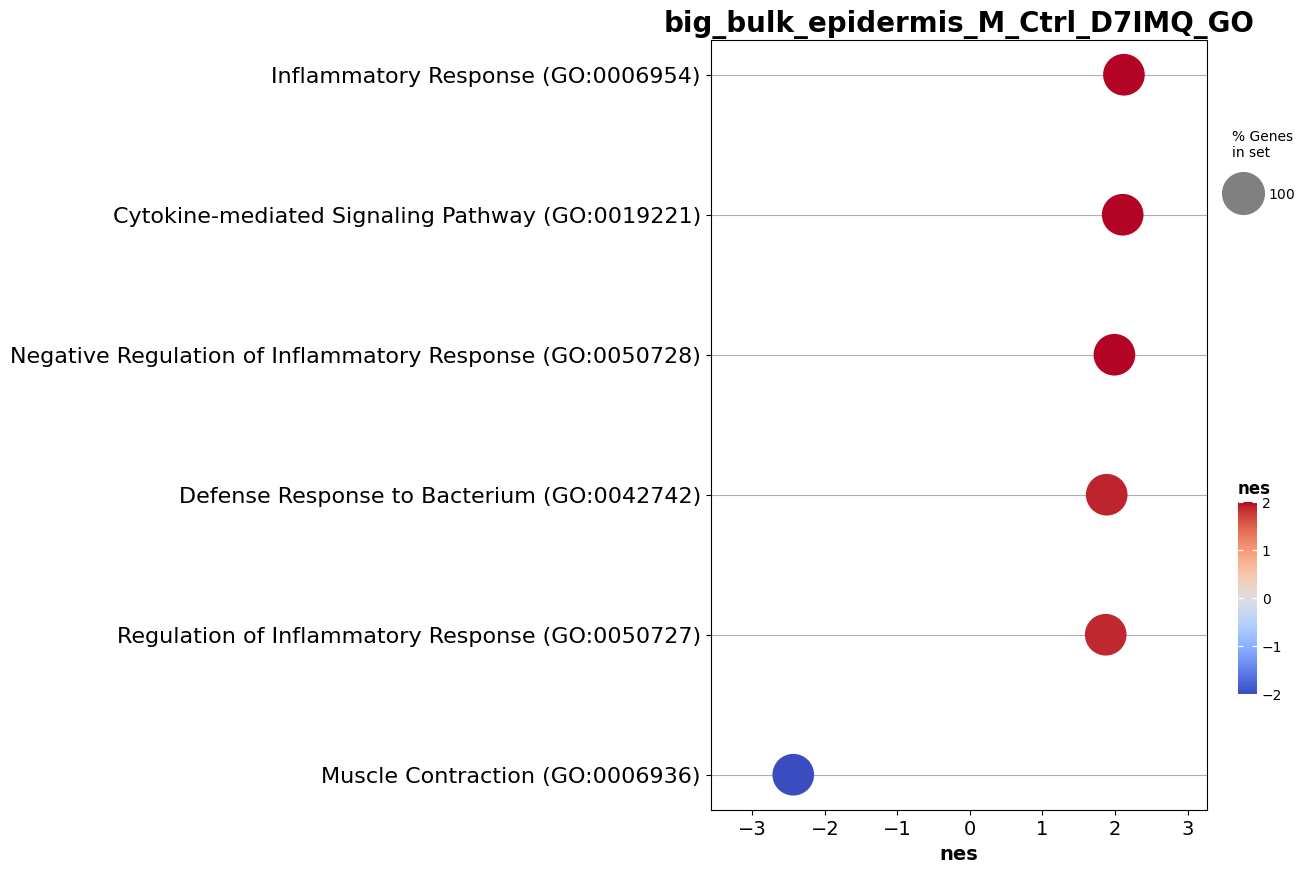

In [27]:
for name, df in out_dfs.items():
    filtered = out_df[0][out_df[0]['fdr'] < 0.05]
    gp.dotplot(
        filtered,
        column="nes",       # dot size and x-axis
        title=name,
        cmap="coolwarm",
        size=5,
        figsize=(8, 10),
        cutoff=999,
        show_ring=False
    )